In [1]:
# from data_synthesizer.util import  plot_training_loss, ModelType
import pickle

from data_loader import DataLoader

from data_synthesizer.pipeline import  load_all_results
from data_synthesizer.privacy_sampling import get_epsilon


In [2]:
import sys
from pathlib import Path

# Add repo root so `import experiments` works in notebooks.
sys.path.append(str(Path.cwd().parent.parent))

from experiments.paths import RESULTS_DIR, DATA_DIR, BASELINE_DIR


## Loading Data

In [11]:
!git -C ../../pipeline_tabular_data_results lfs pull --include "data/**"
!git -C ../../pipeline_tabular_data_results lfs pull --include "baseline/**"
!git -C ../../pipeline_tabular_data_results lfs pull --include "epsilon_comparison_heom_any/**"
!git -C ../../pipeline_tabular_data_results lfs pull --include "epsilon_disclosure_protection_comparison_heom_any/**"

### Real Data

In [3]:
cat_list_credit_card = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6', 'default.payment.next.month']
num_list_credit_card = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4','BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3','PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
credit_qai_columns = ['LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE']
credit_risk_column = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

df_real_credit_card_train = DataLoader(f'{DATA_DIR}/credit_card_Train.csv').get_dataframe(cat_list_credit_card,  drop_identation=True)
df_real_credit_card_test = DataLoader(f'{DATA_DIR}/credit_card_Test.csv').get_dataframe(cat_list_credit_card,  drop_identation=True)
credit_real_dict ={'data' : df_real_credit_card_train, 'cat_list' : cat_list_credit_card, 'num_list' : num_list_credit_card}

In [4]:
cat_list_adult = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country','income']
num_list_adult = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
adult_qai_columns = ['education','education-num','marital-status','occupation','relationship','sex', 'native-country']
adult_risk_column = ['capital-gain','capital-loss','hours-per-week','income', 'race']
df_real_adult_train = DataLoader(f'{DATA_DIR}/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader(f'{DATA_DIR}/adult_test.csv').get_dataframe(cat_list_adult)

In [5]:
num_list_cardio = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
cat_list_cardio = ['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

cardio_qai_columns = ['age','gender','height','weight']
cardio_risk_column = ['ap_lo','ap_hi','cholesterol','gluc','smoke','alco','active']


df_real_cardio_train = DataLoader(f'{DATA_DIR}/cardio_train.csv').get_dataframe(cat_list_cardio)
df_real_cardio_test = DataLoader(f'{DATA_DIR}/cardio_test.csv').get_dataframe(cat_list_cardio)

In [6]:
import os
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

def export_optuna_study_to_json_dict(study):
    def dt_iso(x):
        return x.isoformat() if x is not None else None

    directions = (
        [str(d) for d in study.directions]
        if hasattr(study, "directions")
        else [str(study.direction)]
    )

    def trial_to_dict(t):
        return {
            "number": t.number,
            "state": str(t.state),
            "value": t.value,
            "values": t.values,
            "params": dict(t.params),
            "distributions": {k: str(v) for k, v in t.distributions.items()},
            "user_attrs": dict(t.user_attrs),
            "system_attrs": dict(t.system_attrs),
            "datetime_start": dt_iso(t.datetime_start),
            "datetime_complete": dt_iso(t.datetime_complete),
            "duration_seconds": (
                (t.datetime_complete - t.datetime_start).total_seconds()
                if t.datetime_start and t.datetime_complete
                else None
            ),
        }

    payload = {
        "study_name": study.study_name,
        "directions": directions,
        "n_trials": len(study.trials),
        "best_trial": trial_to_dict(study.best_trial)
        if study.trials
        else None,
        "trials": [trial_to_dict(t) for t in study.trials],
    }
    return payload


def to_json_safe(obj):
    """
    Convert common scientific Python objects to JSON-serializable structures.
    Extend this if needed.
    """
    if isinstance(obj, dict):
        return {str(k): to_json_safe(v) for k, v in obj.items()}

    if isinstance(obj, (list, tuple, set)):
        return [to_json_safe(v) for v in obj]

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()

    if isinstance(obj, pd.DataFrame):
        return {
            "__type__": "DataFrame",
            "data": obj.to_dict(orient="records"),
            "columns": list(obj.columns),
        }

    if isinstance(obj, pd.Series):
        return {
            "__type__": "Series",
            "data": obj.to_dict(),
            "name": obj.name,
        }

    # Fallback: try direct JSON serialization
    try:
        json.dumps(obj)
        return obj
    except TypeError:
        return {
            "__type__": "unserializable",
            "repr": repr(obj),
        }


def convert_all_pkl_to_json(root_dir, isOptuna=False):
    root_dir = Path(root_dir)

    for pkl_path in root_dir.rglob("*.pkl"):
        json_path = pkl_path.with_suffix(".json")

        print(f"Converting: {pkl_path}")

        try:
            with open(pkl_path, "rb") as f:
                obj = pickle.load(f)
            if (isOptuna) :
                json_obj = export_optuna_study_to_json_dict(obj)
            else :
                json_obj = to_json_safe(obj)

            with open(json_path, "w", encoding="utf-8") as f:
                json.dump(json_obj, f, indent=2, ensure_ascii=False)

        except Exception as e:
            print(f"❌ Failed on {pkl_path}: {e}")


convert_all_pkl_to_json(
        f"{RESULTS_DIR}/optuna", True
    )


Converting: /home/dayav/projects/temp/pipeline_synthetic_tabular_data/pipeline_tabular_data_results/optuna/study_ctgan_cardio.pkl
❌ Failed on /home/dayav/projects/temp/pipeline_synthetic_tabular_data/pipeline_tabular_data_results/optuna/study_ctgan_cardio.pkl: invalid load key, 'v'.
Converting: /home/dayav/projects/temp/pipeline_synthetic_tabular_data/pipeline_tabular_data_results/optuna/study_tvae_cardio.pkl
❌ Failed on /home/dayav/projects/temp/pipeline_synthetic_tabular_data/pipeline_tabular_data_results/optuna/study_tvae_cardio.pkl: invalid load key, 'v'.
Converting: /home/dayav/projects/temp/pipeline_synthetic_tabular_data/pipeline_tabular_data_results/optuna/study_ctgan_adult.pkl
❌ Failed on /home/dayav/projects/temp/pipeline_synthetic_tabular_data/pipeline_tabular_data_results/optuna/study_ctgan_adult.pkl: invalid load key, 'v'.
Converting: /home/dayav/projects/temp/pipeline_synthetic_tabular_data/pipeline_tabular_data_results/optuna/study_tvae_credit.pkl
❌ Failed on /home/dayav

In [3]:
with open(f"{RESULTS_DIR}/optuna/study_ctgan_adult.pkl", "rb") as f:
    obj = pickle.load(f)

In [8]:
obj

In [16]:
import sys, pickle
import optuna

print("python:", sys.version)
print("exe:", sys.executable)
print("optuna:", optuna.__version__)
print("optuna file:", optuna.__file__)

import numpy as np
print("numpy:", np.__version__)
try:
    import scipy
    print("scipy:", scipy.__version__)
except Exception as e:
    print("scipy: not installed / error:", e)

p = f"{RESULTS_DIR}/optuna/study_ctgan_cardio.pkl"
with open(p, "rb") as f:
    obj = pickle.load(f)

print("Loaded OK:", type(obj))


python: 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:23) [GCC 13.3.0]
exe: /home/dayav/miniconda3/envs/tabpfn_env/bin/python
optuna: 4.5.0
optuna file: /home/dayav/miniconda3/envs/tabpfn_env/lib/python3.11/site-packages/optuna/__init__.py
numpy: 1.26.4
scipy: 1.13.1


TypeError: _ParzenEstimatorParameters.__new__() takes 7 positional arguments but 8 were given

### Synthetic Data

In [6]:
credit_ctgan  = load_all_results(f'{BASELINE_DIR}/credit_ctgan_baseline')
credit_tvae  = load_all_results(f'{BASELINE_DIR}/credit_tvae_baseline')


credit_ctgan  = load_all_results(f'{BASELINE_DIR}/credit_ctgan_baseline')
credit_tvae  = load_all_results(f'{BASELINE_DIR}/credit_tvae_baseline')
credit_ctgan_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.005')
credit_ctgan_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.01')
credit_ctgan_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.05')
credit_ctgan_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.1')
credit_ctgan_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.15')
credit_ctgan_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.2')
credit_ctgan_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.25')
credit_ctgan_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.3')
credit_ctgan_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.35')
credit_ctgan_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.4')

credit_tvae_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.005')
credit_tvae_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.01')
credit_tvae_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.05')
credit_tvae_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.1')
credit_tvae_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.15')
credit_tvae_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.2')
credit_tvae_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.25')
credit_tvae_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.3')
credit_tvae_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.35')
credit_tvae_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.4')

dict_results_credit_ctgan_heom_any  = {
    'credit CTGAN' : credit_ctgan,
    'credit CTGAN 0.4' : credit_ctgan_heom_any_eps_04,
    'credit CTGAN 0.35' : credit_ctgan_heom_any_eps_035,
    'credit CTGAN 0.3' : credit_ctgan_heom_any_eps_03,
    'credit CTGAN 0.25' : credit_ctgan_heom_any_eps_025,
    'credit CTGAN 0.2' : credit_ctgan_heom_any_eps_02,
    'credit CTGAN 0.15' : credit_ctgan_heom_any_eps_015,
    'credit CTGAN 0.1' : credit_ctgan_heom_any_eps_01,
    'credit CTGAN 0.05' : credit_ctgan_heom_any_eps_005,
    'credit CTGAN 0.01' : credit_ctgan_heom_any_eps_001,
    'credit CTGAN 0.005' : credit_ctgan_heom_any_eps_0005,    
}
dict_results_credit_tvae_heom_any  = {
    'credit TVAE' : credit_tvae,
    'credit TVAE 0.4' : credit_tvae_heom_any_eps_04,
    'credit TVAE 0.35' : credit_tvae_heom_any_eps_035,
    'credit TVAE 0.3' :credit_tvae_heom_any_eps_03,
    'credit TVAE 0.25' :credit_tvae_heom_any_eps_025,
    'credit TVAE 0.2' :credit_tvae_heom_any_eps_02,
    'credit TVAE 0.15' :credit_tvae_heom_any_eps_015,
    'credit TVAE 0.1' :credit_tvae_heom_any_eps_01,
    'credit TVAE 0.05' :credit_tvae_heom_any_eps_005,
    'credit TVAE 0.01' :credit_tvae_heom_any_eps_001,
    'credit TVAE 0.005' :credit_tvae_heom_any_eps_0005
}

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py

In [7]:
adult_ctgan  = load_all_results(f'{BASELINE_DIR}/adult_ctgan_baseline')
adult_tvae  = load_all_results(f'{BASELINE_DIR}/adult_tvae_baseline')

adult_ctgan_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.005')
adult_ctgan_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.01')
adult_ctgan_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.05')
adult_ctgan_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.1')
adult_ctgan_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.15')
adult_ctgan_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.2')
adult_ctgan_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.25')
adult_ctgan_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.3')
adult_ctgan_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.35')
adult_ctgan_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.4')

adult_tvae_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.005')
adult_tvae_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.01')
adult_tvae_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.05')
adult_tvae_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.1')
adult_tvae_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.15')
adult_tvae_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.2')
adult_tvae_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.25')
adult_tvae_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.3')
adult_tvae_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.35')
adult_tvae_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.4')

dict_results_adult_ctgan_heom_any  = {
    'adult CTGAN' : adult_ctgan,
    'adult CTGAN 0.4' : adult_ctgan_heom_any_eps_04,
    'adult CTGAN 0.35' : adult_ctgan_heom_any_eps_035,
    'adult CTGAN 0.3' : adult_ctgan_heom_any_eps_03,
    'adult CTGAN 0.25' : adult_ctgan_heom_any_eps_025,
    'adult CTGAN 0.2' : adult_ctgan_heom_any_eps_02,
    'adult CTGAN 0.15' : adult_ctgan_heom_any_eps_015,
    'adult CTGAN 0.1' : adult_ctgan_heom_any_eps_01,
    'adult CTGAN 0.05' : adult_ctgan_heom_any_eps_005,
    'adult CTGAN 0.01' : adult_ctgan_heom_any_eps_001,
    'adult CTGAN 0.005' : adult_ctgan_heom_any_eps_0005,    
}
dict_results_adult_tvae_heom_any  = {
    'adult TVAE' : adult_tvae,
    'adult TVAE 0.4' : adult_tvae_heom_any_eps_04,
    'adult TVAE 0.35' : adult_tvae_heom_any_eps_035,
    'adult TVAE 0.3' :adult_tvae_heom_any_eps_03,
    'adult TVAE 0.25' :adult_tvae_heom_any_eps_025,
    'adult TVAE 0.2' :adult_tvae_heom_any_eps_02,
    'adult TVAE 0.15' :adult_tvae_heom_any_eps_015,
    'adult TVAE 0.1' :adult_tvae_heom_any_eps_01,
    'adult TVAE 0.05' :adult_tvae_heom_any_eps_005,
    'adult TVAE 0.01' :adult_tvae_heom_any_eps_001,
    'adult TVAE 0.005' :adult_tvae_heom_any_eps_0005
}

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py

In [8]:

cardio_ctgan  = load_all_results(f'{BASELINE_DIR}/cardio_ctgan_baseline')
cardio_tvae  = load_all_results(f'{BASELINE_DIR}/cardio_tvae_baseline')
cardio_ctgan_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.005')
cardio_ctgan_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.01')
cardio_ctgan_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.05')
cardio_ctgan_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.1')
cardio_ctgan_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.15')
cardio_ctgan_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.2')
cardio_ctgan_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.25')
cardio_ctgan_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.3')
cardio_ctgan_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.35')
cardio_ctgan_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.4')

cardio_tvae_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.005')
cardio_tvae_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.01')
cardio_tvae_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.05')
cardio_tvae_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.1')
cardio_tvae_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.15')
cardio_tvae_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.2')
cardio_tvae_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.25')
cardio_tvae_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.3')
cardio_tvae_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.35')
cardio_tvae_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.4')

dict_results_cardio_ctgan_heom_any  = {
    'cardio CTGAN' : cardio_ctgan,
    'cardio CTGAN 0.4' : cardio_ctgan_heom_any_eps_04,
    'cardio CTGAN 0.35' : cardio_ctgan_heom_any_eps_035,
    'cardio CTGAN 0.3' : cardio_ctgan_heom_any_eps_03,
    'cardio CTGAN 0.25' : cardio_ctgan_heom_any_eps_025,
    'cardio CTGAN 0.2' : cardio_ctgan_heom_any_eps_02,
    'cardio CTGAN 0.15' : cardio_ctgan_heom_any_eps_015,
    'cardio CTGAN 0.1' : cardio_ctgan_heom_any_eps_01,
    'cardio CTGAN 0.05' : cardio_ctgan_heom_any_eps_005,
    'cardio CTGAN 0.01' : cardio_ctgan_heom_any_eps_001,
    'cardio CTGAN 0.005' : cardio_ctgan_heom_any_eps_0005,    
}
dict_results_cardio_tvae_heom_any  = {
    'cardio TVAE' : cardio_tvae,
    'cardio TVAE 0.4' : cardio_tvae_heom_any_eps_04,
    'cardio TVAE 0.35' : cardio_tvae_heom_any_eps_035,
    'cardio TVAE 0.3' :cardio_tvae_heom_any_eps_03,
    'cardio TVAE 0.25' :cardio_tvae_heom_any_eps_025,
    'cardio TVAE 0.2' :cardio_tvae_heom_any_eps_02,
    'cardio TVAE 0.15' :cardio_tvae_heom_any_eps_015,
    'cardio TVAE 0.1' :cardio_tvae_heom_any_eps_01,
    'cardio TVAE 0.05' :cardio_tvae_heom_any_eps_005,
    'cardio TVAE 0.01' :cardio_tvae_heom_any_eps_001,
    'cardio TVAE 0.005' :cardio_tvae_heom_any_eps_0005
}

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations



/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py

## Privacy Evaluation

### DCR

In [12]:
import json
dcr_protection= {}

with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_dcr_protection.json', 'rb') as file:
    # Deserialize the object from the file
    dcr_protection['credit ctgan'] = json.load(file)

with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_dcr_protection.json', 'rb') as file:
    # Deserialize the object from the file
    dcr_protection['credit tvae'] = json.load(file)

with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_ctgan_dcr_protection.json', 'rb') as file:
    # Deserialize the object from the file
    dcr_protection['adult ctgan'] = json.load(file)

with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_tvae_dcr_protection.json', 'rb') as file:
    # Deserialize the object from the file
    dcr_protection['adult tvae'] = json.load(file)

with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_ctgan_dcr_protection.json', 'rb') as file:
    # Deserialize the object from the file
    dcr_protection['cardio ctgan'] = json.load(file)

with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_tvae_dcr_protection.json', 'rb') as file:
    # Deserialize the object from the file
    dcr_protection['cardio tvae'] = json.load(file)


### SynthEval

#### SynthEval Util

In [13]:
def encode_frame(df):
    out = df.copy()
    for col in out:
        if out[col].dtype == "object" or str(out[col].dtype).startswith("category"):
            out[col] = out[col].astype("category").cat.codes   # -1 = NaN
    return out.astype("float32")            # keeps RAM low

In [9]:
from synthcity.plugins.core.dataloader import GenericDataLoader

def get_data_loader(train , test , synth, cat_list, qai_columns, risk_column) :

    synth_data = DataLoader(dataset=synth).get_dataframe(cat_list)
    train_data = DataLoader(dataset=train).get_dataframe(cat_list)
    val_data = DataLoader(dataset=test).get_dataframe(cat_list)

    synth_data = DataLoader.align_categoricals(synth_data, train_data, cat_list)

    real_enc   = encode_frame(train_data)
    val_enc = encode_frame(val_data)
    synth_enc  = encode_frame(synth_data)

    ldr_real_val = GenericDataLoader(val_enc,
                                    sensitive_features= risk_column,
                                    important_features = qai_columns,)
    ldr_real   = GenericDataLoader(real_enc,
                                sensitive_features= risk_column,
                                    important_features = qai_columns,)
    ldr_synth  = GenericDataLoader(synth_enc,
                                    sensitive_features= risk_column,
                                        important_features = qai_columns,)
    
    return ldr_real, ldr_real_val, ldr_synth

ModuleNotFoundError: No module named 'synthcity'

In [8]:
from synthcity.metrics.eval_privacy import IdentifiabilityScore   # or LIRAMIA, DeltaPresence, …



def ComputeIdentifiabilityScore(train , test , dict_results, cat_list, qai_columns, risk_column) :

    scores = {}

    for key, value in dict_results.items() :

        ldr_real, ldr_real_val, ldr_synth = get_data_loader(train , test , value['generation_results']['synthetic_data'], cat_list, qai_columns, risk_column)

        idScore = IdentifiabilityScore(use_cache= False)

        results_idScore = idScore.evaluate(X_gt=ldr_real, X_syn=ldr_synth)

        print(f"{key} IdentifiabilityScore : {results_idScore}")

        scores[key] = results_idScore

    return  scores


In [9]:
from synthcity.metrics.eval_privacy import kAnonymization   # or LIRAMIA, DeltaPresence, …



def ComputeKAnonymScore(train , test , dict_results, cat_list, qai_columns, risk_column) :

    scores = {}

    for key, value in dict_results.items() :

        ldr_real, ldr_real_val, ldr_synth = get_data_loader(train , test , value['generation_results']['synthetic_data'], cat_list, qai_columns, risk_column)

        k_anonym_score = kAnonymization(use_cache= False)

        results_k_anonym_score = k_anonym_score.evaluate(X_gt=ldr_real, X_syn=ldr_synth)

        print(f"{key} kAnonymization : {results_k_anonym_score}")

        scores[key] = results_k_anonym_score

    return  scores

In [10]:
from synthcity.metrics.eval_privacy import lDiversityDistinct   # or LIRAMIA, DeltaPresence, …


def ComputeLDiversityDistinct(train , test , dict_results, cat_list, qai_columns, risk_column) :

    scores = {}

    for key, value in dict_results.items() :

        ldr_real, ldr_real_val, ldr_synth = get_data_loader(train , test , value['generation_results']['synthetic_data'], cat_list, qai_columns, risk_column)

        lDiversity = lDiversityDistinct(use_cache= False)

        results_lDiversity = lDiversity.evaluate(X_gt=ldr_real, X_syn=ldr_synth)

        print(f"{key} lDiversityDistinct : {results_lDiversity}")

        scores[key] = results_lDiversity

    return  scores

In [11]:
from synthcity.metrics.eval_privacy import DomiasMIAKDE   # or LIRAMIA, DeltaPresence, …


def ComputeDomiasMIAKDE(train , test , dict_results, cat_list, qai_columns, risk_column) :

    scores = {}

    for key, value in dict_results.items() :

        ldr_real, ldr_real_val, ldr_synth = get_data_loader(train , test , value['generation_results']['synthetic_data'], cat_list, qai_columns, risk_column)

        mkdScore = DomiasMIAKDE(use_cache= False)

        results_mkdScore = mkdScore.evaluate(X_gt=ldr_real_val, X_train =ldr_real,  X_syn=ldr_synth, synth_val_set=ldr_synth)

        print(f"{key} DomiasMIAKDE : {results_mkdScore}")

        scores[key] = results_mkdScore

    return  scores

In [12]:
from synthcity.metrics.eval_privacy import DeltaPresence   # or LIRAMIA, DeltaPresence, …


def ComputeDeltaPresence(train , test , dict_results, cat_list, qai_columns, risk_column) :

    scores = {}

    for key, value in dict_results.items() :

        ldr_real, ldr_real_val, ldr_synth = get_data_loader(train , test , value['generation_results']['synthetic_data'], cat_list, qai_columns, risk_column)

        deltaPresenceScore = DeltaPresence(use_cache= False)

        results_deltaPresenceScore = deltaPresenceScore.evaluate(ldr_real_val, ldr_synth)

        print(f"{key} DomiasMIAKDE : {results_deltaPresenceScore}")

        scores[key] = results_deltaPresenceScore

    return  scores

#### Credit Card CTGAN

In [32]:
ComputeIdentifiabilityScore(df_real_credit_card_train , df_real_credit_card_test , dict_results_credit_ctgan_heom_any, cat_list_credit_card, credit_qai_columns, credit_risk_column)

credit CTGAN IdentifiabilityScore : {'score': 0.06654166666666667, 'score_OC': 0.47708333333333336}
credit CTGAN 0.4 IdentifiabilityScore : {'score': 0.06654166666666667, 'score_OC': 0.00275}
credit CTGAN 0.35 IdentifiabilityScore : {'score': 0.064125, 'score_OC': 0.44558333333333333}
credit CTGAN 0.3 IdentifiabilityScore : {'score': 0.06804166666666667, 'score_OC': 0.4578333333333333}
credit CTGAN 0.25 IdentifiabilityScore : {'score': 0.066875, 'score_OC': 0.005125}
credit CTGAN 0.2 IdentifiabilityScore : {'score': 0.06529166666666666, 'score_OC': 0.4725416666666667}
credit CTGAN 0.15 IdentifiabilityScore : {'score': 0.06525, 'score_OC': 0.4689583333333333}
credit CTGAN 0.1 IdentifiabilityScore : {'score': 0.06595833333333333, 'score_OC': 0.47191666666666665}
credit CTGAN 0.05 IdentifiabilityScore : {'score': 0.06683333333333333, 'score_OC': 0.327875}
credit CTGAN 0.01 IdentifiabilityScore : {'score': 0.0615, 'score_OC': 0.0005833333333333334}
credit CTGAN 0.005 IdentifiabilityScore :

{'credit CTGAN': {'score': 0.06654166666666667,
  'score_OC': 0.47708333333333336},
 'credit CTGAN 0.4': {'score': 0.06654166666666667, 'score_OC': 0.00275},
 'credit CTGAN 0.35': {'score': 0.064125, 'score_OC': 0.44558333333333333},
 'credit CTGAN 0.3': {'score': 0.06804166666666667,
  'score_OC': 0.4578333333333333},
 'credit CTGAN 0.25': {'score': 0.066875, 'score_OC': 0.005125},
 'credit CTGAN 0.2': {'score': 0.06529166666666666,
  'score_OC': 0.4725416666666667},
 'credit CTGAN 0.15': {'score': 0.06525, 'score_OC': 0.4689583333333333},
 'credit CTGAN 0.1': {'score': 0.06595833333333333,
  'score_OC': 0.47191666666666665},
 'credit CTGAN 0.05': {'score': 0.06683333333333333, 'score_OC': 0.327875},
 'credit CTGAN 0.01': {'score': 0.0615, 'score_OC': 0.0005833333333333334},
 'credit CTGAN 0.005': {'score': 0.06375, 'score_OC': 0.483625}}

In [60]:
ComputeKAnonymScore(df_real_credit_card_train , df_real_credit_card_test , dict_results_credit_ctgan_heom_any, cat_list_credit_card, credit_qai_columns, credit_risk_column)

credit CTGAN kAnonymization : {'gt': 88, 'syn': 30.00000001}
credit CTGAN 0.4 kAnonymization : {'gt': 88, 'syn': 41.00000001}
credit CTGAN 0.35 kAnonymization : {'gt': 88, 'syn': 46.00000001}
credit CTGAN 0.3 kAnonymization : {'gt': 88, 'syn': 45.00000001}
credit CTGAN 0.25 kAnonymization : {'gt': 88, 'syn': 21.00000001}
credit CTGAN 0.2 kAnonymization : {'gt': 88, 'syn': 60.00000001}
credit CTGAN 0.15 kAnonymization : {'gt': 88, 'syn': 50.00000001}
credit CTGAN 0.1 kAnonymization : {'gt': 88, 'syn': 40.00000001}
credit CTGAN 0.05 kAnonymization : {'gt': 88, 'syn': 17.00000001}
credit CTGAN 0.01 kAnonymization : {'gt': 88, 'syn': 23.00000001}
credit CTGAN 0.005 kAnonymization : {'gt': 88, 'syn': 24.00000001}


{'credit CTGAN': {'gt': 88, 'syn': 30.00000001},
 'credit CTGAN 0.4': {'gt': 88, 'syn': 41.00000001},
 'credit CTGAN 0.35': {'gt': 88, 'syn': 46.00000001},
 'credit CTGAN 0.3': {'gt': 88, 'syn': 45.00000001},
 'credit CTGAN 0.25': {'gt': 88, 'syn': 21.00000001},
 'credit CTGAN 0.2': {'gt': 88, 'syn': 60.00000001},
 'credit CTGAN 0.15': {'gt': 88, 'syn': 50.00000001},
 'credit CTGAN 0.1': {'gt': 88, 'syn': 40.00000001},
 'credit CTGAN 0.05': {'gt': 88, 'syn': 17.00000001},
 'credit CTGAN 0.01': {'gt': 88, 'syn': 23.00000001},
 'credit CTGAN 0.005': {'gt': 88, 'syn': 24.00000001}}

In [18]:
ComputeKAnonymScore(df_real_credit_card_train , df_real_credit_card_test , dict_results_credit_ctgan_heom_any, cat_list_credit_card, credit_qai_columns, credit_risk_column)

credit CTGAN kAnonymization : {'gt': 88, 'syn': 30.00000001}
credit CTGAN 0.4 kAnonymization : {'gt': 88, 'syn': 41.00000001}
credit CTGAN 0.35 kAnonymization : {'gt': 88, 'syn': 46.00000001}
credit CTGAN 0.3 kAnonymization : {'gt': 88, 'syn': 45.00000001}
credit CTGAN 0.25 kAnonymization : {'gt': 88, 'syn': 21.00000001}
credit CTGAN 0.2 kAnonymization : {'gt': 88, 'syn': 60.00000001}
credit CTGAN 0.15 kAnonymization : {'gt': 88, 'syn': 50.00000001}
credit CTGAN 0.1 kAnonymization : {'gt': 88, 'syn': 40.00000001}
credit CTGAN 0.05 kAnonymization : {'gt': 88, 'syn': 17.00000001}
credit CTGAN 0.01 kAnonymization : {'gt': 88, 'syn': 23.00000001}
credit CTGAN 0.005 kAnonymization : {'gt': 88, 'syn': 24.00000001}


{'credit CTGAN': {'gt': 88, 'syn': 30.00000001},
 'credit CTGAN 0.4': {'gt': 88, 'syn': 41.00000001},
 'credit CTGAN 0.35': {'gt': 88, 'syn': 46.00000001},
 'credit CTGAN 0.3': {'gt': 88, 'syn': 45.00000001},
 'credit CTGAN 0.25': {'gt': 88, 'syn': 21.00000001},
 'credit CTGAN 0.2': {'gt': 88, 'syn': 60.00000001},
 'credit CTGAN 0.15': {'gt': 88, 'syn': 50.00000001},
 'credit CTGAN 0.1': {'gt': 88, 'syn': 40.00000001},
 'credit CTGAN 0.05': {'gt': 88, 'syn': 17.00000001},
 'credit CTGAN 0.01': {'gt': 88, 'syn': 23.00000001},
 'credit CTGAN 0.005': {'gt': 88, 'syn': 24.00000001}}

In [ ]:
ComputeLDiversityDistinct(df_real_credit_card_train , df_real_credit_card_test , dict_results_credit_ctgan_heom_any, cat_list_credit_card, credit_qai_columns, credit_risk_column)

credit CTGAN lDiversityDistinct : {'gt': 88, 'syn': 30.00000001}
credit CTGAN 0.4 lDiversityDistinct : {'gt': 88, 'syn': 41.00000001}
credit CTGAN 0.35 lDiversityDistinct : {'gt': 88, 'syn': 46.00000001}
credit CTGAN 0.3 lDiversityDistinct : {'gt': 88, 'syn': 45.00000001}
credit CTGAN 0.25 lDiversityDistinct : {'gt': 88, 'syn': 21.00000001}
credit CTGAN 0.2 lDiversityDistinct : {'gt': 88, 'syn': 60.00000001}
credit CTGAN 0.15 lDiversityDistinct : {'gt': 88, 'syn': 50.00000001}
credit CTGAN 0.1 lDiversityDistinct : {'gt': 88, 'syn': 40.00000001}
credit CTGAN 0.05 lDiversityDistinct : {'gt': 88, 'syn': 17.00000001}
credit CTGAN 0.01 lDiversityDistinct : {'gt': 88, 'syn': 23.00000001}
credit CTGAN 0.005 lDiversityDistinct : {'gt': 88, 'syn': 24.00000001}


{'credit CTGAN': {'gt': 88, 'syn': 30.00000001},
 'credit CTGAN 0.4': {'gt': 88, 'syn': 41.00000001},
 'credit CTGAN 0.35': {'gt': 88, 'syn': 46.00000001},
 'credit CTGAN 0.3': {'gt': 88, 'syn': 45.00000001},
 'credit CTGAN 0.25': {'gt': 88, 'syn': 21.00000001},
 'credit CTGAN 0.2': {'gt': 88, 'syn': 60.00000001},
 'credit CTGAN 0.15': {'gt': 88, 'syn': 50.00000001},
 'credit CTGAN 0.1': {'gt': 88, 'syn': 40.00000001},
 'credit CTGAN 0.05': {'gt': 88, 'syn': 17.00000001},
 'credit CTGAN 0.01': {'gt': 88, 'syn': 23.00000001},
 'credit CTGAN 0.005': {'gt': 88, 'syn': 24.00000001}}

In [62]:
ComputeDomiasMIAKDE(df_real_credit_card_train , df_real_credit_card_test , dict_results_credit_ctgan_heom_any, cat_list_credit_card, credit_qai_columns, credit_risk_column)

credit CTGAN DomiasMIAKDE : {'accuracy': 0.4996680497925311, 'aucroc': 0.48536333333333337}
credit CTGAN 0.4 DomiasMIAKDE : {'accuracy': 0.4995850622406639, 'aucroc': 0.48673541666666664}
credit CTGAN 0.35 DomiasMIAKDE : {'accuracy': 0.4996680497925311, 'aucroc': 0.486375}
credit CTGAN 0.3 DomiasMIAKDE : {'accuracy': 0.4995020746887967, 'aucroc': 0.48419625}
credit CTGAN 0.25 DomiasMIAKDE : {'accuracy': 0.4995020746887967, 'aucroc': 0.4864833333333333}
credit CTGAN 0.2 DomiasMIAKDE : {'accuracy': 0.4995020746887967, 'aucroc': 0.4858925}
credit CTGAN 0.15 DomiasMIAKDE : {'accuracy': 0.49941908713692945, 'aucroc': 0.4876145833333334}
credit CTGAN 0.1 DomiasMIAKDE : {'accuracy': 0.4995020746887967, 'aucroc': 0.48737583333333334}
credit CTGAN 0.05 DomiasMIAKDE : {'accuracy': 0.4995850622406639, 'aucroc': 0.4875566666666666}
credit CTGAN 0.01 DomiasMIAKDE : {'accuracy': 0.4995020746887967, 'aucroc': 0.4876283333333333}
credit CTGAN 0.005 DomiasMIAKDE : {'accuracy': 0.4996680497925311, 'aucr

{'credit CTGAN': {'accuracy': 0.4996680497925311,
  'aucroc': 0.48536333333333337},
 'credit CTGAN 0.4': {'accuracy': 0.4995850622406639,
  'aucroc': 0.48673541666666664},
 'credit CTGAN 0.35': {'accuracy': 0.4996680497925311, 'aucroc': 0.486375},
 'credit CTGAN 0.3': {'accuracy': 0.4995020746887967, 'aucroc': 0.48419625},
 'credit CTGAN 0.25': {'accuracy': 0.4995020746887967,
  'aucroc': 0.4864833333333333},
 'credit CTGAN 0.2': {'accuracy': 0.4995020746887967, 'aucroc': 0.4858925},
 'credit CTGAN 0.15': {'accuracy': 0.49941908713692945,
  'aucroc': 0.4876145833333334},
 'credit CTGAN 0.1': {'accuracy': 0.4995020746887967,
  'aucroc': 0.48737583333333334},
 'credit CTGAN 0.05': {'accuracy': 0.4995850622406639,
  'aucroc': 0.4875566666666666},
 'credit CTGAN 0.01': {'accuracy': 0.4995020746887967,
  'aucroc': 0.4876283333333333},
 'credit CTGAN 0.005': {'accuracy': 0.4996680497925311,
  'aucroc': 0.4883429166666666}}

In [19]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any_weighted_k

for key, results in dict_results_credit_ctgan_heom_any.items(): 
    synth = results['generation_results']['synthetic_data']
    synth = DataLoader.align_categoricals(synth, df_real_credit_card_train, cat_list_credit_card)
    print(get_epsilon_heom_any_weighted_k(df_real_credit_card_train , synth,num_list_credit_card, cat_list_credit_card))

0.46345833333333336
0.42833333333333334
0.3915416666666667
0.34891666666666665
0.3085833333333333
0.267375
0.22854166666666667
0.18804166666666666
0.15054166666666666
0.11366666666666667
0.10904166666666666


In [20]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any_weighted_k

for key, results in dict_results_credit_ctgan_heom_any.items(): 
    synth = results['generation_results']['synthetic_data']
    synth = DataLoader.align_categoricals(synth, df_real_credit_card_train, cat_list_credit_card)
    print(get_epsilon_heom_any_weighted_k(df_real_credit_card_train , synth,num_list_credit_card, cat_list_credit_card, k=5))

0.7762083333333333
0.7645
0.7441666666666666
0.725125
0.7040416666666667
0.6844583333333333
0.6630416666666666
0.6489583333333333
0.6345416666666667
0.6150833333333333
0.619


#### Credit Card TVAE

In [21]:
ComputeIdentifiabilityScore(df_real_credit_card_train , df_real_credit_card_test , dict_results_credit_tvae_heom_any, cat_list_credit_card, credit_qai_columns, credit_risk_column)

credit TVAE IdentifiabilityScore : {'score': 0.122625, 'score_OC': 0.48391666666666666}
credit TVAE 0.4 IdentifiabilityScore : {'score': 0.12145833333333333, 'score_OC': 0.4791666666666667}
credit TVAE 0.3 IdentifiabilityScore : {'score': 0.12008333333333333, 'score_OC': 0.4771666666666667}
credit TVAE 0.25 IdentifiabilityScore : {'score': 0.11995833333333333, 'score_OC': 0.47670833333333335}
credit TVAE 0.2 IdentifiabilityScore : {'score': 0.11729166666666667, 'score_OC': 0.47670833333333335}
credit TVAE 0.15 IdentifiabilityScore : {'score': 0.115875, 'score_OC': 0.47625}
credit TVAE 0.1 IdentifiabilityScore : {'score': 0.11441666666666667, 'score_OC': 0.4744583333333333}
credit TVAE 0.05 IdentifiabilityScore : {'score': 0.11316666666666667, 'score_OC': 0.47470833333333334}
credit TVAE 0.01 IdentifiabilityScore : {'score': 0.11170833333333334, 'score_OC': 0.474625}
credit TVAE 0.005 IdentifiabilityScore : {'score': 0.111625, 'score_OC': 0.4745}


{'credit TVAE': {'score': 0.122625, 'score_OC': 0.48391666666666666},
 'credit TVAE 0.4': {'score': 0.12145833333333333,
  'score_OC': 0.4791666666666667},
 'credit TVAE 0.3': {'score': 0.12008333333333333,
  'score_OC': 0.4771666666666667},
 'credit TVAE 0.25': {'score': 0.11995833333333333,
  'score_OC': 0.47670833333333335},
 'credit TVAE 0.2': {'score': 0.11729166666666667,
  'score_OC': 0.47670833333333335},
 'credit TVAE 0.15': {'score': 0.115875, 'score_OC': 0.47625},
 'credit TVAE 0.1': {'score': 0.11441666666666667,
  'score_OC': 0.4744583333333333},
 'credit TVAE 0.05': {'score': 0.11316666666666667,
  'score_OC': 0.47470833333333334},
 'credit TVAE 0.01': {'score': 0.11170833333333334, 'score_OC': 0.474625},
 'credit TVAE 0.005': {'score': 0.111625, 'score_OC': 0.4745}}

In [22]:
ComputeKAnonymScore(df_real_credit_card_train , df_real_credit_card_test , dict_results_credit_tvae_heom_any, cat_list_credit_card, credit_qai_columns, credit_risk_column)

credit TVAE kAnonymization : {'gt': 88, 'syn': 16.00000001}
credit TVAE 0.4 kAnonymization : {'gt': 88, 'syn': 17.00000001}
credit TVAE 0.3 kAnonymization : {'gt': 88, 'syn': 266.00000001}
credit TVAE 0.25 kAnonymization : {'gt': 88, 'syn': 279.00000001}
credit TVAE 0.2 kAnonymization : {'gt': 88, 'syn': 33.00000001}
credit TVAE 0.15 kAnonymization : {'gt': 88, 'syn': 26.00000001}
credit TVAE 0.1 kAnonymization : {'gt': 88, 'syn': 125.00000001}
credit TVAE 0.05 kAnonymization : {'gt': 88, 'syn': 31.00000001}
credit TVAE 0.01 kAnonymization : {'gt': 88, 'syn': 32.00000001}
credit TVAE 0.005 kAnonymization : {'gt': 88, 'syn': 33.00000001}


{'credit TVAE': {'gt': 88, 'syn': 16.00000001},
 'credit TVAE 0.4': {'gt': 88, 'syn': 17.00000001},
 'credit TVAE 0.3': {'gt': 88, 'syn': 266.00000001},
 'credit TVAE 0.25': {'gt': 88, 'syn': 279.00000001},
 'credit TVAE 0.2': {'gt': 88, 'syn': 33.00000001},
 'credit TVAE 0.15': {'gt': 88, 'syn': 26.00000001},
 'credit TVAE 0.1': {'gt': 88, 'syn': 125.00000001},
 'credit TVAE 0.05': {'gt': 88, 'syn': 31.00000001},
 'credit TVAE 0.01': {'gt': 88, 'syn': 32.00000001},
 'credit TVAE 0.005': {'gt': 88, 'syn': 33.00000001}}

In [13]:
ComputeLDiversityDistinct(df_real_credit_card_train , df_real_credit_card_test , dict_results_credit_tvae_heom_any, cat_list_credit_card, credit_qai_columns, credit_risk_column)

credit TVAE lDiversityDistinct : {'gt': 88, 'syn': 16.00000001}
credit TVAE 0.4 lDiversityDistinct : {'gt': 88, 'syn': 17.00000001}
credit TVAE 0.35 lDiversityDistinct : {'gt': 88, 'syn': 18.00000001}
credit TVAE 0.3 lDiversityDistinct : {'gt': 88, 'syn': 266.00000001}
credit TVAE 0.25 lDiversityDistinct : {'gt': 88, 'syn': 279.00000001}
credit TVAE 0.2 lDiversityDistinct : {'gt': 88, 'syn': 33.00000001}
credit TVAE 0.15 lDiversityDistinct : {'gt': 88, 'syn': 26.00000001}
credit TVAE 0.1 lDiversityDistinct : {'gt': 88, 'syn': 125.00000001}
credit TVAE 0.05 lDiversityDistinct : {'gt': 88, 'syn': 31.00000001}
credit TVAE 0.01 lDiversityDistinct : {'gt': 88, 'syn': 32.00000001}
credit TVAE 0.005 lDiversityDistinct : {'gt': 88, 'syn': 33.00000001}


{'credit TVAE': {'gt': 88, 'syn': 16.00000001},
 'credit TVAE 0.4': {'gt': 88, 'syn': 17.00000001},
 'credit TVAE 0.35': {'gt': 88, 'syn': 18.00000001},
 'credit TVAE 0.3': {'gt': 88, 'syn': 266.00000001},
 'credit TVAE 0.25': {'gt': 88, 'syn': 279.00000001},
 'credit TVAE 0.2': {'gt': 88, 'syn': 33.00000001},
 'credit TVAE 0.15': {'gt': 88, 'syn': 26.00000001},
 'credit TVAE 0.1': {'gt': 88, 'syn': 125.00000001},
 'credit TVAE 0.05': {'gt': 88, 'syn': 31.00000001},
 'credit TVAE 0.01': {'gt': 88, 'syn': 32.00000001},
 'credit TVAE 0.005': {'gt': 88, 'syn': 33.00000001}}

In [24]:
ComputeDomiasMIAKDE(df_real_credit_card_train , df_real_credit_card_test , dict_results_credit_tvae_heom_any, cat_list_credit_card, credit_qai_columns, credit_risk_column)

credit TVAE DomiasMIAKDE : {'accuracy': 0.5, 'aucroc': 0.49275708333333335}
credit TVAE 0.4 DomiasMIAKDE : {'accuracy': 0.49975103734439835, 'aucroc': 0.49643458333333335}
credit TVAE 0.3 DomiasMIAKDE : {'accuracy': 0.49975103734439835, 'aucroc': 0.4975341666666667}
credit TVAE 0.25 DomiasMIAKDE : {'accuracy': 0.49983402489626555, 'aucroc': 0.49822}
credit TVAE 0.2 DomiasMIAKDE : {'accuracy': 0.4996680497925311, 'aucroc': 0.4962162499999999}
credit TVAE 0.15 DomiasMIAKDE : {'accuracy': 0.4996680497925311, 'aucroc': 0.49626916666666665}
credit TVAE 0.1 DomiasMIAKDE : {'accuracy': 0.49983402489626555, 'aucroc': 0.4956545833333334}
credit TVAE 0.05 DomiasMIAKDE : {'accuracy': 0.4999170124481328, 'aucroc': 0.49605750000000004}
credit TVAE 0.01 DomiasMIAKDE : {'accuracy': 0.49983402489626555, 'aucroc': 0.496505}
credit TVAE 0.005 DomiasMIAKDE : {'accuracy': 0.4999170124481328, 'aucroc': 0.49791583333333334}


{'credit TVAE': {'accuracy': 0.5, 'aucroc': 0.49275708333333335},
 'credit TVAE 0.4': {'accuracy': 0.49975103734439835,
  'aucroc': 0.49643458333333335},
 'credit TVAE 0.3': {'accuracy': 0.49975103734439835,
  'aucroc': 0.4975341666666667},
 'credit TVAE 0.25': {'accuracy': 0.49983402489626555, 'aucroc': 0.49822},
 'credit TVAE 0.2': {'accuracy': 0.4996680497925311,
  'aucroc': 0.4962162499999999},
 'credit TVAE 0.15': {'accuracy': 0.4996680497925311,
  'aucroc': 0.49626916666666665},
 'credit TVAE 0.1': {'accuracy': 0.49983402489626555,
  'aucroc': 0.4956545833333334},
 'credit TVAE 0.05': {'accuracy': 0.4999170124481328,
  'aucroc': 0.49605750000000004},
 'credit TVAE 0.01': {'accuracy': 0.49983402489626555, 'aucroc': 0.496505},
 'credit TVAE 0.005': {'accuracy': 0.4999170124481328,
  'aucroc': 0.49791583333333334}}

#### Adult CTGAN

In [ ]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any_weighted_k

for key, results in dict_results_adult_ctgan_heom_any.items(): 
    synth = results['generation_results']['synthetic_data']
    synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
    print(get_epsilon_heom_any_weighted_k(df_real_adult_train , synth,num_list_adult, cat_list_adult))



0.10039617947851724
0.08900218052271122
0.08325911366358527
0.07892877982862934
0.07386136789410645
0.0694696108841866
0.061116059089094316
0.059949018764779954
0.055280857467522496
0.05583366604219772


In [9]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any_weighted_k

for key, results in dict_results_adult_ctgan_heom_any.items(): 
    synth = results['generation_results']['synthetic_data']
    synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
    print(get_epsilon_heom_any_weighted_k(df_real_adult_train , synth,num_list_adult, cat_list_adult, k=5))

0.17048002211234298
0.16267927889192593
0.16123583428027394
0.15945456220632045
0.1560762875833052
0.1542643039218697
0.15291299407266362
0.15048677866158902
0.1495654310371303
0.1466478302263444


In [ ]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any_weighted_k

result  = load_all_results('../results/epsilon_comparison_heom_any_weighted_5/adult_ctgan_eps_0.01')
synth = result['generation_results']['synthetic_data']
synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
print(get_epsilon_heom_any_weighted_k(df_real_adult_train , synth,num_list_adult, cat_list_adult, k=5, compute_inverse_entropy=False))

0.726789717760511


In [10]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any_weighted_k

for key, results in dict_results_adult_ctgan_heom_any.items(): 
    synth = results['generation_results']['synthetic_data']
    synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
    print(get_epsilon_heom_any_weighted_k(df_real_adult_train , synth,num_list_adult, cat_list_adult, k=5, compute_inverse_entropy=False))

0.7459537483492522
0.692546297718129
0.6763920027026197
0.6485058812690028
0.6230766868339425
0.6039433678326833
0.5772242867233808
0.5595037007462915
0.5301434231135408
0.5304812505758423


In [11]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any_weighted_k

for key, results in dict_results_adult_ctgan_heom_any.items(): 
    synth = results['generation_results']['synthetic_data']
    synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
    print(get_epsilon_heom_any_weighted_k(df_real_adult_train , synth,num_list_adult, cat_list_adult, k=10))

0.9085408924787323
0.9042105586437763
0.903688461656583
0.8984367801971684
0.8970854703479623
0.8969933355855164
0.8942292927121402
0.8895611314148828
0.8889776112527257
0.8892847271275452


In [12]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any_weighted_k

for key, results in dict_results_adult_ctgan_heom_any.items(): 
    synth = results['generation_results']['synthetic_data']
    synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
    print(get_epsilon_heom_any_weighted_k(df_real_adult_train , synth,num_list_adult, cat_list_adult, k=10, compute_inverse_entropy=False))

0.864469764442124
0.835232333159301
0.8264181075519793
0.8099259850741685
0.7972113878566384
0.7875372377998219
0.7701237676975523
0.7669604741869107
0.74748932772335
0.7484720985227726


In [13]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any_weighted_k

for key, results in dict_results_adult_ctgan_heom_any.items(): 
    synth = results['generation_results']['synthetic_data']
    synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
    print(get_epsilon_heom_any_weighted_k(df_real_adult_train , synth,num_list_adult, cat_list_adult, k=15))

0.930837504990633
0.9274592303676177
0.9268142870304966
0.9240195325696385
0.9224532416080587
0.9224839531955407
0.9190749669850434
0.9153895764872086
0.9164337704615951
0.9163723472866312


In [14]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any_weighted_k

for key, results in dict_results_adult_ctgan_heom_any.items(): 
    synth = results['generation_results']['synthetic_data']
    synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
    print(get_epsilon_heom_any_weighted_k(df_real_adult_train , synth,num_list_adult, cat_list_adult, k=15, compute_inverse_entropy=False))

0.9110285310647708
0.89297011762538
0.8875648782285557
0.8764165719726053
0.8688615214520439
0.8604465464819877
0.849513221338411
0.8487147200638802
0.8348330825220356
0.8366143545959891


In [25]:
adult_ctgan_identifiability_score = ComputeIdentifiabilityScore(df_real_adult_train , df_real_adult_test , dict_results_adult_ctgan_heom_any, cat_list_adult, adult_qai_columns, adult_risk_column)
adult_ctgan_k_anonym_score = ComputeKAnonymScore(df_real_adult_train , df_real_adult_test , dict_results_adult_ctgan_heom_any, cat_list_adult, adult_qai_columns, adult_risk_column)
adult_ctgan_l_diversity_distinct = ComputeLDiversityDistinct(df_real_adult_train , df_real_adult_test , dict_results_adult_ctgan_heom_any, cat_list_adult, adult_qai_columns, adult_risk_column)
adult_ctgan_domias_miakde = ComputeDomiasMIAKDE(df_real_adult_train , df_real_adult_test , dict_results_adult_ctgan_heom_any, cat_list_adult, adult_qai_columns, adult_risk_column)


adult CTGAN IdentifiabilityScore : {'score': 0.26937133380424433, 'score_OC': 0.4748932772335002}
adult CTGAN 0.35 IdentifiabilityScore : {'score': 0.26430392186972146, 'score_OC': 0.48072847885507203}
adult CTGAN 0.3 IdentifiabilityScore : {'score': 0.2678664660176284, 'score_OC': 0.47928503424342006}
adult CTGAN 0.25 IdentifiabilityScore : {'score': 0.26614661711863885, 'score_OC': 0.4759067596204048}
adult CTGAN 0.2 IdentifiabilityScore : {'score': 0.26488744203187864, 'score_OC': 0.48164982647953075}
adult CTGAN 0.15 IdentifiabilityScore : {'score': 0.26381253647001013, 'score_OC': 0.4795307269432757}
adult CTGAN 0.1 IdentifiabilityScore : {'score': 0.26264549614569577, 'score_OC': 0.47943859218082985}
adult CTGAN 0.05 IdentifiabilityScore : {'score': 0.2555204078498818, 'score_OC': 0.4763060102576702}
adult CTGAN 0.01 IdentifiabilityScore : {'score': 0.2557661005497374, 'score_OC': 0.47569177850803107}
adult CTGAN 0.005 IdentifiabilityScore : {'score': 0.25779306532354657, 'score_

In [19]:
ComputeLDiversityDistinct(df_real_adult_train , df_real_adult_test , dict_results_adult_ctgan_heom_any, cat_list_adult, adult_qai_columns, adult_risk_column)


adult CTGAN lDiversityDistinct : {'gt': 14, 'syn': 127.00000001}
adult CTGAN 0.4 lDiversityDistinct : {'gt': 14, 'syn': 128.00000001}
adult CTGAN 0.35 lDiversityDistinct : {'gt': 14, 'syn': 87.00000001}
adult CTGAN 0.3 lDiversityDistinct : {'gt': 14, 'syn': 153.00000001}
adult CTGAN 0.25 lDiversityDistinct : {'gt': 14, 'syn': 103.00000001}
adult CTGAN 0.2 lDiversityDistinct : {'gt': 14, 'syn': 194.00000001}
adult CTGAN 0.15 lDiversityDistinct : {'gt': 14, 'syn': 69.00000001}
adult CTGAN 0.1 lDiversityDistinct : {'gt': 14, 'syn': 200.00000001}
adult CTGAN 0.05 lDiversityDistinct : {'gt': 14, 'syn': 130.00000001}
adult CTGAN 0.01 lDiversityDistinct : {'gt': 14, 'syn': 109.00000001}
adult CTGAN 0.005 lDiversityDistinct : {'gt': 14, 'syn': 203.00000001}


{'adult CTGAN': {'gt': 14, 'syn': 127.00000001},
 'adult CTGAN 0.4': {'gt': 14, 'syn': 128.00000001},
 'adult CTGAN 0.35': {'gt': 14, 'syn': 87.00000001},
 'adult CTGAN 0.3': {'gt': 14, 'syn': 153.00000001},
 'adult CTGAN 0.25': {'gt': 14, 'syn': 103.00000001},
 'adult CTGAN 0.2': {'gt': 14, 'syn': 194.00000001},
 'adult CTGAN 0.15': {'gt': 14, 'syn': 69.00000001},
 'adult CTGAN 0.1': {'gt': 14, 'syn': 200.00000001},
 'adult CTGAN 0.05': {'gt': 14, 'syn': 130.00000001},
 'adult CTGAN 0.01': {'gt': 14, 'syn': 109.00000001},
 'adult CTGAN 0.005': {'gt': 14, 'syn': 203.00000001}}

#### Adult TVAE

In [26]:
adult_tvae_identifiability_score = ComputeIdentifiabilityScore(df_real_adult_train , df_real_adult_test , dict_results_adult_tvae_heom_any, cat_list_adult, adult_qai_columns, adult_risk_column)
adult_tvae_k_anonym_score = ComputeKAnonymScore(df_real_adult_train , df_real_adult_test , dict_results_adult_tvae_heom_any, cat_list_adult, adult_qai_columns, adult_risk_column)
adult_tvae_l_diversity_distinct = ComputeLDiversityDistinct(df_real_adult_train , df_real_adult_test , dict_results_adult_tvae_heom_any, cat_list_adult, adult_qai_columns, adult_risk_column)
adult_tvae_domias_miakde = ComputeDomiasMIAKDE(df_real_adult_train , df_real_adult_test , dict_results_adult_tvae_heom_any, cat_list_adult, adult_qai_columns, adult_risk_column)


adult TVAE IdentifiabilityScore : {'score': 0.3671877399342772, 'score_OC': 0.48192623076686836}
adult TVAE 0.4 IdentifiabilityScore : {'score': 0.36786339485888025, 'score_OC': 0.47876293725622676}
adult TVAE 0.35 IdentifiabilityScore : {'score': 0.36774054850895244, 'score_OC': 0.478609379318817}
adult TVAE 0.3 IdentifiabilityScore : {'score': 0.36688062405945765, 'score_OC': 0.4791007647185283}
adult TVAE 0.25 IdentifiabilityScore : {'score': 0.3649150824606124, 'score_OC': 0.47833297503147937}
adult TVAE 0.2 IdentifiabilityScore : {'score': 0.3622431743496821, 'score_OC': 0.4788857836061546}
adult TVAE 0.15 IdentifiabilityScore : {'score': 0.36052332545069254, 'score_OC': 0.479315745830902}
adult TVAE 0.1 IdentifiabilityScore : {'score': 0.35852707226436537, 'score_OC': 0.4783943982064433}
adult TVAE 0.05 IdentifiabilityScore : {'score': 0.3540738920794816, 'score_OC': 0.47615245232026043}
adult TVAE 0.01 IdentifiabilityScore : {'score': 0.3515555419059611, 'score_OC': 0.4760296059

In [57]:
adult_tvae_domias_miakde = ComputeDomiasMIAKDE(df_real_adult_train , df_real_adult_test , dict_results_adult_tvae_heom_any, cat_list_adult, adult_qai_columns, adult_risk_column)


adult TVAE DomiasMIAKDE : {'accuracy': 0.4996172805486666, 'aucroc': 0.4853135653081908}
adult TVAE 0.4 DomiasMIAKDE : {'accuracy': 0.49980098588530664, 'aucroc': 0.48380040539295477}
adult TVAE 0.35 DomiasMIAKDE : {'accuracy': 0.4997397507730933, 'aucroc': 0.48549967752833145}
adult TVAE 0.3 DomiasMIAKDE : {'accuracy': 0.49980098588530664, 'aucroc': 0.4876955560332914}
adult TVAE 0.25 DomiasMIAKDE : {'accuracy': 0.4996172805486666, 'aucroc': 0.4871046650901385}
adult TVAE 0.2 DomiasMIAKDE : {'accuracy': 0.49955604543645327, 'aucroc': 0.48695939928134885}
adult TVAE 0.15 DomiasMIAKDE : {'accuracy': 0.49955604543645327, 'aucroc': 0.4865279014772274}
adult TVAE 0.1 DomiasMIAKDE : {'accuracy': 0.49955604543645327, 'aucroc': 0.4881227542151653}
adult TVAE 0.05 DomiasMIAKDE : {'accuracy': 0.49955604543645327, 'aucroc': 0.4884584318663432}
adult TVAE 0.01 DomiasMIAKDE : {'accuracy': 0.49955604543645327, 'aucroc': 0.4865435643868432}
adult TVAE 0.005 DomiasMIAKDE : {'accuracy': 0.499556045436

In [66]:
adult_tvae_delta_score = ComputeDeltaPresence(df_real_adult_train , df_real_adult_test , dict_results_adult_ctgan_heom_any, cat_list_adult, adult_qai_columns, ['capital-gain'])


adult CTGAN DomiasMIAKDE : {'score': 1.4545454538842975}
adult CTGAN 0.35 DomiasMIAKDE : {'score': 1.391304347221172}
adult CTGAN 0.3 DomiasMIAKDE : {'score': 1.5238095230839002}
adult CTGAN 0.25 DomiasMIAKDE : {'score': 1.230769230295858}
adult CTGAN 0.2 DomiasMIAKDE : {'score': 1.684210525429363}
adult CTGAN 0.15 DomiasMIAKDE : {'score': 1.0322580641831425}
adult CTGAN 0.1 DomiasMIAKDE : {'score': 1.391304347221172}
adult CTGAN 0.05 DomiasMIAKDE : {'score': 1.279999999488}
adult CTGAN 0.01 DomiasMIAKDE : {'score': 1.391304347221172}
adult CTGAN 0.005 DomiasMIAKDE : {'score': 1.066666666311111}


In [41]:
adult_tvae_identifiability_score = ComputeKAnonymScore(df_real_adult_train , df_real_adult_test , dict_results_adult_tvae_heom_any, cat_list_adult, adult_qai_columns, ['capital-gain'])


adult TVAE kAnonymization : {'gt': 20, 'syn': 58.00000001}
adult TVAE 0.4 kAnonymization : {'gt': 20, 'syn': 64.00000001}
adult TVAE 0.35 kAnonymization : {'gt': 20, 'syn': 82.00000001}
adult TVAE 0.3 kAnonymization : {'gt': 20, 'syn': 46.00000001}
adult TVAE 0.25 kAnonymization : {'gt': 20, 'syn': 97.00000001}
adult TVAE 0.2 kAnonymization : {'gt': 20, 'syn': 78.00000001}
adult TVAE 0.15 kAnonymization : {'gt': 20, 'syn': 99.00000001}
adult TVAE 0.1 kAnonymization : {'gt': 20, 'syn': 114.00000001}
adult TVAE 0.05 kAnonymization : {'gt': 20, 'syn': 88.00000001}
adult TVAE 0.01 kAnonymization : {'gt': 20, 'syn': 90.00000001}
adult TVAE 0.005 kAnonymization : {'gt': 20, 'syn': 90.00000001}


In [42]:
adult_tvae_identifiability_score = ComputeKAnonymScore(df_real_adult_train , df_real_adult_test , dict_results_adult_tvae_heom_any, cat_list_adult, adult_qai_columns, ['capital-loss'])

adult TVAE kAnonymization : {'gt': 20, 'syn': 58.00000001}
adult TVAE 0.4 kAnonymization : {'gt': 20, 'syn': 64.00000001}
adult TVAE 0.35 kAnonymization : {'gt': 20, 'syn': 62.00000001}
adult TVAE 0.3 kAnonymization : {'gt': 20, 'syn': 64.00000001}
adult TVAE 0.25 kAnonymization : {'gt': 20, 'syn': 97.00000001}
adult TVAE 0.2 kAnonymization : {'gt': 20, 'syn': 86.00000001}
adult TVAE 0.15 kAnonymization : {'gt': 20, 'syn': 99.00000001}
adult TVAE 0.1 kAnonymization : {'gt': 20, 'syn': 114.00000001}
adult TVAE 0.05 kAnonymization : {'gt': 20, 'syn': 99.00000001}
adult TVAE 0.01 kAnonymization : {'gt': 20, 'syn': 90.00000001}
adult TVAE 0.005 kAnonymization : {'gt': 20, 'syn': 90.00000001}


In [20]:
ComputeLDiversityDistinct(df_real_adult_train , df_real_adult_test , dict_results_adult_tvae_heom_any, cat_list_adult, adult_qai_columns, adult_risk_column)


adult TVAE lDiversityDistinct : {'gt': 14, 'syn': 52.00000001}
adult TVAE 0.4 lDiversityDistinct : {'gt': 14, 'syn': 59.00000001}
adult TVAE 0.35 lDiversityDistinct : {'gt': 14, 'syn': 71.00000001}
adult TVAE 0.3 lDiversityDistinct : {'gt': 14, 'syn': 42.00000001}
adult TVAE 0.25 lDiversityDistinct : {'gt': 14, 'syn': 85.00000001}
adult TVAE 0.2 lDiversityDistinct : {'gt': 14, 'syn': 70.00000001}
adult TVAE 0.15 lDiversityDistinct : {'gt': 14, 'syn': 89.00000001}
adult TVAE 0.1 lDiversityDistinct : {'gt': 14, 'syn': 75.00000001}
adult TVAE 0.05 lDiversityDistinct : {'gt': 14, 'syn': 85.00000001}
adult TVAE 0.01 lDiversityDistinct : {'gt': 14, 'syn': 97.00000001}
adult TVAE 0.005 lDiversityDistinct : {'gt': 14, 'syn': 97.00000001}


{'adult TVAE': {'gt': 14, 'syn': 52.00000001},
 'adult TVAE 0.4': {'gt': 14, 'syn': 59.00000001},
 'adult TVAE 0.35': {'gt': 14, 'syn': 71.00000001},
 'adult TVAE 0.3': {'gt': 14, 'syn': 42.00000001},
 'adult TVAE 0.25': {'gt': 14, 'syn': 85.00000001},
 'adult TVAE 0.2': {'gt': 14, 'syn': 70.00000001},
 'adult TVAE 0.15': {'gt': 14, 'syn': 89.00000001},
 'adult TVAE 0.1': {'gt': 14, 'syn': 75.00000001},
 'adult TVAE 0.05': {'gt': 14, 'syn': 85.00000001},
 'adult TVAE 0.01': {'gt': 14, 'syn': 97.00000001},
 'adult TVAE 0.005': {'gt': 14, 'syn': 97.00000001}}

#### Cardio CTGAN

In [64]:
cardio_ctgan_identifiability_score = ComputeIdentifiabilityScore(df_real_cardio_train , df_real_cardio_test , dict_results_cardio_ctgan_heom_any, cat_list_cardio, cardio_qai_columns, cardio_risk_column)
cardio_ctgan_k_anonym_score = ComputeKAnonymScore(df_real_cardio_train , df_real_cardio_test , dict_results_cardio_ctgan_heom_any, cat_list_cardio, cardio_qai_columns, cardio_risk_column)
cardio_ctgan_l_diversity_distinct = ComputeLDiversityDistinct(df_real_cardio_train , df_real_cardio_test , dict_results_cardio_ctgan_heom_any, cat_list_cardio, cardio_qai_columns, cardio_risk_column)
cardio_ctgan_domias_miakde = ComputeDomiasMIAKDE(df_real_cardio_train , df_real_cardio_test , dict_results_cardio_ctgan_heom_any, cat_list_cardio, cardio_qai_columns, cardio_risk_column)


cardio CTGAN IdentifiabilityScore : {'score': 0.3433673469387755, 'score_OC': 0.34455102040816327}
cardio CTGAN 0.4 IdentifiabilityScore : {'score': 0.33914285714285713, 'score_OC': 0.37159183673469387}
cardio CTGAN 0.35 IdentifiabilityScore : {'score': 0.33453061224489794, 'score_OC': 0.38487755102040816}
cardio CTGAN 0.3 IdentifiabilityScore : {'score': 0.33477551020408164, 'score_OC': 0.3760816326530612}
cardio CTGAN 0.25 IdentifiabilityScore : {'score': 0.33353061224489794, 'score_OC': 0.33183673469387753}
cardio CTGAN 0.2 IdentifiabilityScore : {'score': 0.33263265306122447, 'score_OC': 0.4055918367346939}
cardio CTGAN 0.15 IdentifiabilityScore : {'score': 0.32832653061224487, 'score_OC': 0.42628571428571427}
cardio CTGAN 0.1 IdentifiabilityScore : {'score': 0.32351020408163267, 'score_OC': 0.3823673469387755}
cardio CTGAN 0.05 IdentifiabilityScore : {'score': 0.3186938775510204, 'score_OC': 0.46318367346938777}
cardio CTGAN 0.01 IdentifiabilityScore : {'score': 0.3155510204081632

In [23]:
ComputeLDiversityDistinct(df_real_cardio_train , df_real_cardio_test , dict_results_cardio_ctgan_heom_any, cat_list_cardio, cardio_qai_columns, cardio_risk_column)


cardio CTGAN lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio CTGAN 0.4 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio CTGAN 0.35 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio CTGAN 0.3 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio CTGAN 0.25 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio CTGAN 0.2 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio CTGAN 0.15 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio CTGAN 0.1 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio CTGAN 0.05 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio CTGAN 0.01 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio CTGAN 0.005 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}


{'cardio CTGAN': {'gt': 334, 'syn': 999.00000001},
 'cardio CTGAN 0.4': {'gt': 334, 'syn': 999.00000001},
 'cardio CTGAN 0.35': {'gt': 334, 'syn': 999.00000001},
 'cardio CTGAN 0.3': {'gt': 334, 'syn': 999.00000001},
 'cardio CTGAN 0.25': {'gt': 334, 'syn': 999.00000001},
 'cardio CTGAN 0.2': {'gt': 334, 'syn': 999.00000001},
 'cardio CTGAN 0.15': {'gt': 334, 'syn': 999.00000001},
 'cardio CTGAN 0.1': {'gt': 334, 'syn': 999.00000001},
 'cardio CTGAN 0.05': {'gt': 334, 'syn': 999.00000001},
 'cardio CTGAN 0.01': {'gt': 334, 'syn': 999.00000001},
 'cardio CTGAN 0.005': {'gt': 334, 'syn': 999.00000001}}

#### Cardio TVAE

In [24]:
ComputeLDiversityDistinct(df_real_cardio_train , df_real_cardio_test , dict_results_cardio_tvae_heom_any, cat_list_cardio, cardio_qai_columns, cardio_risk_column)


cardio TVAE lDiversityDistinct : {'gt': 334, 'syn': 981.00000001}
cardio TVAE 0.4 lDiversityDistinct : {'gt': 334, 'syn': 765.00000001}
cardio TVAE 0.35 lDiversityDistinct : {'gt': 334, 'syn': 778.00000001}
cardio TVAE 0.3 lDiversityDistinct : {'gt': 334, 'syn': 805.00000001}
cardio TVAE 0.25 lDiversityDistinct : {'gt': 334, 'syn': 826.00000001}
cardio TVAE 0.2 lDiversityDistinct : {'gt': 334, 'syn': 947.00000001}
cardio TVAE 0.15 lDiversityDistinct : {'gt': 334, 'syn': 899.00000001}
cardio TVAE 0.1 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio TVAE 0.05 lDiversityDistinct : {'gt': 334, 'syn': 920.00000001}
cardio TVAE 0.01 lDiversityDistinct : {'gt': 334, 'syn': 999.00000001}
cardio TVAE 0.005 lDiversityDistinct : {'gt': 334, 'syn': 927.00000001}


{'cardio TVAE': {'gt': 334, 'syn': 981.00000001},
 'cardio TVAE 0.4': {'gt': 334, 'syn': 765.00000001},
 'cardio TVAE 0.35': {'gt': 334, 'syn': 778.00000001},
 'cardio TVAE 0.3': {'gt': 334, 'syn': 805.00000001},
 'cardio TVAE 0.25': {'gt': 334, 'syn': 826.00000001},
 'cardio TVAE 0.2': {'gt': 334, 'syn': 947.00000001},
 'cardio TVAE 0.15': {'gt': 334, 'syn': 899.00000001},
 'cardio TVAE 0.1': {'gt': 334, 'syn': 999.00000001},
 'cardio TVAE 0.05': {'gt': 334, 'syn': 920.00000001},
 'cardio TVAE 0.01': {'gt': 334, 'syn': 999.00000001},
 'cardio TVAE 0.005': {'gt': 334, 'syn': 927.00000001}}

### Share of DCR Holdout

#### Credit Card CTGAN

In [13]:
def compute_distance_ratio(DCR_train, DCR_test):
    ratios = DCR_train / (DCR_test + 1e-8)  # avoid division by zero
    return np.median(ratios)

In [16]:
def compute_dcr_gap(DCR_train, DCR_test):
    return np.mean(DCR_train - DCR_test)

In [19]:
import numpy as np
dissimilarity_share_mean = {}
dissimilarity_share_median = {}
dcr_ratio = {}
dcr_gap = {}
for key, result in dict_results_credit_ctgan_heom_any.items() :
    dissimilarity_share_mean[key] = result['privacy_evaluation_results']['dissimilarity_synthetic_real'].mean()
    dissimilarity_share_median[key] = np.median(result['privacy_evaluation_results']['dissimilarity_synthetic_real'])
    dcr_ratio[key] = compute_distance_ratio(result['privacy_evaluation_results']['dissimilarity_synthetic_real'], result['privacy_evaluation_results']['dissimilarity_synthetic_test'])
    dcr_gap[key] = compute_dcr_gap(result['privacy_evaluation_results']['dissimilarity_synthetic_real'], result['privacy_evaluation_results']['dissimilarity_synthetic_test'])


print(dissimilarity_share_mean)
print(dissimilarity_share_median)
print(dcr_ratio)
print(dcr_gap)

{'credit CTGAN': 0.038371821966795935, 'credit CTGAN 0.4': 0.03786437251468668, 'credit CTGAN 0.35': 0.03842194763256473, 'credit CTGAN 0.3': 0.03814680643068086, 'credit CTGAN 0.25': 0.03857892770154052, 'credit CTGAN 0.2': 0.039618383553106644, 'credit CTGAN 0.15': 0.04165236494777048, 'credit CTGAN 0.1': 0.04338486734382706, 'credit CTGAN 0.05': 0.04510674206230957, 'credit CTGAN 0.01': 0.04689755555590696, 'credit CTGAN 0.005': 0.046620023984594555}
{'credit CTGAN': 0.021851409673910287, 'credit CTGAN 0.4': 0.021513360911172577, 'credit CTGAN 0.35': 0.02112547216488047, 'credit CTGAN 0.3': 0.020357796920980123, 'credit CTGAN 0.25': 0.02051266238149952, 'credit CTGAN 0.2': 0.02378497838901239, 'credit CTGAN 0.15': 0.030245018085699536, 'credit CTGAN 0.1': 0.03924410095557488, 'credit CTGAN 0.05': 0.044017421814945334, 'credit CTGAN 0.01': 0.045029689199334665, 'credit CTGAN 0.005': 0.04484028743137686}
{'credit CTGAN': 0.5739336445415273, 'credit CTGAN 0.4': 0.5803535152576608, 'cre

In [56]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator


dissimilarity_share = {}
for key, result in dict_results_credit_tvae_heom_any.items() :
    print(key)
    if ('privacy_evaluation_results' in result) :
        dissimilarity_share[key] = result['privacy_evaluation_results']['share']
    else :
        synth = result['generation_results']['synthetic_data']
        synth = DataLoader.align_categoricals(synth, df_real_credit_card_train, cat_list_credit_card)
        synth = DataLoader.align_categoricals(synth, df_real_credit_card_train, cat_list_credit_card)
        privacyEvaluator = PrivacyEvaluator(df_real_credit_card_train, synth, df_real_credit_card_test, credit_qai_columns, credit_risk_column, 'None')
        _, _ , _, _, share = privacyEvaluator.dissimilarity_all()
        dissimilarity_share[key] = share

print(dissimilarity_share)

dissimilarity_share = {}
for key, result in dict_results_credit_tvae_heom_any.items() :
    dissimilarity_share[key] = result['privacy_evaluation_results']['share']

print(dissimilarity_share)

credit TVAE
credit TVAE 0.4
credit TVAE 0.35
actual self._dedup_policy : DedupPolicy.NONE


5000  ------finished------ 10000
10000  ------finished------ 15000
15000  ------finished------ 20000
20000  ------finished------ 24000
24000  ------finished------ 24000
5000  ------finished------ 10000
10000  ------finished------ 15000
15000  ------finished------ 20000
20000  ------finished------ 24000
24000  ------finished------ 24000
credit TVAE 0.3
credit TVAE 0.25
credit TVAE 0.2
credit TVAE 0.15
credit TVAE 0.1
credit TVAE 0.05
credit TVAE 0.01
credit TVAE 0.005
{'credit TVAE': 37.09955128561171, 'credit TVAE 0.4': 38.529499076560256, 'credit TVAE 0.35': 39.035032190572295, 'credit TVAE 0.3': 39.49397145633178, 'credit TVAE 0.25': 39.86046919138935, 'credit TVAE 0.2': 40.187405839241926, 'credit TVAE 0.15': 40.40022089839843, 'credit TVAE 0.1': 40.56130925857514, 'credit TVAE 0.05': 40.671885089132964, 'credit TVAE 0.01': 40.74766440987056, 'credit TVAE 0.005': 40.749679924335766}


KeyError: 'privacy_evaluation_results'

#### Adult TVAE

In [35]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator


dissimilarity_share = {}
for key, result in dict_results_adult_ctgan_heom_any.items() :
    print(key)
    if ('privacy_evaluation_results' in result) :
        dissimilarity_share[key] = result['privacy_evaluation_results']['share']
    else :
        synth = result['generation_results']['synthetic_data']
        synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
        synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
        privacyEvaluator = PrivacyEvaluator(df_real_adult_train, synth, df_real_adult_test, adult_qai_columns, adult_risk_column, 'None')
        _, _ , _, _, share = privacyEvaluator.dissimilarity_all()
        dissimilarity_share[key] = share

print(dissimilarity_share)

adult CTGAN
adult CTGAN 0.4
actual self._dedup_policy : DedupPolicy.NONE
5000  ------finished------ 10000
10000  ------finished------ 15000
15000  ------finished------ 20000
20000  ------finished------ 25000
25000  ------finished------ 30000
30000  ------finished------ 32561
32561  ------finished------ 32561
5000  ------finished------ 10000
10000  ------finished------ 15000
15000  ------finished------ 20000
20000  ------finished------ 25000
25000  ------finished------ 30000
30000  ------finished------ 32561
32561  ------finished------ 32561
adult CTGAN 0.35
adult CTGAN 0.3
adult CTGAN 0.25
adult CTGAN 0.2
adult CTGAN 0.15
adult CTGAN 0.1
adult CTGAN 0.05
adult CTGAN 0.01
adult CTGAN 0.005
{'adult CTGAN': 46.59100056080463, 'adult CTGAN 0.4': 47.33003251253021, 'adult CTGAN 0.35': 47.564295110637204, 'adult CTGAN 0.3': 47.82136793314635, 'adult CTGAN 0.25': 48.05219040492689, 'adult CTGAN 0.2': 48.25317511270032, 'adult CTGAN 0.15': 48.30492038131332, 'adult CTGAN 0.1': 48.4575613126117

In [36]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator


dissimilarity_share = {}
for key, result in dict_results_adult_tvae_heom_any.items() :
    print(key)
    if ('privacy_evaluation_results' in result) :
        dissimilarity_share[key] = result['privacy_evaluation_results']['share']
    else :
        synth = result['generation_results']['synthetic_data']
        synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
        synth = DataLoader.align_categoricals(synth, df_real_adult_train, cat_list_adult)
        privacyEvaluator = PrivacyEvaluator(df_real_adult_train, synth, df_real_adult_test, adult_qai_columns, adult_risk_column, 'None')
        _, _ , _, _, share = privacyEvaluator.dissimilarity_all()
        dissimilarity_share[key] = share

print(dissimilarity_share)

adult TVAE
adult TVAE 0.4
adult TVAE 0.35
adult TVAE 0.3
adult TVAE 0.25
adult TVAE 0.2
adult TVAE 0.15
adult TVAE 0.1
adult TVAE 0.05
adult TVAE 0.01
adult TVAE 0.005
{'adult TVAE': 45.24874583736682, 'adult TVAE 0.4': 47.05622272895475, 'adult TVAE 0.35': 47.43339262787171, 'adult TVAE 0.3': 47.72567075029429, 'adult TVAE 0.25': 47.937603492360076, 'adult TVAE 0.2': 48.09428441316085, 'adult TVAE 0.15': 48.23139868204089, 'adult TVAE 0.1': 48.3210003761775, 'adult TVAE 0.05': 48.381225910754296, 'adult TVAE 0.01': 48.43096514980359, 'adult TVAE 0.005': 48.43470435677432}


#### Cardio

In [37]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator


dissimilarity_share = {}
for key, result in dict_results_cardio_ctgan_heom_any.items() :
    print(key)
    if ('privacy_evaluation_results' in result) :
        dissimilarity_share[key] = result['privacy_evaluation_results']['share']
    else :
        synth = result['generation_results']['synthetic_data']
        synth = DataLoader.align_categoricals(synth, df_real_cardio_train, cat_list_cardio)
        synth = DataLoader.align_categoricals(synth, df_real_cardio_train, cat_list_cardio)
        privacyEvaluator = PrivacyEvaluator(df_real_cardio_train, synth, df_real_cardio_test, cardio_qai_columns, cardio_risk_column, 'None')
        _, _ , _, _, share = privacyEvaluator.dissimilarity_all()
        dissimilarity_share[key] = share

print(dissimilarity_share)

cardio CTGAN
cardio CTGAN 0.4
cardio CTGAN 0.35
cardio CTGAN 0.3
cardio CTGAN 0.25
cardio CTGAN 0.2
cardio CTGAN 0.15
cardio CTGAN 0.1
cardio CTGAN 0.05
cardio CTGAN 0.01
cardio CTGAN 0.005
{'cardio CTGAN': 41.427987106066766, 'cardio CTGAN 0.4': 44.41612550704107, 'cardio CTGAN 0.35': 44.87120579116022, 'cardio CTGAN 0.3': 44.868834301526846, 'cardio CTGAN 0.25': 45.26107427771113, 'cardio CTGAN 0.2': 45.44352089571507, 'cardio CTGAN 0.15': 45.576686793710635, 'cardio CTGAN 0.1': 45.725649095633806, 'cardio CTGAN 0.05': 45.73839029525895, 'cardio CTGAN 0.01': 45.7949929775327, 'cardio CTGAN 0.005': 45.9139885041818}


In [38]:
from data_evaluator.privacy_evaluation.privacy_evaluator import PrivacyEvaluator


dissimilarity_share = {}
for key, result in dict_results_cardio_tvae_heom_any.items() :
    print(key)
    if ('privacy_evaluation_results' in result) :
        dissimilarity_share[key] = result['privacy_evaluation_results']['share']
    else :
        synth = result['generation_results']['synthetic_data']
        synth = DataLoader.align_categoricals(synth, df_real_cardio_train, cat_list_cardio)
        synth = DataLoader.align_categoricals(synth, df_real_cardio_train, cat_list_cardio)
        privacyEvaluator = PrivacyEvaluator(df_real_cardio_train, synth, df_real_cardio_test, cardio_qai_columns, cardio_risk_column, 'None')
        _, _ , _, _, share = privacyEvaluator.dissimilarity_all()
        dissimilarity_share[key] = share

print(dissimilarity_share)

cardio TVAE
cardio TVAE 0.4
actual self._dedup_policy : DedupPolicy.NONE
5000  ------finished------ 10000
10000  ------finished------ 15000
15000  ------finished------ 20000
20000  ------finished------ 25000
25000  ------finished------ 30000
30000  ------finished------ 35000
35000  ------finished------ 40000
40000  ------finished------ 45000
45000  ------finished------ 49000
49000  ------finished------ 49000
5000  ------finished------ 10000
10000  ------finished------ 15000
15000  ------finished------ 20000
20000  ------finished------ 25000
25000  ------finished------ 30000
30000  ------finished------ 35000
35000  ------finished------ 40000
40000  ------finished------ 45000
45000  ------finished------ 49000
49000  ------finished------ 49000
cardio TVAE 0.35
cardio TVAE 0.3
cardio TVAE 0.25
cardio TVAE 0.2
actual self._dedup_policy : DedupPolicy.NONE
5000  ------finished------ 10000
10000  ------finished------ 15000
15000  ------finished------ 20000
20000  ------finished------ 25000
250

### CAP disclosure protection score

#### Utilities

In [20]:
# === CAP report (dict-only, notebook cell) ====================================
from __future__ import annotations

from pathlib import Path
from typing import Tuple, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------- config -----------------------------------------
top_k: int = 6
output_dir = "outputs"

# Canonical parameter order; extra labels will be appended in first-seen order.
CANONICAL_PARAMS = ["none","04","035","03","025","02","015","01","005","001","0005"]

# ---------------------------- helpers ----------------------------------------
def _param_order_from_results(results: Dict, canonical: List[str]) -> List[str]:
    """Create an ordered list of parameter labels: canonical (if present) + any others in first-seen order."""
    first_seen: List[str] = []
    for _, pmap in results.items():
        for p in pmap.keys():
            if p not in first_seen:
                first_seen.append(str(p))
    order = [p for p in canonical if p in first_seen]
    order += [p for p in first_seen if p not in order]
    return order

def flatten_results(results: Dict) -> Tuple[pd.DataFrame, List[str]]:
    """
    Convert nested results dict to a tidy long DataFrame.
    Expected structure:
      results[feature][param] = {"score": float, "cap_protection": float, "baseline_protection": float}
    Returns (df_long, param_order).
    """
    rows = []
    for feat, pmap in results.items():
        for param, metrics in pmap.items():
            for metric, value in metrics.items():
                if metric not in ("score", "cap_protection", "baseline_protection"):
                    continue
                rows.append({
                    "feature": str(feat),
                    "param": str(param),
                    "metric": str(metric),
                    "value": float(value),
                })
    if not rows:
        raise ValueError("No usable entries found in 'results'.")
    df = pd.DataFrame(rows)
    order = _param_order_from_results(results, CANONICAL_PARAMS)
    df["param"] = pd.Categorical(df["param"], categories=order, ordered=True)
    return df, order

def _agg_ci(x: pd.Series) -> Tuple[float, float, float, float]:
    """Return mean, std (ddof=1), and 95% CI [low, high] for a numeric series."""
    x = pd.to_numeric(x, errors="coerce").dropna()
    n = int(x.size)
    if n == 0:
        return np.nan, np.nan, np.nan, np.nan
    mean = float(x.mean())
    std = float(x.std(ddof=1)) if n > 1 else 0.0
    se = std / np.sqrt(n) if n > 0 else np.nan
    ci = 1.96 * se if n > 1 else 0.0
    return mean, std, mean - ci, mean + ci

def make_summary(df_long: pd.DataFrame, baseline_param: str = "none") -> pd.DataFrame:
    """
    Build a by-parameter summary (means, CI, deltas vs baseline, % features improved).
    """
    cap = df_long[df_long["metric"] == "cap_protection"].pivot(index="feature", columns="param", values="value")
    score = df_long[df_long["metric"] == "score"].pivot(index="feature", columns="param", values="value")
    if baseline_param not in cap.columns:
        raise ValueError("Baseline parameter 'none' not found for cap_protection.")

    cap_delta = cap.sub(cap[baseline_param], axis=0)
    score_delta = score.sub(score[baseline_param], axis=0)

    rows = []
    for p in cap.columns:
        m_cap, s_cap, lo_cap, hi_cap = _agg_ci(cap[p])
        m_score, s_score, lo_score, hi_score = _agg_ci(score[p])
        rows.append({
            "param": str(p),
            "n_features": int(cap[p].notna().sum()),
            "mean_cap_protection": m_cap,
            "std_cap_protection": s_cap,
            "ci95_low_cap": lo_cap,
            "ci95_high_cap": hi_cap,
            "delta_vs_none_cap": float(cap_delta[p].mean()),
            "mean_score": m_score,
            "std_score": s_score,
            "ci95_low_score": lo_score,
            "ci95_high_score": hi_score,
            "delta_vs_none_score": float(score_delta[p].mean()),
            "pct_features_improved": float((cap_delta[p] > 0).mean()),
        })
    summary = pd.DataFrame(rows)
    # Preserve category order on 'param'
    order = [str(c) for c in cap.columns.tolist()]
    summary["param"] = pd.Categorical(summary["param"], categories=order, ordered=True)
    summary = summary.sort_values("param").reset_index(drop=True)
    return summary

def best_param_by_feature(df_long: pd.DataFrame, baseline_param: str = "none") -> pd.DataFrame:
    """Pick the best parameter per feature by cap_protection and compute Δ vs baseline."""
    cap = df_long[df_long["metric"] == "cap_protection"].pivot(index="feature", columns="param", values="value")
    if baseline_param not in cap.columns:
        raise ValueError("Baseline parameter 'none' not found for best-param table.")
    best_param = cap.idxmax(axis=1).astype(str)
    best_val = cap.max(axis=1).astype(float)
    delta = (best_val - cap[baseline_param].astype(float))
    out = pd.DataFrame({
        "feature": cap.index,
        "best_param": best_param.values,
        "best_cap_protection": best_val.values,
        "delta_vs_none": delta.values,
    }).sort_values(["delta_vs_none", "feature"], ascending=[False, True]).reset_index(drop=True)
    return out

# ---------------------------- plotting ---------------------------------------
def plot_aggregate(summary: pd.DataFrame, out_dir: Path) -> Tuple[Path, Path]:
    """Aggregate line: CAP mean with 95% CI band; secondary line: mean score."""
    out_dir.mkdir(parents=True, exist_ok=True)
    xlabels = summary["param"].astype(str).tolist()
    x = np.arange(len(xlabels))

    y_cap = summary["mean_cap_protection"].astype(float).to_numpy()
    y_lo  = summary["ci95_low_cap"].astype(float).to_numpy()
    y_hi  = summary["ci95_high_cap"].astype(float).to_numpy()
    y_score = summary["mean_score"].astype(float).to_numpy()

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(x, y_cap, marker="o", label="CAP protection (mean)")
    ax1.fill_between(x, y_lo, y_hi, alpha=0.2)
    ax1.set_xlabel("Post‑processing parameter")
    ax1.set_ylabel("CAP protection")
    ax1.set_xticks(x); ax1.set_xticklabels(xlabels, rotation=45, ha="right")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(x, y_score, marker="s", linestyle="--", label="Score (mean)")
    ax2.set_ylabel("Score")

    lines, labels = [], []
    for ax in (ax1, ax2):
        l, lb = ax.get_legend_handles_labels()
        lines += l; labels += lb
    ax1.legend(lines, labels, loc="best")

    if "none" in xlabels:
        i = xlabels.index("none")
        ax1.annotate("none", xy=(i, y_cap[i]), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=9)

    fig.suptitle("CAP protection and Score vs Post‑processing Parameter")
    fig.tight_layout()
    png = out_dir / "aggregate_line.png"
    svg = out_dir / "aggregate_line.svg"
    fig.savefig(png, dpi=200); fig.savefig(svg)
    plt.show(); plt.close(fig)
    return png, svg

def plot_delta_heatmap(df_long: pd.DataFrame, out_dir: Path, baseline_param: str = "none") -> Tuple[Path, Path]:
    """Heatmap of Δ CAP vs 'none' (rows=features, cols=params except 'none')."""
    cap = df_long[df_long["metric"] == "cap_protection"].pivot(index="feature", columns="param", values="value")
    if baseline_param not in cap.columns:
        raise ValueError("Baseline 'none' not found for heatmap.")
    delta = cap.sub(cap[baseline_param], axis=0).drop(columns=[baseline_param])

    feats = delta.index.tolist()
    params = [str(p) for p in delta.columns.tolist()]
    data = delta.to_numpy(dtype=float)
    vmax = float(np.nanmax(np.abs(data))) if np.isfinite(data).any() else 1.0

    fig, ax = plt.subplots(figsize=(max(8, 0.7*len(params)), max(6, 0.3*len(feats))))
    im = ax.imshow(data, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(params))); ax.set_xticklabels(params, rotation=45, ha="right")
    ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats)
    ax.set_xlabel("Parameter"); ax.set_ylabel("Feature")
    ax.set_title("Δ CAP protection vs 'none'")
    cbar = fig.colorbar(im, ax=ax); cbar.set_label("Delta CAP")
    fig.tight_layout()
    png = out_dir / "heatmap_delta_vs_none.png"
    svg = out_dir / "heatmap_delta_vs_none.svg"
    fig.savefig(png, dpi=200); fig.savefig(svg)
    plt.show(); plt.close(fig)
    return png, svg

def plot_topk_features(df_long: pd.DataFrame, out_dir: Path, top_k: int = 6) -> List[Tuple[str, Path]]:
    """Per-feature lines for the Top-K most variable features (by CAP variance across params)."""
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = df_long[df_long["metric"] == "cap_protection"].pivot(index="feature", columns="param", values="value")
    var = cap.var(axis=1, ddof=1).sort_values(ascending=False)
    top_feats = var.head(top_k).index.tolist()

    xlabels = [str(p) for p in cap.columns.tolist()]
    x = np.arange(len(xlabels))
    paths: List[Tuple[str, Path]] = []
    for feat in top_feats:
        y = cap.loc[feat].astype(float).to_numpy()
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(x, y, marker="o")
        ax.set_title(f"{feat} — CAP protection across parameters")
        ax.set_xlabel("Parameter"); ax.set_ylabel("CAP protection")
        ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=45, ha="right")
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        p = Path(out_dir) / f"feature_{feat}_cap.png"
        fig.savefig(p, dpi=200); plt.show(); plt.close(fig)
        paths.append((feat, p))
    return paths




In [10]:
from sdmetrics.single_table import DCROverfittingProtection
from sdv.metadata import SingleTableMetadata

synthetic_table = dict_results_credit_ctgan_heom_any['credit CTGAN']['generation_results']['synthetic_data']
synthetic_table = DataLoader.align_categoricals(synthetic_table, df_real_credit_card_train, cat_list_credit_card)

def _decategorize(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.select_dtypes(include=["category"]).columns:
        out[col] = out[col].astype(object)
    return out

real_dp = _decategorize(df_real_credit_card_train)
synth_dp = _decategorize(synthetic_table)
valid_dp = _decategorize(df_real_credit_card_test)

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=df_real_credit_card_train)


score = DCROverfittingProtection.compute_breakdown(
    real_training_data=real_dp,
    synthetic_data=synth_dp,
    real_validation_data=valid_dp,
    metadata=metadata.to_dict()
)

In [12]:
metadata.to_dict()

{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'columns': {'LIMIT_BAL': {'sdtype': 'numerical'},
  'SEX': {'sdtype': 'categorical'},
  'EDUCATION': {'sdtype': 'categorical'},
  'MARRIAGE': {'sdtype': 'categorical'},
  'AGE': {'sdtype': 'numerical'},
  'PAY_0': {'sdtype': 'categorical'},
  'PAY_2': {'sdtype': 'categorical'},
  'PAY_3': {'sdtype': 'categorical'},
  'PAY_4': {'sdtype': 'categorical'},
  'PAY_5': {'sdtype': 'categorical'},
  'PAY_6': {'sdtype': 'categorical'},
  'BILL_AMT1': {'sdtype': 'numerical'},
  'BILL_AMT2': {'sdtype': 'numerical'},
  'BILL_AMT3': {'sdtype': 'numerical'},
  'BILL_AMT4': {'sdtype': 'numerical'},
  'BILL_AMT5': {'sdtype': 'numerical'},
  'BILL_AMT6': {'sdtype': 'numerical'},
  'PAY_AMT1': {'sdtype': 'numerical'},
  'PAY_AMT2': {'sdtype': 'numerical'},
  'PAY_AMT3': {'sdtype': 'numerical'},
  'PAY_AMT4': {'sdtype': 'numerical'},
  'PAY_AMT5': {'sdtype': 'numerical'},
  'PAY_AMT6': {'sdtype': 'numerical'},
  'default.payment.next.month': {'sdtype': 'categ

In [11]:
score

{'score': 0.12341666666666673,
 'synthetic_data_percentages': {'closer_to_training': 0.9382916666666666,
  'closer_to_holdout': 0.061708333333333365}}

#### Credit Card CTGAN

In [21]:
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_BILL_AMT1.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_BILL_AMT1 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_BILL_AMT2.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_BILL_AMT2 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_BILL_AMT3.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_BILL_AMT3 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_BILL_AMT4.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_BILL_AMT4 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_BILL_AMT5.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_BILL_AMT5 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_BILL_AMT6.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_BILL_AMT6 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_LIMIT_BAL.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_LIMIT_BAL = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_0.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_0 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_2.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_2 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_3.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_3 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_4.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_4 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_5.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_5 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_6.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_6 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_AMT1.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_AMT1 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_AMT2.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_AMT2 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_AMT3.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_AMT3 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_AMT4.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_AMT4 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_AMT5.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_AMT5 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_ctgan_disclosure_protection_PAY_AMT6.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_disclosure_protection_PAY_AMT6 = pickle.load(file)



credit_ctgan_disclosure_protection  = {
'BILL_AMT1' : credit_ctgan_disclosure_protection_BILL_AMT1,
'BILL_AMT2' : credit_ctgan_disclosure_protection_BILL_AMT2,
'BILL_AMT3' : credit_ctgan_disclosure_protection_BILL_AMT3,
'BILL_AMT4' : credit_ctgan_disclosure_protection_BILL_AMT4,
'BILL_AMT5' : credit_ctgan_disclosure_protection_BILL_AMT5,
'BILL_AMT6' : credit_ctgan_disclosure_protection_BILL_AMT6,
'LIMIT_BAL' : credit_ctgan_disclosure_protection_LIMIT_BAL,
'PAY_0' : credit_ctgan_disclosure_protection_PAY_0,
'PAY_2' : credit_ctgan_disclosure_protection_PAY_2,
'PAY_3' : credit_ctgan_disclosure_protection_PAY_3,
'PAY_4' : credit_ctgan_disclosure_protection_PAY_4,
'PAY_5' : credit_ctgan_disclosure_protection_PAY_5,
'PAY_6' : credit_ctgan_disclosure_protection_PAY_6,
'PAY_AMT1' : credit_ctgan_disclosure_protection_PAY_AMT1,
'PAY_AMT2' : credit_ctgan_disclosure_protection_PAY_AMT2,
'PAY_AMT3' : credit_ctgan_disclosure_protection_PAY_AMT3,
'PAY_AMT4' : credit_ctgan_disclosure_protection_PAY_AMT4,
'PAY_AMT5' : credit_ctgan_disclosure_protection_PAY_AMT5,
'PAY_AMT6' : credit_ctgan_disclosure_protection_PAY_AMT6,   
}



In [55]:
cap = {
    'credit ctgan' : credit_ctgan_disclosure_protection,
    'credit tvae' : credit_tvae_disclosure_protection,
    'adult ctgan' : adult_ctgan_disclosure_protection,
    'adult tvae' : adult_tvae_disclosure_protection,
    'cardio ctgan' : cardio_ctgan_disclosure_protection,
    'cardio tvae' : cardio_tvae_disclosure_protection,}

cap

{'credit ctgan': {'BILL_AMT1': {'none': {'score': 0.4562102763188777,
    'cap_protection': 0.41058924868699,
    'baseline_protection': 0.9},
   '04': {'score': 0.45451249259344195,
    'cap_protection': 0.40906124333409777,
    'baseline_protection': 0.9},
   '035': {'score': 0.4550827262918391,
    'cap_protection': 0.4095744536626552,
    'baseline_protection': 0.9},
   '03': {'score': 0.4545887652421654,
    'cap_protection': 0.40912988871794886,
    'baseline_protection': 0.9},
   '025': {'score': 0.4556156292230652,
    'cap_protection': 0.4100540663007587,
    'baseline_protection': 0.9},
   '02': {'score': 0.46070364644136075,
    'cap_protection': 0.4146332817972247,
    'baseline_protection': 0.9},
   '015': {'score': 0.4669266569533142,
    'cap_protection': 0.4202339912579828,
    'baseline_protection': 0.9},
   '01': {'score': 0.46978487116469986,
    'cap_protection': 0.4228063840482299,
    'baseline_protection': 0.9},
   '005': {'score': 0.47990979414973495,
    'cap_p

In [32]:
credit_ctgan_disclosure_protection

{'BILL_AMT1': {'none': {'score': 0.4562102763188777,
   'cap_protection': 0.41058924868699,
   'baseline_protection': 0.9},
  '04': {'score': 0.45451249259344195,
   'cap_protection': 0.40906124333409777,
   'baseline_protection': 0.9},
  '035': {'score': 0.4550827262918391,
   'cap_protection': 0.4095744536626552,
   'baseline_protection': 0.9},
  '03': {'score': 0.4545887652421654,
   'cap_protection': 0.40912988871794886,
   'baseline_protection': 0.9},
  '025': {'score': 0.4556156292230652,
   'cap_protection': 0.4100540663007587,
   'baseline_protection': 0.9},
  '02': {'score': 0.46070364644136075,
   'cap_protection': 0.4146332817972247,
   'baseline_protection': 0.9},
  '015': {'score': 0.4669266569533142,
   'cap_protection': 0.4202339912579828,
   'baseline_protection': 0.9},
  '01': {'score': 0.46978487116469986,
   'cap_protection': 0.4228063840482299,
   'baseline_protection': 0.9},
  '005': {'score': 0.47990979414973495,
   'cap_protection': 0.43191881473476146,
   'basel

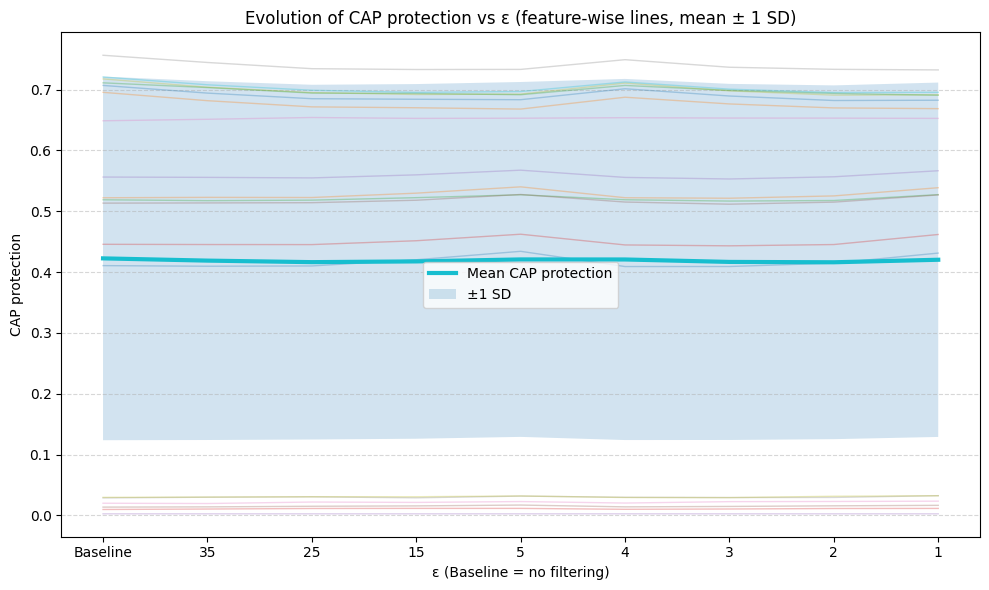

'Done.'

In [33]:
# Retry: aggregate duplicates explicitly before pivoting to avoid "duplicate entries" errors.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_eps_key(k: str):
    if k == "none":
        return "Baseline"
    s = k.strip()
    try:
        val = float(s)
        return f"{val:g}"
    except Exception:
        pass
    if s.startswith("0"):
        val = float("0." + s[1:])
        return f"{val:g}"
    return s

# Build long-form dataframe from 'results' defined earlier
rows = []
for feat, eps_dict in credit_ctgan_disclosure_protection.items():
    for k, vals in eps_dict.items():
        rows.append({
            "feature": feat,
            "eps_label": parse_eps_key(k),
            "cap_protection": vals.get("cap_protection", np.nan)
        })
df = pd.DataFrame(rows)

# Aggregate to remove any accidental duplicates of (feature, eps_label)
df = df.groupby(["feature", "eps_label"], as_index=False)["cap_protection"].mean()

# Order labels
num_labels = sorted([l for l in df["eps_label"].unique() if l != "Baseline"], key=lambda x: float(x), reverse=True)
ordered_labels = ["Baseline"] + num_labels
df["eps_label"] = pd.Categorical(df["eps_label"], categories=ordered_labels, ordered=True)

# Pivot
pivot = df.pivot_table(index="feature", columns="eps_label", values="cap_protection", aggfunc="mean").reindex(columns=ordered_labels)

# Aggregation
agg = pd.DataFrame({
    "epsilon": ordered_labels,
    "cap_mean": pivot.mean(axis=0).values,
    "cap_std": pivot.std(axis=0, ddof=1).values
})

# Plot
plt.figure(figsize=(10, 6))

xs = np.arange(len(ordered_labels))
for feat, row in pivot.iterrows():
    plt.plot(xs, row.values.astype(float), linewidth=1, alpha=0.3)

ys = agg["cap_mean"].values
yerr = agg["cap_std"].values
plt.plot(xs, ys, linewidth=3, label="Mean CAP protection")
plt.fill_between(xs, ys - yerr, ys + yerr, alpha=0.2, label="±1 SD")

plt.xticks(xs, ordered_labels, rotation=0)
plt.xlabel("ε (Baseline = no filtering)")
plt.ylabel("CAP protection")
plt.title("Evolution of CAP protection vs ε (feature-wise lines, mean ± 1 SD)")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


"Done."


In [35]:
for key, disclosure_protection in credit_ctgan_disclosure_protection.items() :
    print(f"\n===={key}====\n")
    print(pd.DataFrame(disclosure_protection))


====BILL_AMT1====

                         none        04       035        03       025        02       015        01       005       001      0005
score                0.456210  0.454512  0.455083  0.454589  0.455616  0.460704  0.466927  0.469785  0.479910  0.488423  0.484739
cap_protection       0.410589  0.409061  0.409574  0.409130  0.410054  0.414633  0.420234  0.422806  0.431919  0.439581  0.436265
baseline_protection  0.900000  0.900000  0.900000  0.900000  0.900000  0.900000  0.900000  0.900000  0.900000  0.900000  0.900000

====BILL_AMT2====

                         none        04       035        03       025        02       015        01       005       001      0005
score                0.587397  0.587453  0.588133  0.586516  0.587847  0.590814  0.595897  0.598887  0.605442  0.613095  0.609682
cap_protection       0.522131  0.522180  0.522785  0.521347  0.522530  0.525168  0.529687  0.532344  0.538171  0.544973  0.541940
baseline_protection  0.888889  0.888889  0.888889 

Parsed 19 features, 11 parameters, metrics=['baseline_protection', 'cap_protection', 'score']

== Summary (head) ==
param  n_features  mean_cap_protection  std_cap_protection  ci95_low_cap  ci95_high_cap  delta_vs_none_cap  mean_score  std_score  ci95_low_score  ci95_high_score  delta_vs_none_score  pct_features_improved
 none          19             0.422497            0.298892      0.288099       0.556896           0.000000    0.471316   0.331631        0.322197         0.620435             0.000000               0.000000
   04          19             0.420679            0.296798      0.287223       0.554136          -0.001818    0.469319   0.329380        0.321211         0.617426            -0.001997               0.473684
  035          19             0.418810            0.294869      0.286221       0.551399          -0.003687    0.467249   0.327278        0.320087         0.614411            -0.004067               0.421053
   03          19             0.416659            0.2926

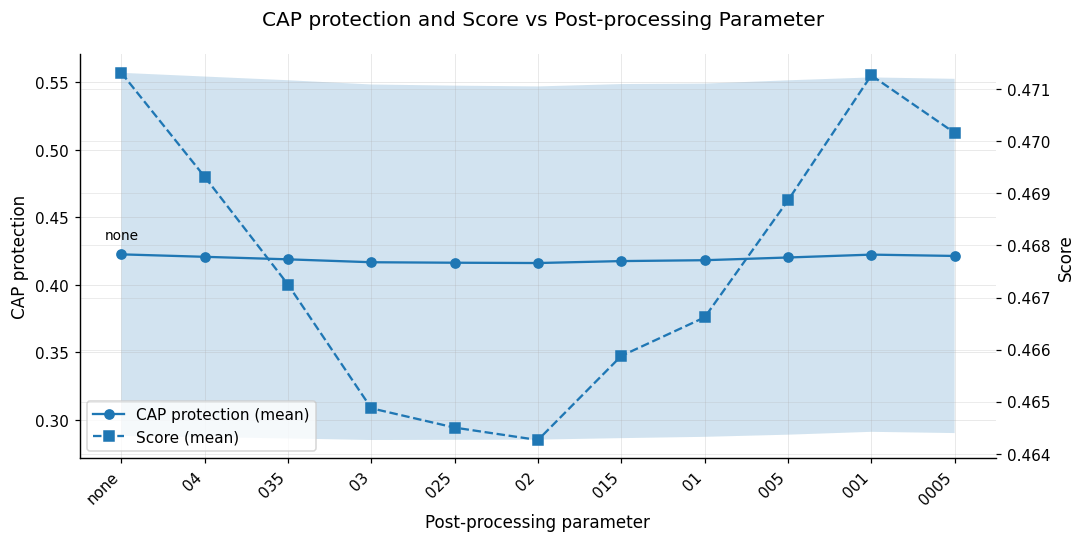

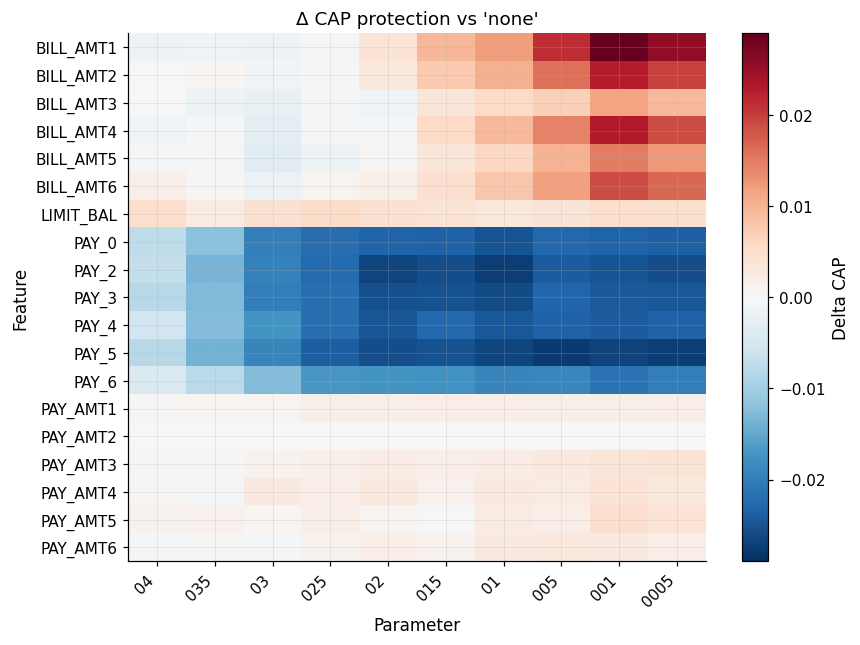

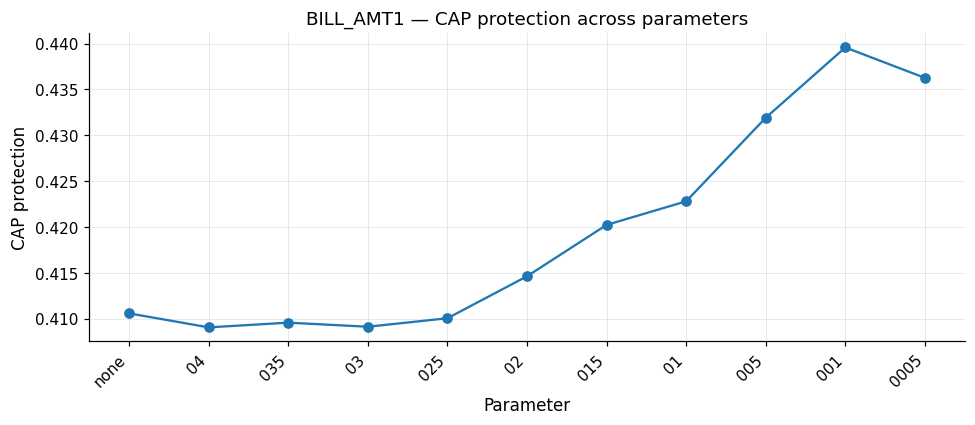

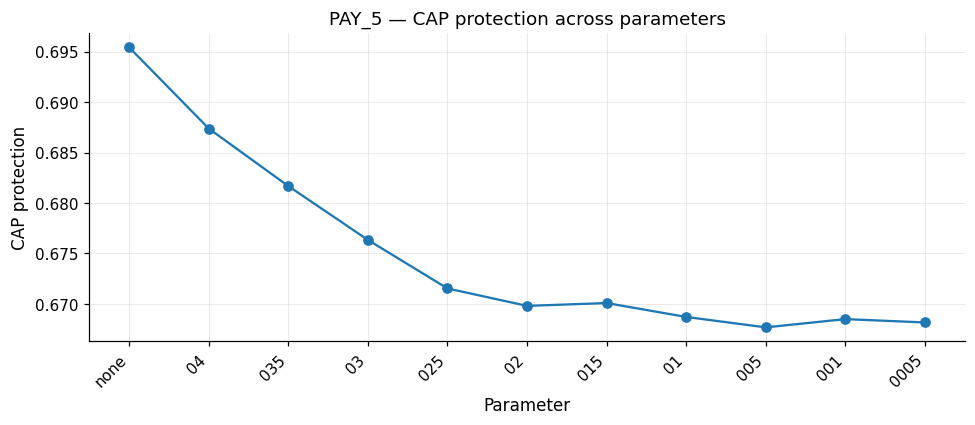

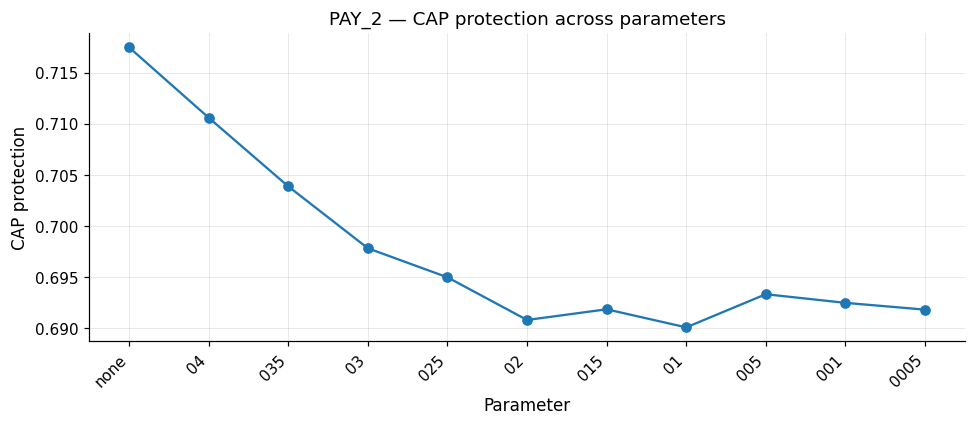

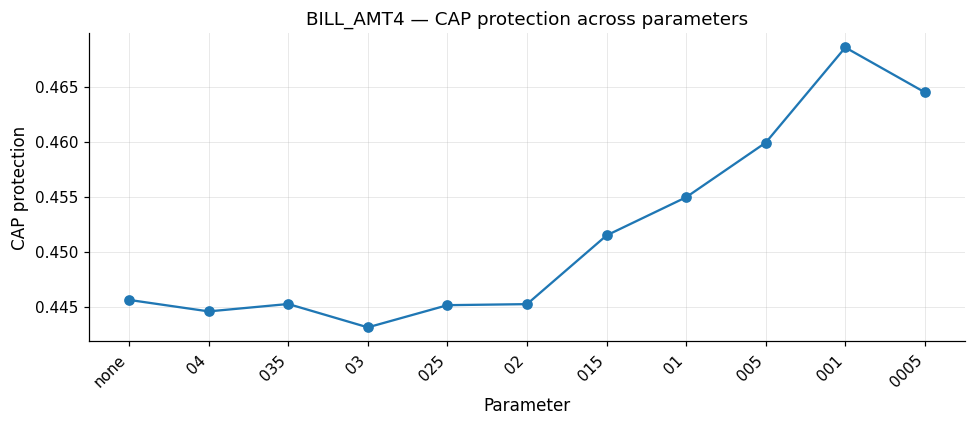

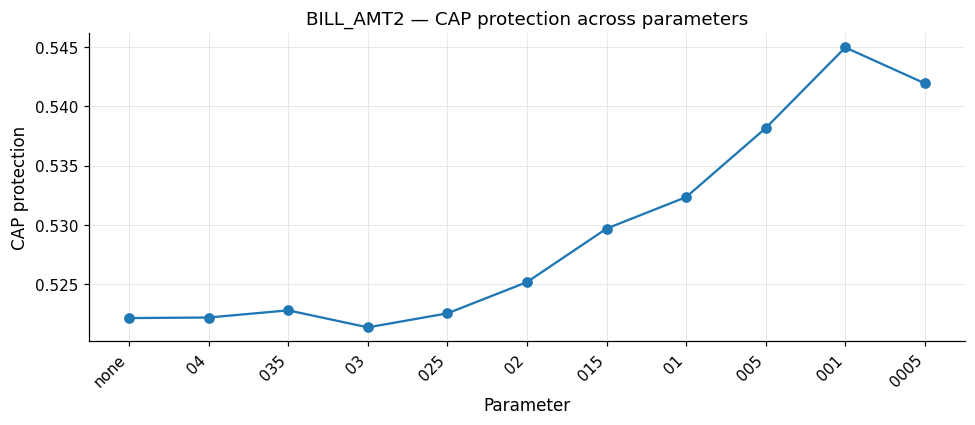

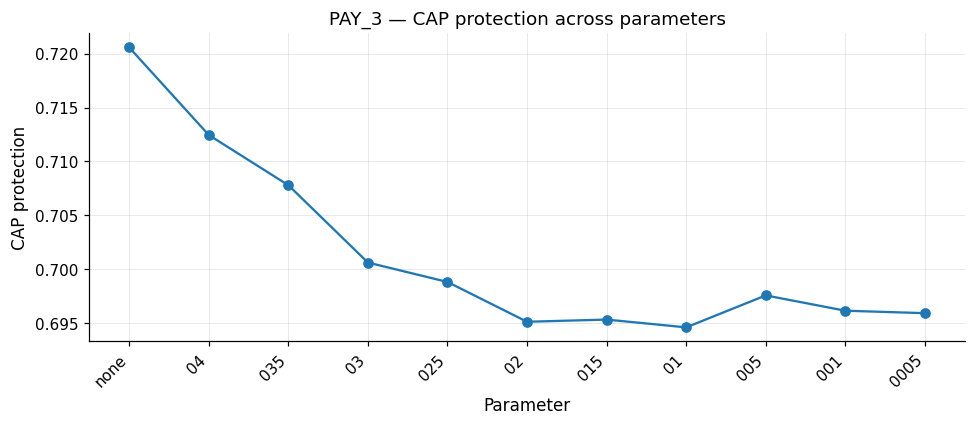


Files written:
outputs/summary_cap_by_param.csv
outputs/best_param_by_feature.csv
outputs/aggregate_line.png outputs/aggregate_line.svg
outputs/heatmap_delta_vs_none.png outputs/heatmap_delta_vs_none.svg
outputs/feature_BILL_AMT1_cap.png
outputs/feature_PAY_5_cap.png
outputs/feature_PAY_2_cap.png
outputs/feature_BILL_AMT4_cap.png
outputs/feature_BILL_AMT2_cap.png
outputs/feature_PAY_3_cap.png


In [ ]:
# ---------------------------- run pipeline -----------------------------------
# Expect a dict named `results` in the notebook (defined in another cell).


df_long, param_order = flatten_results(credit_ctgan_disclosure_protection)
n_features = df_long["feature"].nunique()
params = list(df_long["param"].cat.categories)
metrics = sorted(df_long["metric"].unique().tolist())

print(f"Parsed {n_features} features, {len(params)} parameters, metrics={metrics}")
summary = make_summary(df_long, baseline_param="none")
best = best_param_by_feature(df_long, baseline_param="none")

out_dir = Path(output_dir); out_dir.mkdir(parents=True, exist_ok=True)
summary_path = out_dir / "summary_cap_by_param.csv"
best_path = out_dir / "best_param_by_feature.csv"
summary.to_csv(summary_path, index=False)
best.to_csv(best_path, index=False)

print("\n== Summary (head) ==")
print(summary.head(10).to_string(index=False))
print("\n== Best param by feature (head) ==")
print(best.head(10).to_string(index=False))

aggr_png, aggr_svg = plot_aggregate(summary, out_dir)
heat_png, heat_svg = plot_delta_heatmap(df_long, out_dir, baseline_param="none")
topk_paths = plot_topk_features(df_long, out_dir, top_k=top_k)

print("\nFiles written:")
print(summary_path)
print(best_path)
print(aggr_png, aggr_svg)
print(heat_png, heat_svg)
for feat, p in topk_paths:
    print(p)
# =============================================================================

#### Credit Card TVAE

In [12]:
import pickle

with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_BILL_AMT1.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_BILL_AMT1 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_BILL_AMT2.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_BILL_AMT2 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_BILL_AMT3.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_BILL_AMT3 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_BILL_AMT4.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_BILL_AMT4 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_BILL_AMT5.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_BILL_AMT5 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_BILL_AMT6.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_BILL_AMT6 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_LIMIT_BAL.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_LIMIT_BAL = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_0.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_0 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_2.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_2 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_3.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_3 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_4.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_4 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_5.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_5 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_6.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_6 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_AMT1.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_AMT1 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_AMT2.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_AMT2 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_AMT3.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_AMT3 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_AMT4.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_AMT4 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_AMT5.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_AMT5 = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/credit_tvae_new_disclosure_protection_PAY_AMT6.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_disclosure_protection_PAY_AMT6 = pickle.load(file)



credit_tvae_disclosure_protection  = {
'BILL_AMT1' : credit_tvae_disclosure_protection_BILL_AMT1,
'BILL_AMT2' : credit_tvae_disclosure_protection_BILL_AMT2,
'BILL_AMT3' : credit_tvae_disclosure_protection_BILL_AMT3,
'BILL_AMT4' : credit_tvae_disclosure_protection_BILL_AMT4,
'BILL_AMT5' : credit_tvae_disclosure_protection_BILL_AMT5,
'BILL_AMT6' : credit_tvae_disclosure_protection_BILL_AMT6,
'LIMIT_BAL' : credit_tvae_disclosure_protection_LIMIT_BAL,
'PAY_0' : credit_tvae_disclosure_protection_PAY_0,
'PAY_2' : credit_tvae_disclosure_protection_PAY_2,
'PAY_3' : credit_tvae_disclosure_protection_PAY_3,
'PAY_4' : credit_tvae_disclosure_protection_PAY_4,
'PAY_5' : credit_tvae_disclosure_protection_PAY_5,
'PAY_6' : credit_tvae_disclosure_protection_PAY_6,
'PAY_AMT1' : credit_tvae_disclosure_protection_PAY_AMT1,
'PAY_AMT2' : credit_tvae_disclosure_protection_PAY_AMT2,
'PAY_AMT3' : credit_tvae_disclosure_protection_PAY_AMT3,
'PAY_AMT4' : credit_tvae_disclosure_protection_PAY_AMT4,
'PAY_AMT5' : credit_tvae_disclosure_protection_PAY_AMT5,
'PAY_AMT6' : credit_tvae_disclosure_protection_PAY_AMT6,   
}



In [13]:
credit_tvae_disclosure_protection

{'BILL_AMT1': {'none': {'score': 0.46999626541914313,
   'cap_protection': 0.4229966388772288,
   'baseline_protection': 0.9},
  '04': {'score': 0.47635580876367717,
   'cap_protection': 0.42872022788730946,
   'baseline_protection': 0.9},
  '03': {'score': 0.4816593906664771,
   'cap_protection': 0.43349345159982944,
   'baseline_protection': 0.9},
  '025': {'score': 0.4838598845663221,
   'cap_protection': 0.4354738961096899,
   'baseline_protection': 0.9},
  '02': {'score': 0.4848987430716536,
   'cap_protection': 0.43640886876448826,
   'baseline_protection': 0.9},
  '015': {'score': 0.4855343135383166,
   'cap_protection': 0.43698088218448494,
   'baseline_protection': 0.9},
  '01': {'score': 0.48860536780501335,
   'cap_protection': 0.439744831024512,
   'baseline_protection': 0.9},
  '005': {'score': 0.4918890335253824,
   'cap_protection': 0.44270013017284415,
   'baseline_protection': 0.9},
  '001': {'score': 0.49539582362227835,
   'cap_protection': 0.4458562412600505,
   'ba

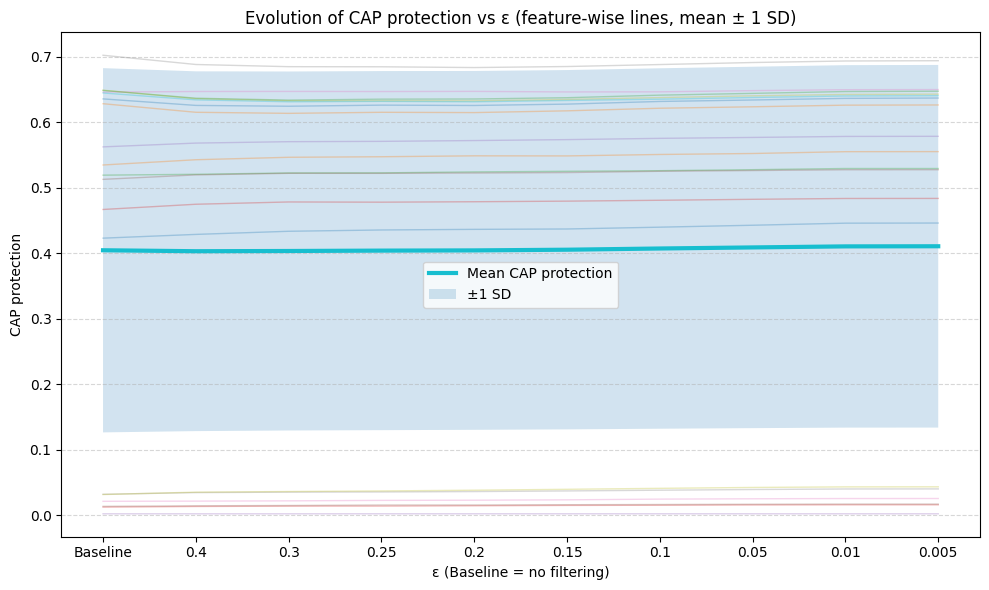

'Done.'

In [50]:
# Retry: aggregate duplicates explicitly before pivoting to avoid "duplicate entries" errors.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_eps_key(k: str):
    if k == "none":
        return "Baseline"
    s = k.strip()
    try:
        if s.startswith("0"):
            val = float("0." + s[1:])
            return f"{val:g}"
    except Exception:
        pass

    return s

# Build long-form dataframe from 'results' defined earlier
rows = []
for feat, eps_dict in credit_tvae_disclosure_protection.items():
    for k, vals in eps_dict.items():
        rows.append({
            "feature": feat,
            "eps_label": parse_eps_key(k),
            "cap_protection": vals.get("cap_protection", np.nan)
        })
df = pd.DataFrame(rows)

# Aggregate to remove any accidental duplicates of (feature, eps_label)
df = df.groupby(["feature", "eps_label"], as_index=False)["cap_protection"].mean()

# Order labels
num_labels = sorted([l for l in df["eps_label"].unique() if l != "Baseline"], key=lambda x: float(x), reverse=True)
ordered_labels = ["Baseline"] + num_labels
df["eps_label"] = pd.Categorical(df["eps_label"], categories=ordered_labels, ordered=True)

# Pivot
pivot = df.pivot_table(index="feature", columns="eps_label", values="cap_protection", aggfunc="mean").reindex(columns=ordered_labels)

# Aggregation
agg = pd.DataFrame({
    "epsilon": ordered_labels,
    "cap_mean": pivot.mean(axis=0).values,
    "cap_std": pivot.std(axis=0, ddof=1).values
})

# Plot
plt.figure(figsize=(10, 6))

xs = np.arange(len(ordered_labels))
for feat, row in pivot.iterrows():
    plt.plot(xs, row.values.astype(float), linewidth=1, alpha=0.3)

ys = agg["cap_mean"].values
yerr = agg["cap_std"].values
plt.plot(xs, ys, linewidth=3, label="Mean CAP protection")
plt.fill_between(xs, ys - yerr, ys + yerr, alpha=0.2, label="±1 SD")

plt.xticks(xs, ordered_labels, rotation=0)
plt.xlabel("ε (Baseline = no filtering)")
plt.ylabel("CAP protection")
plt.title("Evolution of CAP protection vs ε (feature-wise lines, mean ± 1 SD)")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


"Done."


In [47]:
df

,feature,eps_label,cap_protection
0,BILL_AMT1,1,0.442801
1,BILL_AMT1,15,0.436981
2,BILL_AMT1,2,0.436409
3,BILL_AMT1,25,0.435474
4,BILL_AMT1,3,0.433493
...,...,...,...
147,PAY_AMT6,25,0.037459
148,PAY_AMT6,3,0.036561
149,PAY_AMT6,4,0.035597
150,PAY_AMT6,5,0.043239


In [16]:
for key, disclosure_protection in credit_tvae_disclosure_protection.items() :
    print(f"\n===={key}====\n")
    print(pd.DataFrame(disclosure_protection))



====BILL_AMT1====

                         none        04        03       025        02  \
score                0.469996  0.476356  0.481659  0.483860  0.484899   
cap_protection       0.422997  0.428720  0.433493  0.435474  0.436409   
baseline_protection  0.900000  0.900000  0.900000  0.900000  0.900000   

                          015        01       005       001      0005  
score                0.485534  0.488605  0.491889  0.495396  0.495616  
cap_protection       0.436981  0.439745  0.442700  0.445856  0.446055  
baseline_protection  0.900000  0.900000  0.900000  0.900000  0.900000  

====BILL_AMT2====

                         none        04        03       025        02  \
score                0.601423  0.610427  0.614635  0.615569  0.617141   
cap_protection       0.534599  0.542602  0.546342  0.547172  0.548570   
baseline_protection  0.888889  0.888889  0.888889  0.888889  0.888889   

                          015        01       005       001      0005  
score         

#### Adult CTGAN

In [15]:
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_ctgan_disclosure_protection_capital-gain.pkl', 'rb') as file:

    # Deserialize the object from the file
    adult_ctgan_disclosure_protection_capital_gain = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_ctgan_disclosure_protection_capital-loss.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_disclosure_protection_capital_loss = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_ctgan_disclosure_protection_hours-per-week.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_disclosure_protection_hours_per_week = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_ctgan_disclosure_protection_income.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_disclosure_protection_income = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_ctgan_disclosure_protection_native-country.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_disclosure_protection_native_country = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_ctgan_disclosure_protection_race.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_disclosure_protection_race = pickle.load(file)



adult_ctgan_disclosure_protection  = {
'capital-gain' : adult_ctgan_disclosure_protection_capital_gain,
'capital-loss' : adult_ctgan_disclosure_protection_capital_loss,
'hours-per-week' : adult_ctgan_disclosure_protection_hours_per_week,
'income' : adult_ctgan_disclosure_protection_income,
# 'native-country' : adult_ctgan_disclosure_protection_native_country,
'race' : adult_ctgan_disclosure_protection_race, 
}



In [16]:
adult_ctgan_disclosure_protection

{'capital-gain': {'none': {'score': 0.05352291493983947,
   'cap_protection': 0.04460242911653289,
   'baseline_protection': 0.8333333333333334},
  '04': {'score': 0.05307327006502005,
   'cap_protection': 0.044227725054183376,
   'baseline_protection': 0.8333333333333334},
  '035': {'score': 0.0537771172738231,
   'cap_protection': 0.04481426439485259,
   'baseline_protection': 0.8333333333333334},
  '03': {'score': 0.0544960543086193,
   'cap_protection': 0.045413378590516085,
   'baseline_protection': 0.8333333333333334},
  '025': {'score': 0.05553703916514125,
   'cap_protection': 0.046280865970951046,
   'baseline_protection': 0.8333333333333334},
  '02': {'score': 0.05784295750401118,
   'cap_protection': 0.048202464586675986,
   'baseline_protection': 0.8333333333333334},
  '015': {'score': 0.055350729463729785,
   'cap_protection': 0.04612560788644149,
   'baseline_protection': 0.8333333333333334},
  '01': {'score': 0.05891890876000527,
   'cap_protection': 0.04909909063333773,

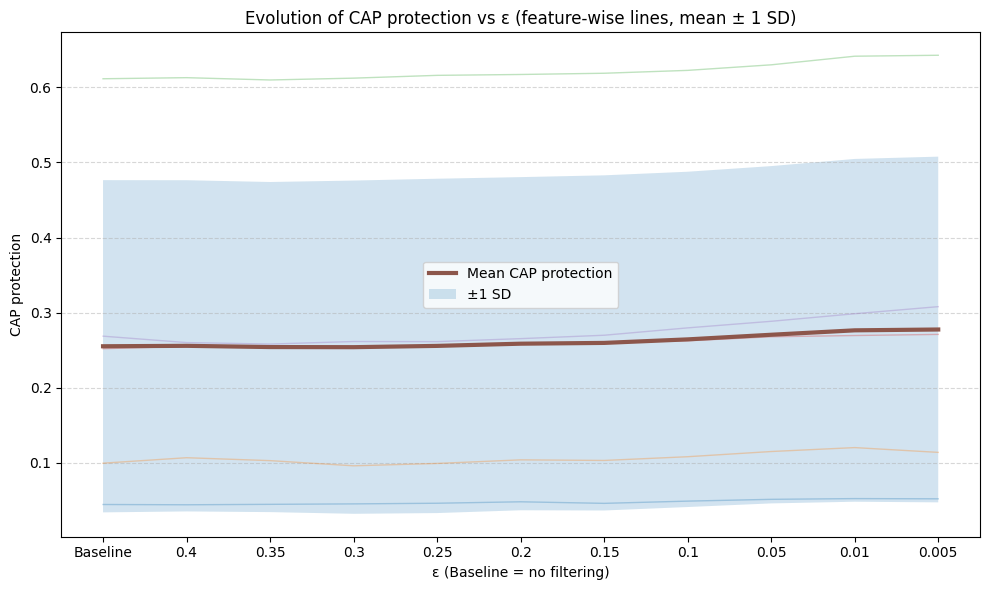

'Done.'

In [51]:
# Retry: aggregate duplicates explicitly before pivoting to avoid "duplicate entries" errors.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_eps_key(k: str):
    if k == "none":
        return "Baseline"
    s = k.strip()
    try:
        if s.startswith("0"):
            val = float("0." + s[1:])
            return f"{val:g}"
    except Exception:
        pass

    return s

# Build long-form dataframe from 'results' defined earlier
rows = []
for feat, eps_dict in adult_ctgan_disclosure_protection.items():
    for k, vals in eps_dict.items():
        rows.append({
            "feature": feat,
            "eps_label": parse_eps_key(k),
            "cap_protection": vals.get("cap_protection", np.nan)
        })
df = pd.DataFrame(rows)

# Aggregate to remove any accidental duplicates of (feature, eps_label)
df = df.groupby(["feature", "eps_label"], as_index=False)["cap_protection"].mean()

# Order labels
num_labels = sorted([l for l in df["eps_label"].unique() if l != "Baseline"], key=lambda x: float(x), reverse=True)
ordered_labels = ["Baseline"] + num_labels
df["eps_label"] = pd.Categorical(df["eps_label"], categories=ordered_labels, ordered=True)

# Pivot
pivot = df.pivot_table(index="feature", columns="eps_label", values="cap_protection", aggfunc="mean").reindex(columns=ordered_labels)

# Aggregation
agg = pd.DataFrame({
    "epsilon": ordered_labels,
    "cap_mean": pivot.mean(axis=0).values,
    "cap_std": pivot.std(axis=0, ddof=1).values
})

# Plot
plt.figure(figsize=(10, 6))

xs = np.arange(len(ordered_labels))
for feat, row in pivot.iterrows():
    plt.plot(xs, row.values.astype(float), linewidth=1, alpha=0.3)

ys = agg["cap_mean"].values
yerr = agg["cap_std"].values
plt.plot(xs, ys, linewidth=3, label="Mean CAP protection")
plt.fill_between(xs, ys - yerr, ys + yerr, alpha=0.2, label="±1 SD")

plt.xticks(xs, ordered_labels, rotation=0)
plt.xlabel("ε (Baseline = no filtering)")
plt.ylabel("CAP protection")
plt.title("Evolution of CAP protection vs ε (feature-wise lines, mean ± 1 SD)")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


"Done."


In [18]:
for key, disclosure_protection in adult_ctgan_disclosure_protection.items() :
    print(f"\n===={key}====\n")
    print(pd.DataFrame(disclosure_protection))


====capital-gain====

                         none        04       035        03       025  \
score                0.053523  0.053073  0.053777  0.054496  0.055537   
cap_protection       0.044602  0.044228  0.044814  0.045413  0.046281   
baseline_protection  0.833333  0.833333  0.833333  0.833333  0.833333   

                           02       015        01       005       001  \
score                0.057843  0.055351  0.058919  0.061769  0.062952   
cap_protection       0.048202  0.046126  0.049099  0.051474  0.052460   
baseline_protection  0.833333  0.833333  0.833333  0.833333  0.833333   

                         0005  
score                0.062593  
cap_protection       0.052161  
baseline_protection  0.833333  

====capital-loss====

                         none        04       035        03       025  \
score                0.112065  0.120245  0.115880  0.108119  0.111675   
cap_protection       0.099613  0.106884  0.103004  0.096106  0.099266   
baseline_protection  

#### Adult TVAE

In [17]:
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_tvae_disclosure_protection_capital-gain.pkl', 'rb') as file:

    # Deserialize the object from the file
    adult_tvae_disclosure_protection_capital_gain = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_tvae_disclosure_protection_capital-loss.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_disclosure_protection_capital_loss = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_tvae_disclosure_protection_hours-per-week.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_disclosure_protection_hours_per_week = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_tvae_disclosure_protection_income.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_disclosure_protection_income = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_tvae_disclosure_protection_native-country.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_disclosure_protection_native_country = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/adult_tvae_disclosure_protection_race.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_disclosure_protection_race = pickle.load(file)



adult_tvae_disclosure_protection  = {
'capital-gain' : adult_tvae_disclosure_protection_capital_gain,
'capital-loss' : adult_tvae_disclosure_protection_capital_loss,
'hours-per-week' : adult_tvae_disclosure_protection_hours_per_week,
'income' : adult_tvae_disclosure_protection_income,
# 'native-country' : adult_tvae_disclosure_protection_native_country,
'race' : adult_tvae_disclosure_protection_race, 
}



In [11]:
adult_tvae_disclosure_protection

{'capital-gain': {'none': {'score': 0.03795927371087684,
   'cap_protection': 0.031632728092397366,
   'baseline_protection': 0.8333333333333334},
  '04': {'score': 0.03804184453478125,
   'cap_protection': 0.03170153711231771,
   'baseline_protection': 0.8333333333333334},
  '035': {'score': 0.03823701205611361,
   'cap_protection': 0.031864176713428005,
   'baseline_protection': 0.8333333333333334},
  '03': {'score': 0.03882418744058573,
   'cap_protection': 0.032353489533821445,
   'baseline_protection': 0.8333333333333334},
  '025': {'score': 0.03958717405434888,
   'cap_protection': 0.0329893117119574,
   'baseline_protection': 0.8333333333333334},
  '02': {'score': 0.04033687751378823,
   'cap_protection': 0.03361406459482352,
   'baseline_protection': 0.8333333333333334},
  '015': {'score': 0.040846554578602846,
   'cap_protection': 0.03403879548216904,
   'baseline_protection': 0.8333333333333334},
  '01': {'score': 0.04165989743809177,
   'cap_protection': 0.03471658119840981,

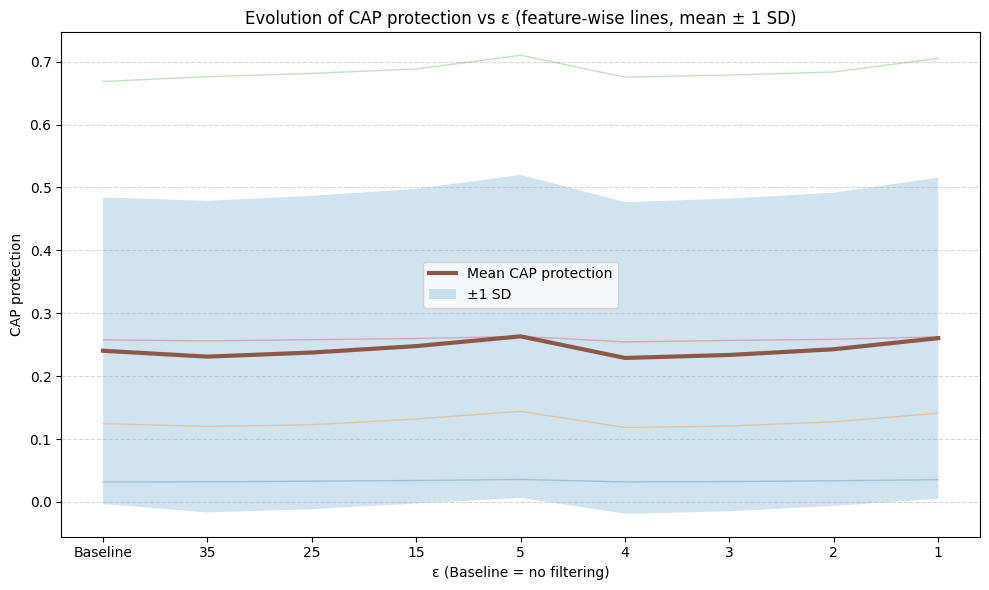

'Done.'

In [45]:
# Retry: aggregate duplicates explicitly before pivoting to avoid "duplicate entries" errors.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_eps_key(k: str):
    if k == "none":
        return "Baseline"
    s = k.strip()
    try:
        val = float(s)
        return f"{val:g}"
    except Exception:
        pass
    if s.startswith("0"):
        val = float("0." + s[1:])
        return f"{val:g}"
    return s

# Build long-form dataframe from 'results' defined earlier
rows = []
for feat, eps_dict in adult_tvae_disclosure_protection.items():
    for k, vals in eps_dict.items():
        rows.append({
            "feature": feat,
            "eps_label": parse_eps_key(k),
            "cap_protection": vals.get("cap_protection", np.nan)
        })
df = pd.DataFrame(rows)

# Aggregate to remove any accidental duplicates of (feature, eps_label)
df = df.groupby(["feature", "eps_label"], as_index=False)["cap_protection"].mean()

# Order labels
num_labels = sorted([l for l in df["eps_label"].unique() if l != "Baseline"], key=lambda x: float(x), reverse=True)
ordered_labels = ["Baseline"] + num_labels
df["eps_label"] = pd.Categorical(df["eps_label"], categories=ordered_labels, ordered=True)

# Pivot
pivot = df.pivot_table(index="feature", columns="eps_label", values="cap_protection", aggfunc="mean").reindex(columns=ordered_labels)

# Aggregation
agg = pd.DataFrame({
    "epsilon": ordered_labels,
    "cap_mean": pivot.median(axis=0).values,
    "cap_std": pivot.std(axis=0, ddof=1).values
})

# Plot
plt.figure(figsize=(10, 6))

xs = np.arange(len(ordered_labels))
for feat, row in pivot.iterrows():
    plt.plot(xs, row.values.astype(float), linewidth=1, alpha=0.3)

ys = agg["cap_mean"].values
yerr = agg["cap_std"].values
plt.plot(xs, ys, linewidth=3, label="Mean CAP protection")
plt.fill_between(xs, ys - yerr, ys + yerr, alpha=0.2, label="±1 SD")

plt.xticks(xs, ordered_labels, rotation=0)
plt.xlabel("ε (Baseline = no filtering)")
plt.ylabel("CAP protection")
plt.title("Evolution of CAP protection vs ε (feature-wise lines, mean ± 1 SD)")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


"Done."


In [20]:
for key, disclosure_protection in adult_tvae_disclosure_protection.items() :
    print(f"\n===={key}====\n")
    print(pd.DataFrame(disclosure_protection))


====capital-gain====

                         none        04       035        03       025  \
score                0.037959  0.038042  0.038237  0.038824  0.039587   
cap_protection       0.031633  0.031702  0.031864  0.032353  0.032989   
baseline_protection  0.833333  0.833333  0.833333  0.833333  0.833333   

                           02       015        01       005       001  \
score                0.040337  0.040847  0.041660  0.042362  0.043217   
cap_protection       0.033614  0.034039  0.034717  0.035302  0.036014   
baseline_protection  0.833333  0.833333  0.833333  0.833333  0.833333   

                         0005  
score                0.043351  
cap_protection       0.036126  
baseline_protection  0.833333  

====capital-loss====

                         none        04       035        03       025  \
score                0.139986  0.133097  0.135033  0.135751  0.138026   
cap_protection       0.124432  0.118308  0.120029  0.120668  0.122690   
baseline_protection  

#### CARDIO CTGAN

In [18]:
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_ctgan_disclosure_protection_active.pkl', 'rb') as file:

    # Deserialize the object from the file
    cardio_ctgan_disclosure_protection_active = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_ctgan_disclosure_protection_alco.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_disclosure_protection_alco = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_ctgan_disclosure_protection_ap_hi.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_disclosure_protection_ap_hi = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_ctgan_disclosure_protection_ap_lo.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_disclosure_protection_ap_lo = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_ctgan_disclosure_protection_cardio.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_disclosure_protection_cardio = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_ctgan_disclosure_protection_cholesterol.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_disclosure_protection_cholesterol = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_ctgan_disclosure_protection_gluc.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_disclosure_protection_gluc = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_ctgan_disclosure_protection_smoke.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_disclosure_protection_smoke = pickle.load(file)



cardio_ctgan_disclosure_protection  = {
'active' : cardio_ctgan_disclosure_protection_active,
'alco' : cardio_ctgan_disclosure_protection_alco,
'ap_hi' : cardio_ctgan_disclosure_protection_ap_hi,
'ap_lo' : cardio_ctgan_disclosure_protection_ap_lo,
'cardio' : cardio_ctgan_disclosure_protection_cardio,
'cholesterol' : cardio_ctgan_disclosure_protection_cholesterol,
'gluc' : cardio_ctgan_disclosure_protection_gluc,
'smoke' : cardio_ctgan_disclosure_protection_smoke
}



In [44]:
cardio_ctgan_disclosure_protection

{'active': {'none': {'score': 0.6841868136242275,
   'cap_protection': 0.34209340681211375,
   'baseline_protection': 0.5},
  '04': {'score': 0.6641779781491175,
   'cap_protection': 0.33208898907455875,
   'baseline_protection': 0.5},
  '035': {'score': 0.6631789677928823,
   'cap_protection': 0.33158948389644116,
   'baseline_protection': 0.5},
  '03': {'score': 0.6564771562836071,
   'cap_protection': 0.32823857814180357,
   'baseline_protection': 0.5},
  '025': {'score': 0.6537016667586018,
   'cap_protection': 0.3268508333793009,
   'baseline_protection': 0.5},
  '02': {'score': 0.6588087478737774,
   'cap_protection': 0.3294043739368887,
   'baseline_protection': 0.5},
  '015': {'score': 0.6576470329213646,
   'cap_protection': 0.3288235164606823,
   'baseline_protection': 0.5},
  '01': {'score': 0.6614635252960233,
   'cap_protection': 0.33073176264801163,
   'baseline_protection': 0.5},
  '005': {'score': 0.6684396083427995,
   'cap_protection': 0.33421980417139974,
   'baselin

In [22]:
for key, disclosure_protection in cardio_ctgan_disclosure_protection.items() :
    print(f"\n===={key}====\n")
    print(pd.DataFrame(disclosure_protection))


====active====

                         none        04       035        03       025  \
score                0.684187  0.664178  0.663179  0.656477  0.653702   
cap_protection       0.342093  0.332089  0.331589  0.328239  0.326851   
baseline_protection  0.500000  0.500000  0.500000  0.500000  0.500000   

                           02       015        01      005       001      0005  
score                0.658809  0.657647  0.661464  0.66844  0.674637  0.677779  
cap_protection       0.329404  0.328824  0.330732  0.33422  0.337318  0.338889  
baseline_protection  0.500000  0.500000  0.500000  0.50000  0.500000  0.500000  

====alco====

                         none       04       035        03       025  \
score                0.304823  0.24706  0.243903  0.248202  0.254039   
cap_protection       0.152412  0.12353  0.121951  0.124101  0.127019   
baseline_protection  0.500000  0.50000  0.500000  0.500000  0.500000   

                           02       015        01       005   

#### CARDIO TVAE

In [19]:
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_tvae_disclosure_protection_active.pkl', 'rb') as file:

    # Deserialize the object from the file
    cardio_tvae_disclosure_protection_active = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_tvae_disclosure_protection_alco.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_disclosure_protection_alco = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_tvae_disclosure_protection_ap_hi.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_disclosure_protection_ap_hi = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_tvae_disclosure_protection_ap_lo.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_disclosure_protection_ap_lo = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_tvae_disclosure_protection_cardio.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_disclosure_protection_cardio = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_tvae_disclosure_protection_cholesterol.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_disclosure_protection_cholesterol = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_tvae_disclosure_protection_gluc.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_disclosure_protection_gluc = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_disclosure_protection_comparison_heom_any/cardio_tvae_disclosure_protection_smoke.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_disclosure_protection_smoke = pickle.load(file)



cardio_tvae_disclosure_protection  = {
'active' : cardio_tvae_disclosure_protection_active,
'alco' : cardio_tvae_disclosure_protection_alco,
'ap_hi' : cardio_tvae_disclosure_protection_ap_hi,
'ap_lo' : cardio_tvae_disclosure_protection_ap_lo,
'cardio' : cardio_tvae_disclosure_protection_cardio,
'cholesterol' : cardio_tvae_disclosure_protection_cholesterol,
'gluc' : cardio_tvae_disclosure_protection_gluc,
'smoke' : cardio_tvae_disclosure_protection_smoke
}



In [20]:
cardio_tvae_disclosure_protection

{'active': {'none': {'score': 0.6383858320334777,
   'cap_protection': 0.3191929160167388,
   'baseline_protection': 0.5},
  '04': {'score': 0.6134889439603233,
   'cap_protection': 0.30674447198016164,
   'baseline_protection': 0.5},
  '035': {'score': 0.6095417217823487,
   'cap_protection': 0.30477086089117433,
   'baseline_protection': 0.5},
  '03': {'score': 0.6085346862597609,
   'cap_protection': 0.30426734312988046,
   'baseline_protection': 0.5},
  '025': {'score': 0.6105156464872876,
   'cap_protection': 0.3052578232436438,
   'baseline_protection': 0.5},
  '02': {'score': 0.614062036048038,
   'cap_protection': 0.307031018024019,
   'baseline_protection': 0.5},
  '015': {'score': 0.6183657180005755,
   'cap_protection': 0.30918285900028775,
   'baseline_protection': 0.5},
  '01': {'score': 0.6240719902646403,
   'cap_protection': 0.31203599513232017,
   'baseline_protection': 0.5},
  '005': {'score': 0.6316302063321952,
   'cap_protection': 0.3158151031660976,
   'baseline_p

In [24]:
for key, disclosure_protection in cardio_tvae_disclosure_protection.items() :
    print(f"\n===={key}====\n")
    print(pd.DataFrame(disclosure_protection))


====active====

                         none        04       035        03       025  \
score                0.638386  0.613489  0.609542  0.608535  0.610516   
cap_protection       0.319193  0.306744  0.304771  0.304267  0.305258   
baseline_protection  0.500000  0.500000  0.500000  0.500000  0.500000   

                           02       015        01       005       001  \
score                0.614062  0.618366  0.624072  0.631630  0.637381   
cap_protection       0.307031  0.309183  0.312036  0.315815  0.318690   
baseline_protection  0.500000  0.500000  0.500000  0.500000  0.500000   

                         0005  
score                0.638244  
cap_protection       0.319122  
baseline_protection  0.500000  

====alco====

                         none        04       035        03       025  \
score                0.171476  0.149026  0.151274  0.153493  0.155750   
cap_protection       0.085738  0.074513  0.075637  0.076746  0.077875   
baseline_protection  0.500000  0.50

### AIA 

#### Load data

##### Credit Ctgan

In [21]:

with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_dict_real_credit_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_real = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_dict_synth_credit_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_synth = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_0005.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_0005 = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_001.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_001 = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_005.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_005 = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_01.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_01 = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_015 = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_02 = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_015 = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_02 = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_025.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_025 = pickle.load(file)

with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_03.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_03 = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_035.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_035 = pickle.load(file)
with open(f'{RESULTS_DIR}/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_04.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_04 = pickle.load(file)

predictions_aia_credit_ctgan = {
    'real' : credit_real,
    'None': credit_synth,
    '0.4': credit_ctgan_eps_04,
    '0.35': credit_ctgan_eps_035,
    '0.3': credit_ctgan_eps_03,
    '0.25': credit_ctgan_eps_025,
    '0.2': credit_ctgan_eps_02,
    '0.15': credit_ctgan_eps_015,
    '0.1': credit_ctgan_eps_01,
    '0.05': credit_ctgan_eps_005,
    '0.01': credit_ctgan_eps_001,
    '0.005': credit_ctgan_eps_0005,
}


FileNotFoundError: [Errno 2] No such file or directory: '/home/dayav/projects/PipelineTabulareDataGeneration/experiments/pipeline_tabular_data_results/privacy_evaluation_withno_pipeline/predictions_dict_real_credit_heom_any_qai.pkl'

In [ ]:
with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_credit_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_real_ctgan = pickle.load(file)

with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_credit_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_synth = pickle.load(file)
with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_0005.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_0005 = pickle.load(file)
with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_001.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_001 = pickle.load(file)
with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_005.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_005 = pickle.load(file)
with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_01.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_01 = pickle.load(file)
with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_015 = pickle.load(file)
with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_02 = pickle.load(file)
with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_015 = pickle.load(file)
with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_02 = pickle.load(file)
with open('../load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_eps_0.005').attribute_synthetic_prediction/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_025.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_025 = pickle.load(file)

with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_03.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_03 = pickle.load(file)
with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_035.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_035 = pickle.load(file)
with open('../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_ctgan_eps_04.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_eps_04 = pickle.load(file)

predictions_aia_credit_ctgan_ = {
    'Real': credit_real_ctgan,
    'None': credit_synth,
    '0.4': credit_ctgan_eps_04,
    '0.35': credit_ctgan_eps_035,
    '0.3': credit_ctgan_eps_03,
    '0.25': credit_ctgan_eps_025,
    '0.2': credit_ctgan_eps_02,
    '0.15': credit_ctgan_eps_015,
    '0.1': credit_ctgan_eps_01,
    '0.05': credit_ctgan_eps_005,
    '0.01': credit_ctgan_eps_001,
    '0.005': credit_ctgan_eps_0005,
}


FileNotFoundError: [Errno 2] No such file or directory: '../results/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_credit_ctgan_heom_any_qai.pkl'

In [12]:
for first, second in zip(predictions_aia_credit_ctgan_.values(), predictions_aia_credit_ctgan.values()) :
    for feature, value in first.items() :
        assert len(value[value != second[feature]]) == 0, f'Inequality with {feature}'

In [ ]:
plot_classification_results(predictions_aia_credit_ctgan_, )

##### Credit Tvae

In [ ]:

with open('../scripts/privacy_evaluation_withno_pipeline/predictions_dict_real_credit_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_real = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/predictions_dict_synth_credit_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_synth = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_0005.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_0005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_001.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_001 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_005.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_01.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_01 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_025.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_025 = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_03.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_03 = pickle.load(file)
# with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_035.pkl', 'rb') as file:
#     # Deserialize the object from the file
#     credit_tvae_eps_035 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_04.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_04 = pickle.load(file)

predictions_aia_credit_tvae = {
    'real' : credit_real,
    'None': credit_synth,
    '0.4': credit_tvae_eps_04,
    '0.3': credit_tvae_eps_03,
    '0.25': credit_tvae_eps_025,
    '0.2': credit_tvae_eps_02,
    '0.15': credit_tvae_eps_015,
    '0.1': credit_tvae_eps_01,
    '0.05': credit_tvae_eps_005,
    '0.01': credit_tvae_eps_001,
    '0.005': credit_tvae_eps_0005,
}


In [ ]:

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_credit_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_real = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_credit_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_synth = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_0005.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_0005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_001.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_001 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_005.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_01.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_01 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_025.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_025 = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_03.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_03 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_035.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_035 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_credit_heom_any_credit_tvae_eps_04.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_eps_04 = pickle.load(file)

predictions_aia_credit_tvae_ = {
    'real' : credit_real,
    'None': credit_synth,
    '0.4': credit_tvae_eps_04,
    '0.35': credit_tvae_eps_035,
    '0.3': credit_tvae_eps_03,
    '0.25': credit_tvae_eps_025,
    '0.2': credit_tvae_eps_02,
    '0.15': credit_tvae_eps_015,
    '0.1': credit_tvae_eps_01,
    '0.05': credit_tvae_eps_005,
    '0.01': credit_tvae_eps_001,
    '0.005': credit_tvae_eps_0005,
}


In [15]:
for first, second in zip(predictions_aia_credit_tvae_.values(), predictions_aia_credit_tvae.values()) :
    for feature, value in first.items() :
        assert len(value[value != second[feature]]) == 0, f'Inequality with {feature}'

##### Adult Ctgan

In [ ]:
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_adult_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_real_ctgan = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_adult_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_synth = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_0005.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_0005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_001.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_001 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_005.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_01.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_01 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_025.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_025 = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_03.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_03 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_035.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_035 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_ctgan_eps_04.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_eps_04 = pickle.load(file)

predictions_aia_adult_ctgan = {
    'Real': adult_real_ctgan,
    'None': adult_synth,
    '0.4': adult_ctgan_eps_04,
    '0.35': adult_ctgan_eps_035,
    '0.3': adult_ctgan_eps_03,
    '0.25': adult_ctgan_eps_025,
    '0.2': adult_ctgan_eps_02,
    '0.15': adult_ctgan_eps_015,
    '0.1': adult_ctgan_eps_01,
    '0.05': adult_ctgan_eps_005,
    '0.01': adult_ctgan_eps_001,
    '0.005': adult_ctgan_eps_0005,
}


##### Adult Tvae

In [ ]:
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_adult_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_real_tvae = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_adult_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_synth = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_0005.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_0005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_001.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_001 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_005.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_01.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_01 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_025.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_025 = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_03.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_03 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_035.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_035 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_adult_heom_any_adult_tvae_eps_04.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_eps_04 = pickle.load(file)

predictions_aia_adult_tvae = {
    'Real': adult_real_tvae,
    'None': adult_synth,
    '0.4': adult_tvae_eps_04,
    '0.35': adult_tvae_eps_035,
    '0.3': adult_tvae_eps_03,
    '0.25': adult_tvae_eps_025,
    '0.2': adult_tvae_eps_02,
    '0.15': adult_tvae_eps_015,
    '0.1': adult_tvae_eps_01,
    '0.05': adult_tvae_eps_005,
    '0.01': adult_tvae_eps_001,
    '0.005': adult_tvae_eps_0005,
}


##### Cardio Ctgan

In [ ]:
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_cardio_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_real_ctgan = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_cardio_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_synth = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_0005.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_0005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_001.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_001 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_005.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_01.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_01 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_025.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_025 = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_03.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_03 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_035.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_035 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_04.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_04 = pickle.load(file)

predictions_aia_cardio_ctgan = {
    'Real': cardio_real_ctgan,
    'None': cardio_synth,
    '0.4': cardio_ctgan_eps_04,
    '0.35': cardio_ctgan_eps_035,
    '0.3': cardio_ctgan_eps_03,
    '0.25': cardio_ctgan_eps_025,
    '0.2': cardio_ctgan_eps_02,
    '0.15': cardio_ctgan_eps_015,
    '0.1': cardio_ctgan_eps_01,
    '0.05': cardio_ctgan_eps_005,
    '0.01': cardio_ctgan_eps_001,
    '0.005': cardio_ctgan_eps_0005,
}


In [ ]:
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_cardio_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_real = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_cardio_ctgan_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_none = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_0005.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_0005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_001.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_001 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_005.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_01.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_01 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_025.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_025 = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_03.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_03 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_035.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_035 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_ctgan_eps_04.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_eps_04 = pickle.load(file)

predictions_aia_cardio_ctgan_ = {
    'real': cardio_real,
    'None' : cardio_ctgan_none,
    '0.4': cardio_ctgan_eps_04,
    '0.35': cardio_ctgan_eps_035,
    '0.3': cardio_ctgan_eps_03,
    '0.25': cardio_ctgan_eps_025,
    '0.2': cardio_ctgan_eps_02,
    '0.15': cardio_ctgan_eps_015,
    '0.1': cardio_ctgan_eps_01,
    '0.05': cardio_ctgan_eps_005,
    '0.01': cardio_ctgan_eps_001,
    '0.005': cardio_ctgan_eps_0005,
}


In [51]:
for first, second in zip(predictions_aia_cardio_ctgan_.values(), predictions_aia_cardio_ctgan.values()) :
    for feature, value in first.items() :
        assert len(value[value != second[feature]]) == 0, f'Inequality with {feature}'

##### Cardio Tvae

In [ ]:
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_real_cardio_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_real_tvae = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_dict_synth_cardio_tvae_heom_any_qai.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_synth = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_0005.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_0005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_001.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_001 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_005.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_005 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_01.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_01 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_015.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_015 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_02.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_02 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_025.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_025 = pickle.load(file)

with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_03.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_03 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_035.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_035 = pickle.load(file)
with open('../scripts/privacy_evaluation_withno_pipeline/with_best_pipeline/predictions_synth_cardio_heom_any_cardio_tvae_eps_04.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_eps_04 = pickle.load(file)

predictions_aia_cardio_tvae = {
    'Real': cardio_real_tvae,
    'None': cardio_synth,
    '0.4': cardio_tvae_eps_04,
    '0.35': cardio_tvae_eps_035,
    '0.3': cardio_tvae_eps_03,
    '0.25': cardio_tvae_eps_025,
    '0.2': cardio_tvae_eps_02,
    '0.15': cardio_tvae_eps_015,
    '0.1': cardio_tvae_eps_01,
    '0.05': cardio_tvae_eps_005,
    '0.01': cardio_tvae_eps_001,
    '0.005': cardio_tvae_eps_0005,
}


#### Utility

In [17]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error


def result_regression(predictions, test_data, numerical_feature):

    results = {}

    for label, prediction in predictions.items() :

        
        result_feature = {}

        for feature in numerical_feature : 
            result = {}
            result['MSE'] = mean_squared_error(test_data[feature], prediction[feature])
            result['RMSE'] = root_mean_squared_error(test_data[feature], prediction[feature])
            result['R2'] = r2_score(test_data[feature], prediction[feature])
            result_feature[feature] = result

        results[label] = result_feature

    return results

In [18]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score, precision_score
from sklearn.dummy import DummyRegressor


def result_classification(predictions, test_data, categorical_feature):
    results = {}

    for label, prediction in predictions.items() :

        
        result_feature = {}

        for feature in categorical_feature : 
            result = {}

            result['Accuracy'] = accuracy_score(test_data[feature], prediction[feature])
            result['Balanced Accuracy'] = balanced_accuracy_score(test_data[feature], prediction[feature])
            result['weighted F1'] = f1_score(test_data[feature], prediction[feature], average='weighted')
            result['Macro F1'] = f1_score(test_data[feature], prediction[feature], average='macro')
            result['weighted recall'] = recall_score(test_data[feature], prediction[feature], average='weighted')
            result['weighted precision'] = precision_score(test_data[feature], prediction[feature], average='weighted')
            result_feature[feature] = result

        results[label] = result_feature
    return results

In [19]:
accuracy_score(df_real_credit_card_test['PAY_0'], predictions_aia_credit_ctgan_['0.005']['PAY_0'] )

0.4525

In [24]:
accuracy_score(df_real_credit_card_test['PAY_2'], predictions_aia_credit_ctgan_['0.005']['PAY_2'] )

0.485

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



def plot_classification_results(results, metric_str) :
    # ---- Paste your dictionary here ----
    # results = {
    #     # ... your full nested dictionary ...
    # }

    # ---- Extract accuracy per epsilon ----
    records = []
    for eps, feats in results.items():
        for feat, metrics in feats.items():
            acc = metrics[metric_str]
            records.append({"epsilon": eps, "feature": feat, metric_str: acc})

    df = pd.DataFrame(records)

    # Remove non-numeric epsilon (like 'Real' or 'None') for the curve plot
    def to_float(x):
        try:
            return float(x)
        except:
            return np.nan

    df["eps_value"] = df["epsilon"].apply(to_float)
    df_numeric = df.dropna(subset=["eps_value"])

    # Compute mean and std across features per epsilon
    summary = (
        df_numeric.groupby("eps_value")[metric_str]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values("eps_value")
    )

    # ---- Plot ----
    plt.figure(figsize=(9,6))

    # 1️⃣  Per-feature accuracy curves
    for feat in df_numeric["feature"].unique():
        sub = df_numeric[df_numeric["feature"] == feat].sort_values("eps_value")
        plt.plot(sub["eps_value"], sub[metric_str], marker='o', alpha=0.5, label=feat)

    # 2️⃣  Mean ± std envelope
    plt.plot(summary["eps_value"], summary["mean"], color='black', linewidth=2.5, label=f"Mean {metric_str}")
    plt.fill_between(
        summary["eps_value"],
        summary["mean"] - summary["std"],
        summary["mean"] + summary["std"],
        color='gray', alpha=0.2, label="±1 SD"
    )

    # 3️⃣  Formatting
    plt.xlabel(r"$\varepsilon_{\mathrm{ANY}}$")
    plt.ylabel(f"AIA {metric_str}")
    plt.title(f"Evolution of AIA {metric_str} vs ε (per feature and mean ± SD)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [17]:
from data_synthesizer.pipeline.storages.privacy_results_storage import load_privacy_results

result_classification_credit_ctgan_pipeline = {
    'Real': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_baseline').attribute_real_prediction,
    'None': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_baseline').attribute_synthetic_prediction,
    '0.4': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_eps_0.4').attribute_synthetic_prediction,
    '0.35': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_eps_0.35').attribute_synthetic_prediction,
    '0.3': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_eps_0.3').attribute_synthetic_prediction,
    '0.25': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_eps_0.25').attribute_synthetic_prediction,
    '0.2': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_eps_0.2').attribute_synthetic_prediction,
    '0.15': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_eps_0.15').attribute_synthetic_prediction,
    '0.1': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_eps_0.1').attribute_synthetic_prediction,
    '0.05': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_eps_0.05').attribute_synthetic_prediction,
    '0.01': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_eps_0.01').attribute_synthetic_prediction,
    '0.005': load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline/credit_ctgan_eps_0.005').attribute_synthetic_prediction
}

In [18]:
result_classification_credit_ctgan_pipeline

{'Real': {'BILL_AMT1': {'MSE': 5468560460.573229,
   'R2': 0.01621769981496146,
   'RMSE': 73949.71575721727},
  'BILL_AMT2': {'MSE': 5132743136.9349,
   'R2': 0.014176928287188417,
   'RMSE': 71643.16531906516},
  'BILL_AMT3': {'MSE': 4788066708.717484,
   'R2': 0.013741929467227854,
   'RMSE': 69195.85759796236},
  'BILL_AMT4': {'MSE': 4218445630.335808,
   'R2': 0.012705184965194571,
   'RMSE': 64949.562202803245},
  'BILL_AMT5': {'MSE': 3731757027.2485213,
   'R2': 0.011221405321673594,
   'RMSE': 61088.108722144294},
  'BILL_AMT6': {'MSE': 3635375526.4253736,
   'R2': 0.010998306581029405,
   'RMSE': 60294.07538411526},
  'LIMIT_BAL': {'MSE': 13859789419.016233,
   'R2': 0.177280470742322,
   'RMSE': 117727.60686863652},
  'PAY_0': {'Accuracy': 0.49183333333333334,
   'Balanced Accuracy': 0.10826341547936472,
   'Macro F1': 0.08596308593068047,
   'weighted F1': 0.36062141433623623,
   'weighted precision': 0.34988472482673616,
   'weighted recall': 0.49183333333333334},
  'PAY_2'

#### Results

##### Credit Card Ctgan

In [20]:
result_classification_credit_ctgan = result_classification(predictions_aia_credit_ctgan_, df_real_credit_card_test,['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'])

In [33]:
result_regression_credit_ctgan = result_regression(predictions_aia_credit_ctgan_, df_real_credit_card_test, ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'])

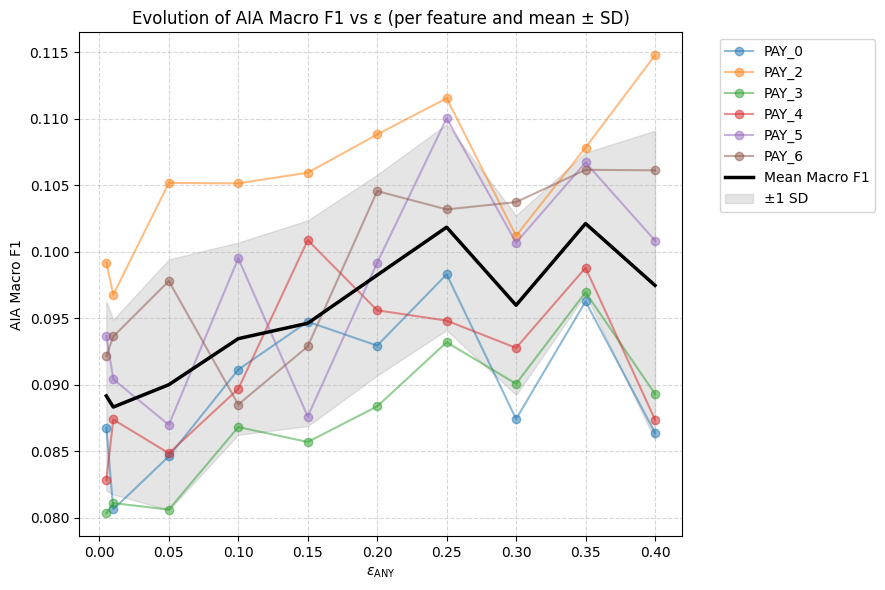

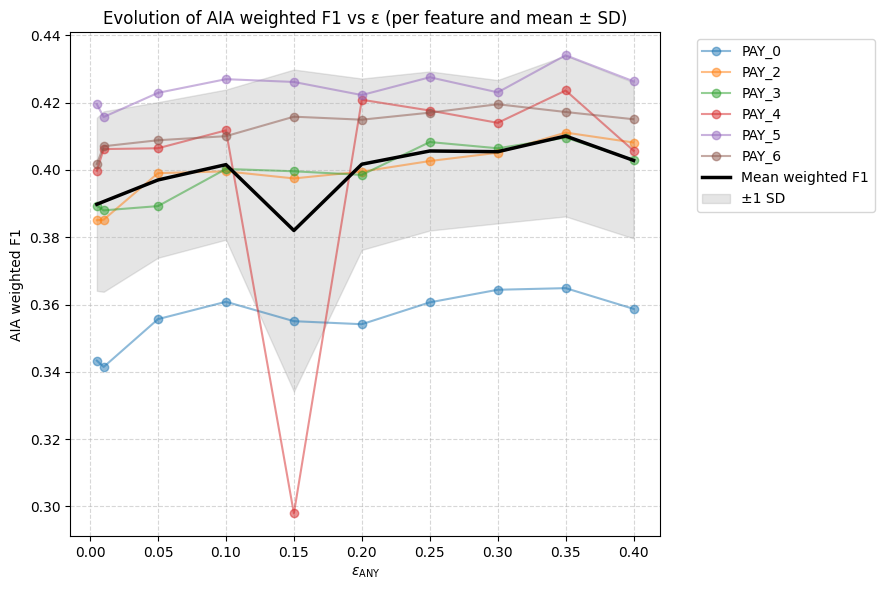

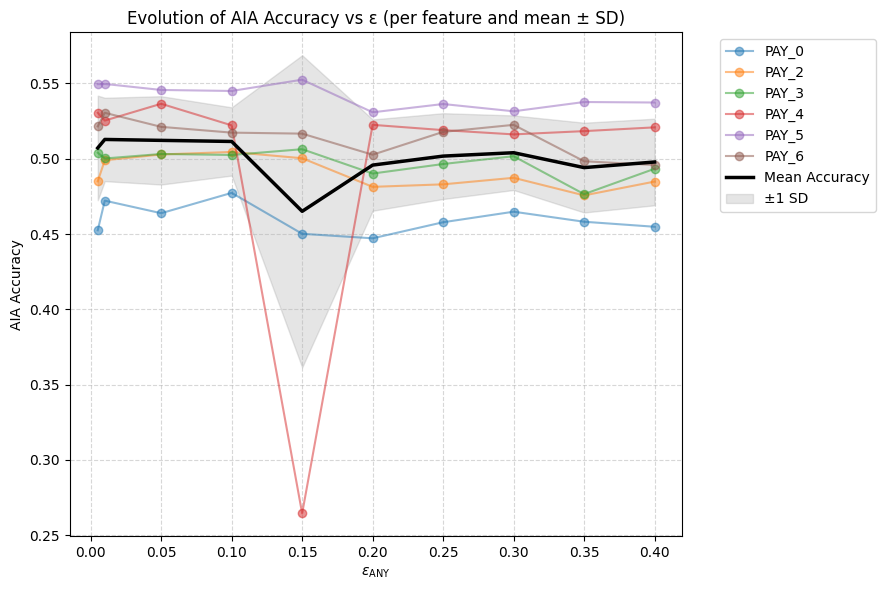

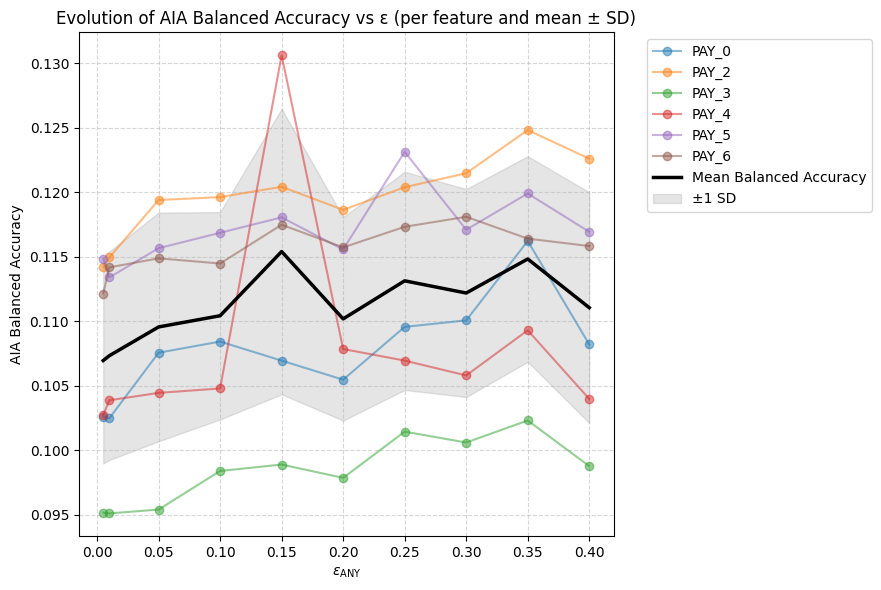

In [30]:
plot_classification_results(result_classification_credit_ctgan, 'Macro F1')
plot_classification_results(result_classification_credit_ctgan, 'weighted F1')
plot_classification_results(result_classification_credit_ctgan, 'Accuracy')
plot_classification_results(result_classification_credit_ctgan, 'Balanced Accuracy')

##### Credit Card Tvae

In [35]:
result_classification_credit_tvae = result_classification(predictions_aia_credit_tvae_, df_real_credit_card_test,['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'])

In [36]:
result_regression_credit_tvae = result_regression(predictions_aia_credit_tvae_, df_real_credit_card_test, ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'])

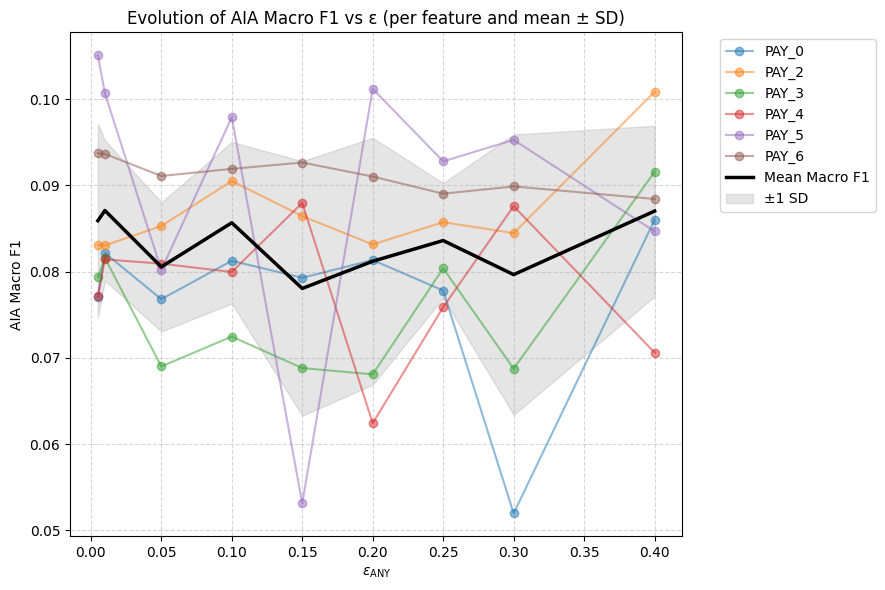

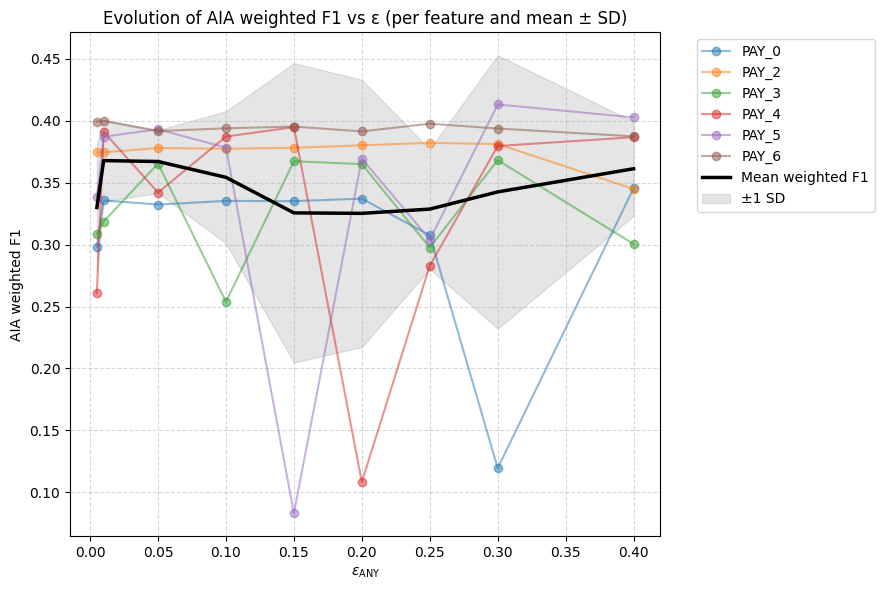

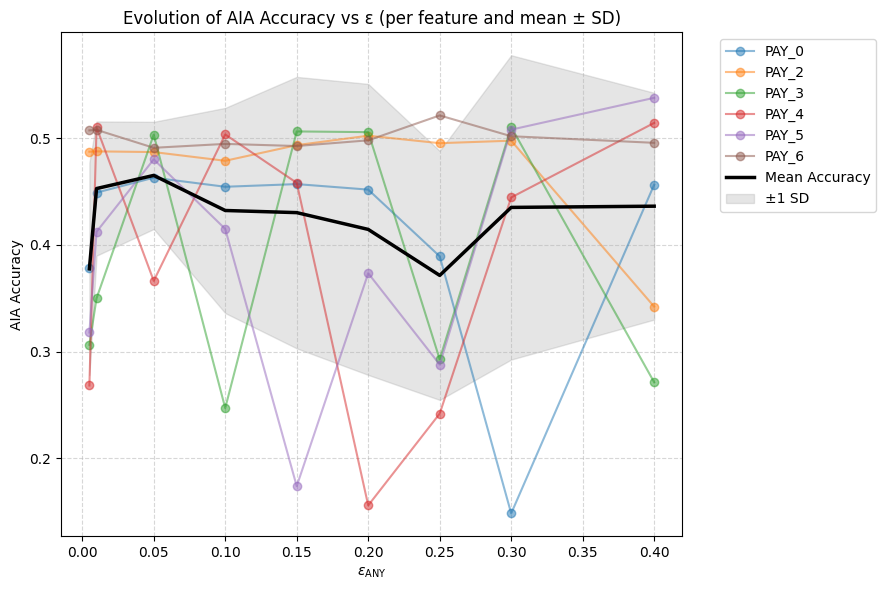

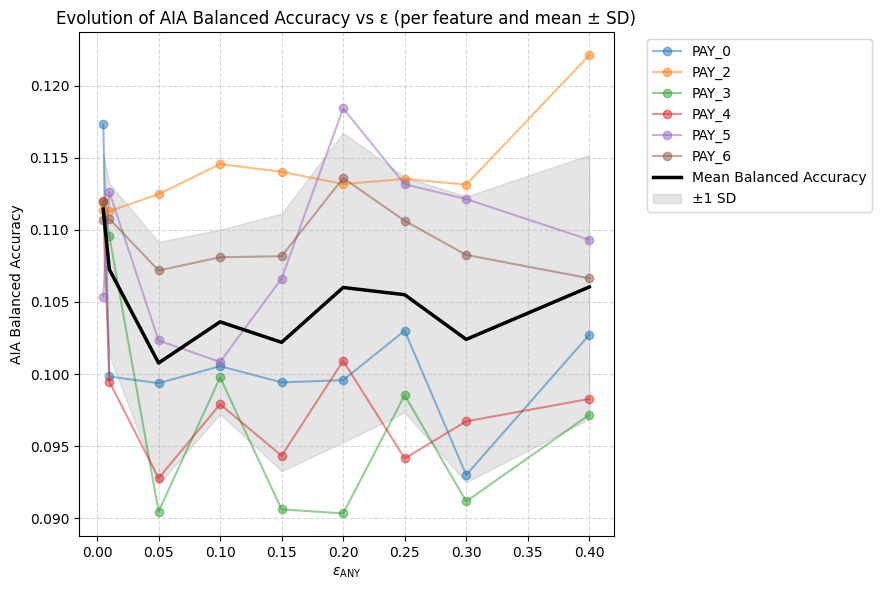

In [32]:
plot_classification_results(result_classification_credit_tvae, 'Macro F1')
plot_classification_results(result_classification_credit_tvae, 'weighted F1')
plot_classification_results(result_classification_credit_tvae, 'Accuracy')
plot_classification_results(result_classification_credit_tvae, 'Balanced Accuracy')

##### Adult Ctgan

In [37]:
cat_risk = [column for column in adult_risk_column if column in cat_list_adult]
result_classification_adult_ctgan = result_classification(predictions_aia_adult_ctgan, df_real_adult_test,cat_risk)

In [38]:
num_risk = [column for column in adult_risk_column if column in num_list_adult]
result_regression_adult_ctgan = result_regression(predictions_aia_adult_ctgan, df_real_adult_test,num_risk)

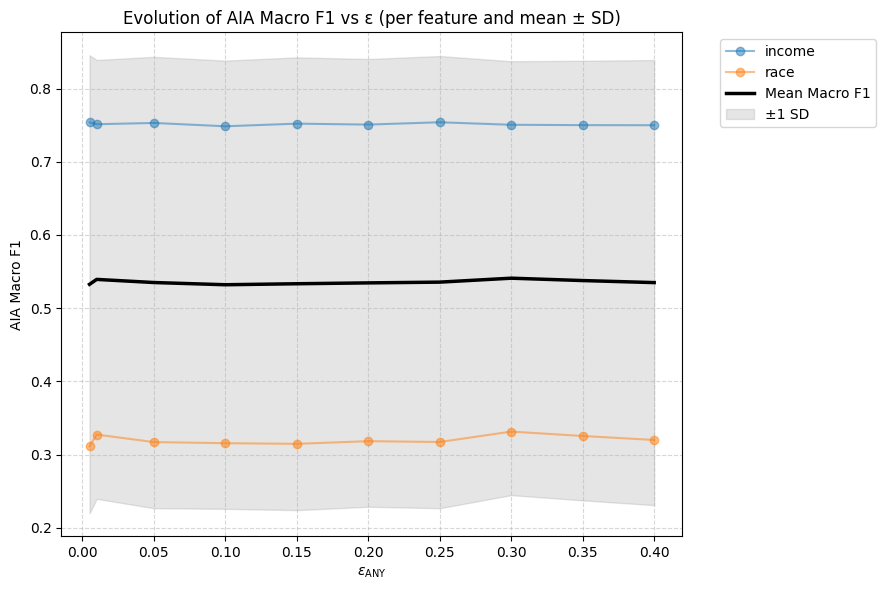

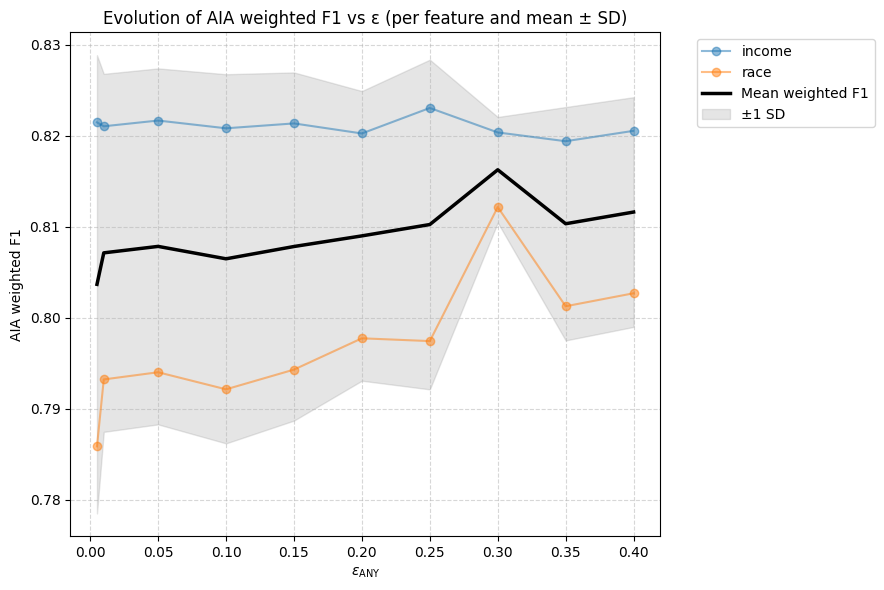

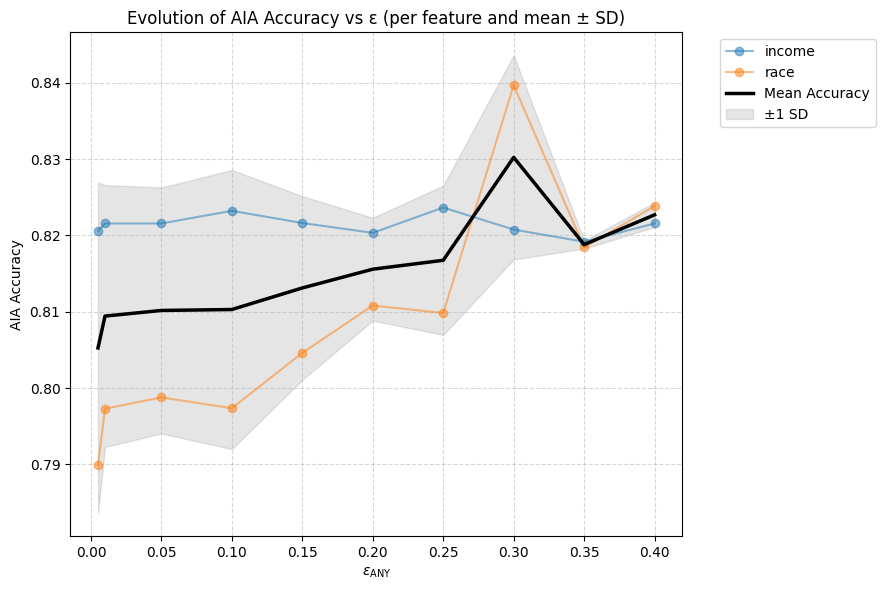

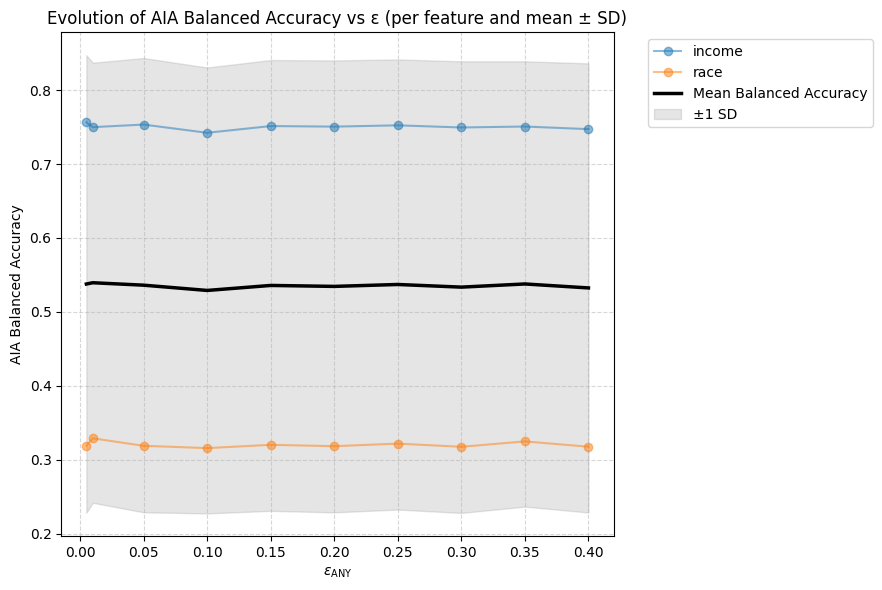

In [34]:
plot_classification_results(result_classification_adult_ctgan, 'Macro F1')
plot_classification_results(result_classification_adult_ctgan, 'weighted F1')
plot_classification_results(result_classification_adult_ctgan, 'Accuracy')
plot_classification_results(result_classification_adult_ctgan, 'Balanced Accuracy')

##### Adult Tvae

In [39]:
cat_risk = [column for column in adult_risk_column if column in cat_list_adult]
result_classification_adult_tvae = result_classification(predictions_aia_adult_tvae, df_real_adult_test,cat_risk)

In [40]:
num_risk = [column for column in adult_risk_column if column in num_list_adult]
result_regression_adult_tvae =result_regression(predictions_aia_adult_tvae, df_real_adult_test,num_risk)

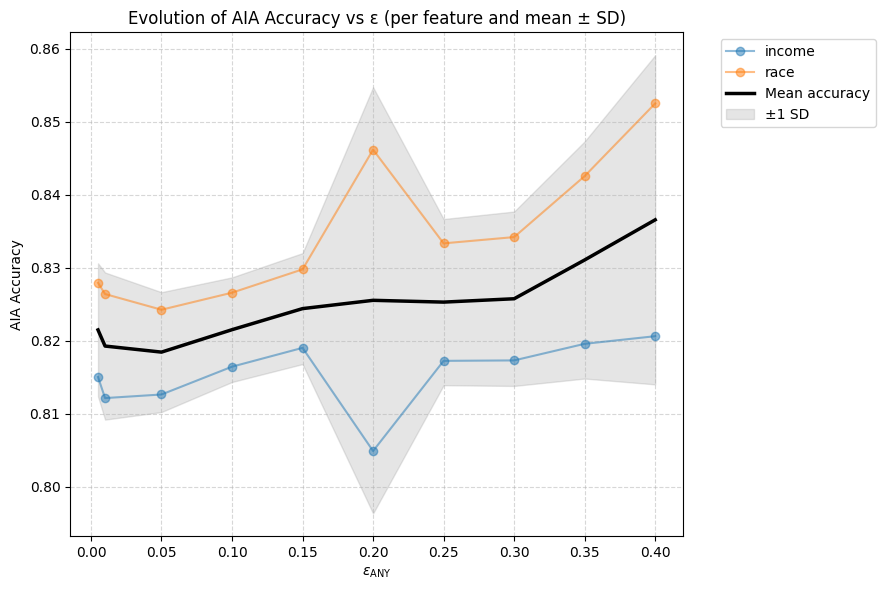

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Paste your dictionary here ----
# results = {
#     # ... your full nested dictionary ...
# }

# ---- Extract accuracy per epsilon ----
records = []
for eps, feats in results.items():
    for feat, metrics in feats.items():
        acc = metrics["Accuracy"]
        records.append({"epsilon": eps, "feature": feat, "accuracy": acc})

df = pd.DataFrame(records)

# Remove non-numeric epsilon (like 'Real' or 'None') for the curve plot
def to_float(x):
    try:
        return float(x)
    except:
        return np.nan

df["eps_value"] = df["epsilon"].apply(to_float)
df_numeric = df.dropna(subset=["eps_value"])

# Compute mean and std across features per epsilon
summary = (
    df_numeric.groupby("eps_value")["accuracy"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("eps_value")
)

# ---- Plot ----
plt.figure(figsize=(9,6))

# 1️⃣  Per-feature accuracy curves
for feat in df_numeric["feature"].unique():
    sub = df_numeric[df_numeric["feature"] == feat].sort_values("eps_value")
    plt.plot(sub["eps_value"], sub["accuracy"], marker='o', alpha=0.5, label=feat)

# 2️⃣  Mean ± std envelope
plt.plot(summary["eps_value"], summary["mean"], color='black', linewidth=2.5, label="Mean accuracy")
plt.fill_between(
    summary["eps_value"],
    summary["mean"] - summary["std"],
    summary["mean"] + summary["std"],
    color='gray', alpha=0.2, label="±1 SD"
)

# 3️⃣  Formatting
plt.xlabel(r"$\varepsilon_{\mathrm{ANY}}$")
plt.ylabel("AIA Accuracy")
plt.title("Evolution of AIA Accuracy vs ε (per feature and mean ± SD)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


##### Cardio Ctgan

In [41]:
cat_risk = [column for column in cardio_risk_column if column in cat_list_cardio]
result_classification_cardio_ctgan = result_classification(predictions_aia_cardio_ctgan, df_real_cardio_test,cat_risk)

In [42]:
num_risk = [column for column in cardio_risk_column if column in num_list_cardio]
result_regression_cardio_ctgan = result_regression(predictions_aia_cardio_ctgan, df_real_cardio_test,num_risk)

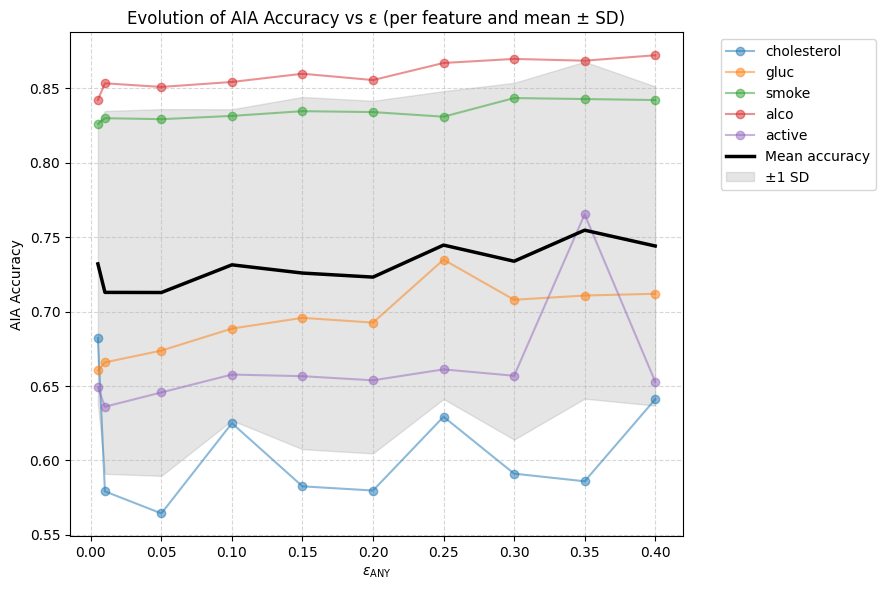

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Paste your dictionary here ----
# results = {
#     # ... your full nested dictionary ...
# }

# ---- Extract accuracy per epsilon ----
records = []
for eps, feats in results.items():
    for feat, metrics in feats.items():
        acc = metrics["Accuracy"]
        records.append({"epsilon": eps, "feature": feat, "accuracy": acc})

df = pd.DataFrame(records)

# Remove non-numeric epsilon (like 'Real' or 'None') for the curve plot
def to_float(x):
    try:
        return float(x)
    except:
        return np.nan

df["eps_value"] = df["epsilon"].apply(to_float)
df_numeric = df.dropna(subset=["eps_value"])

# Compute mean and std across features per epsilon
summary = (
    df_numeric.groupby("eps_value")["accuracy"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("eps_value")
)

# ---- Plot ----
plt.figure(figsize=(9,6))

# 1️⃣  Per-feature accuracy curves
for feat in df_numeric["feature"].unique():
    sub = df_numeric[df_numeric["feature"] == feat].sort_values("eps_value")
    plt.plot(sub["eps_value"], sub["accuracy"], marker='o', alpha=0.5, label=feat)

# 2️⃣  Mean ± std envelope
plt.plot(summary["eps_value"], summary["mean"], color='black', linewidth=2.5, label="Mean accuracy")
plt.fill_between(
    summary["eps_value"],
    summary["mean"] - summary["std"],
    summary["mean"] + summary["std"],
    color='gray', alpha=0.2, label="±1 SD"
)

# 3️⃣  Formatting
plt.xlabel(r"$\varepsilon_{\mathrm{ANY}}$")
plt.ylabel("AIA Accuracy")
plt.title("Evolution of AIA Accuracy vs ε (per feature and mean ± SD)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


##### Cardio Tvae

In [43]:
cat_risk = [column for column in cardio_risk_column if column in cat_list_cardio]
result_classification_cardio_tvae = result_classification(predictions_aia_cardio_tvae, df_real_cardio_test,cat_risk)

In [44]:
num_risk = [column for column in cardio_risk_column if column in num_list_cardio]
result_regression_cardio_tvae = result_regression(predictions_aia_cardio_tvae, df_real_cardio_test,num_risk)

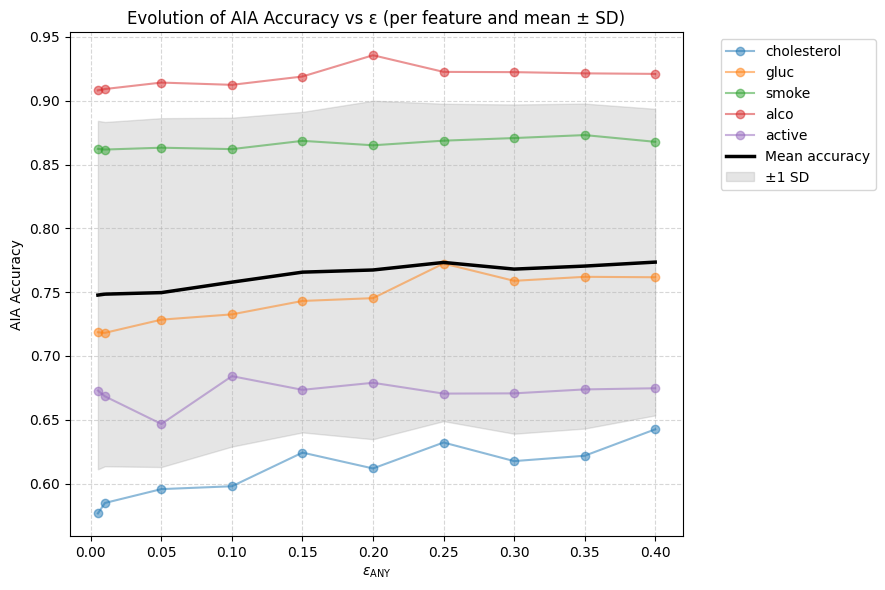

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Paste your dictionary here ----
# results = {
#     # ... your full nested dictionary ...
# }

# ---- Extract accuracy per epsilon ----
records = []
for eps, feats in results.items():
    for feat, metrics in feats.items():
        acc = metrics["Accuracy"]
        records.append({"epsilon": eps, "feature": feat, "accuracy": acc})

df = pd.DataFrame(records)

# Remove non-numeric epsilon (like 'Real' or 'None') for the curve plot
def to_float(x):
    try:
        return float(x)
    except:
        return np.nan

df["eps_value"] = df["epsilon"].apply(to_float)
df_numeric = df.dropna(subset=["eps_value"])

# Compute mean and std across features per epsilon
summary = (
    df_numeric.groupby("eps_value")["accuracy"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("eps_value")
)

# ---- Plot ----
plt.figure(figsize=(9,6))

# 1️⃣  Per-feature accuracy curves
for feat in df_numeric["feature"].unique():
    sub = df_numeric[df_numeric["feature"] == feat].sort_values("eps_value")
    plt.plot(sub["eps_value"], sub["accuracy"], marker='o', alpha=0.5, label=feat)

# 2️⃣  Mean ± std envelope
plt.plot(summary["eps_value"], summary["mean"], color='black', linewidth=2.5, label="Mean accuracy")
plt.fill_between(
    summary["eps_value"],
    summary["mean"] - summary["std"],
    summary["mean"] + summary["std"],
    color='gray', alpha=0.2, label="±1 SD"
)

# 3️⃣  Formatting
plt.xlabel(r"$\varepsilon_{\mathrm{ANY}}$")
plt.ylabel("AIA Accuracy")
plt.title("Evolution of AIA Accuracy vs ε (per feature and mean ± SD)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [85]:
aia_classification = {
    'credit ctgan' : result_classification_credit_ctgan,
    'credit tvae' : result_classification_credit_ctgan,
    'adult ctgan' : result_classification_adult_ctgan,
    'adult tvae' : result_classification_adult_ctgan,
    'cardio ctgan' : result_classification_cardio_ctgan,
    'cardio tvae' : result_classification_cardio_ctgan}
aia_classification

{'credit ctgan': {'Real': {'PAY_0': {'Accuracy': 0.49183333333333334,
    'weighted F1': 0.36062141433623623,
    'weighted recall': 0.49183333333333334,
    'weighted precision': 0.34988472482673616},
   'PAY_2': {'Accuracy': 0.5243333333333333,
    'weighted F1': 0.4018758650299146,
    'weighted recall': 0.5243333333333333,
    'weighted precision': 0.42791718206177054},
   'PAY_3': {'Accuracy': 0.5195,
    'weighted F1': 0.39633770838243726,
    'weighted recall': 0.5195,
    'weighted precision': 0.419678431809409},
   'PAY_4': {'Accuracy': 0.5358333333333334,
    'weighted F1': 0.4075745109073402,
    'weighted recall': 0.5358333333333334,
    'weighted precision': 0.41085565725670686},
   'PAY_5': {'Accuracy': 0.553,
    'weighted F1': 0.4161333091431853,
    'weighted recall': 0.553,
    'weighted precision': 0.39580595386246054},
   'PAY_6': {'Accuracy': 0.5428333333333333,
    'weighted F1': 0.40097841034592513,
    'weighted recall': 0.5428333333333333,
    'weighted precisi

In [86]:
aia_regression = {
    'credit ctgan' : result_regression_credit_ctgan,
    'credit tvae' : result_regression_credit_ctgan,
    'adult ctgan' : result_regression_adult_ctgan,
    'adult tvae' : result_regression_adult_ctgan,
    'cardio ctgan' : result_regression_cardio_ctgan,
    'cardio tvae' : result_regression_cardio_ctgan}
aia_regression

{'credit ctgan': {'Real': {'BILL_AMT1': {'MSE': 5468560460.573229,
    'RMSE': 73949.71575721727,
    'R2': 0.01621769981496146},
   'BILL_AMT2': {'MSE': 5132743136.9349,
    'RMSE': 71643.16531906516,
    'R2': 0.014176928287188417},
   'BILL_AMT3': {'MSE': 4788066708.717484,
    'RMSE': 69195.85759796236,
    'R2': 0.013741929467227854},
   'BILL_AMT4': {'MSE': 4218445630.335808,
    'RMSE': 64949.562202803245,
    'R2': 0.012705184965194571},
   'BILL_AMT5': {'MSE': 3731757027.2485213,
    'RMSE': 61088.108722144294,
    'R2': 0.011221405321673594},
   'BILL_AMT6': {'MSE': 3635375526.4253736,
    'RMSE': 60294.07538411526,
    'R2': 0.010998306581029405},
   'PAY_AMT1': {'MSE': 203456265.01192343,
    'RMSE': 14263.809624778489,
    'R2': 0.0036720396670297806},
   'PAY_AMT2': {'MSE': 295229416.4768639,
    'RMSE': 17182.24131121618,
    'R2': 0.0009580589619399005},
   'PAY_AMT3': {'MSE': 216796366.74174085,
    'RMSE': 14724.006477237806,
    'R2': 0.009317925335824206},
   'PAY_A

#### Wanna be Utility

In [27]:
# -*- coding: utf-8 -*-
"""
AIA (Attribute Inference Attack) comparative tables & plots
===========================================================

This script expects two dicts already defined in the session:

- `clf_results`: nested dict for *classification* AIA results
- `reg_results`: nested dict for *regression* AIA results

Structure:
    results[dataset_label][target][metric] = value

Dataset labels:
- "Real"  -> train on real QIs, evaluate on real test (baseline risk).
- "None"  -> synthetic with **no** HEOM–kNN post-processing filter.
- "0.4", "0.35", ... -> numeric strings: ε_ANY targets (use as floats).

What the script does
--------------------
1) Parse & tidy results into long DataFrames.
2) Build per-task aggregate tables (mean ± std across targets).
3) Compute privacy-gain deltas vs Real baseline (mean across targets).
4) Plot metric trends vs ε_ANY (numeric variants only) with ±1 std bands
   and baseline markers for Real/None.
5) Heatmaps (bonus): privacy gain for weighted F1 (classification) and
   RMSE (regression).
6) Save CSVs and PNGs; pretty-print key tables and a short textual summary.

Notes
-----
- Matplotlib only (no seaborn).
- Robust to missing metrics/targets (skips where needed).
- Metric-direction conventions:
  * Classification (Accuracy, weighted F1/recall/precision): HIGHER = stronger attack
    -> privacy_gain = Real - Synthetic  (↑ is safer).
  * Regression (MSE, RMSE): LOWER = stronger attack
    -> privacy_gain = Synthetic - Real  (↑ is safer).
  * Regression (R2): HIGHER = stronger attack
    -> privacy_gain = Real - Synthetic  (↑ is safer).

Outputs
-------
CSV:
- aia_classification_aggregate.csv
- aia_regression_aggregate.csv
- aia_classification_privacy_gain.csv
- aia_regression_privacy_gain.csv

PNG:
- aia_cls_<metric>_vs_epsilon.png   (4 files)
- aia_reg_<metric>_vs_epsilon.png   (3 files)
- aia_cls_privacy_gain_wF1_heatmap.png
- aia_reg_privacy_gain_RMSE_heatmap.png
"""

from __future__ import annotations

import math
import warnings
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------- Configuration ----------

# Mapping for sanitized metric names (valid identifiers for files/columns)
SANITIZE_MAP = {
    "weighted F1": "F1_w",
    "weighted recall": "Recall_w",
    "weighted precision": "Precision_w",
}

# Which metrics are "higher = stronger attack"
HIGHER_STRONGER = {"Accuracy", "weighted F1", "weighted recall", "weighted precision", "R2"}
# Which metrics are "lower = stronger attack"
LOWER_STRONGER = {"MSE", "RMSE"}


# ---------- Utilities ----------

def _try_float(x: str) -> float | float("nan"):
    """Return float(x) if possible, else NaN."""
    try:
        return float(x)
    except Exception:
        return float("nan")


def sanitize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Sanitize column names using SANITIZE_MAP and make underscore-safe.
    Keeps 'dataset_label' and 'epsilon' untouched.
    """
    new_cols = {}
    for c in df.columns:
        new = c
        for k, v in SANITIZE_MAP.items():
            new = new.replace(k, v)
        new = new.replace(" ", "_")
        new_cols[c] = new
    return df.rename(columns=new_cols)


# ---------- 1) Parsing & tidying ----------

def flatten_results_to_long(results: Dict, task: str) -> pd.DataFrame:
    """
    Flatten nested results dict to a tidy long DataFrame.

    Columns:
        dataset_label (str)
        epsilon (float or NaN for "Real"/"None")
        task ("classification"|"regression")
        target (str)
        metric (str)
        value (float)
    """
    rows: List[Dict] = []
    for ds_label, target_dict in results.items():
        eps = _try_float(ds_label)
        for target, metric_dict in target_dict.items():
            for metric, val in metric_dict.items():
                try:
                    fv = float(val)
                except Exception:
                    warnings.warn(f"Non-numeric value for {task} [{ds_label} / {target} / {metric}] -> {val}; skipping.")
                    continue
                rows.append(
                    {
                        "dataset_label": str(ds_label),
                        "epsilon": eps,
                        "task": task,
                        "target": str(target),
                        "metric": str(metric),
                        "value": fv,
                    }
                )
    df = pd.DataFrame(rows)
    # Keep display order: Real, None, then numeric ascending
    # (We keep epsilon as float for plotting and sort later when needed.)
    return df


# ---------- 2) Aggregation tables ----------

def _order_datasets(df: pd.DataFrame) -> pd.DataFrame:
    """Order rows as Real, None, then numeric eps ascending."""
    def key(row):
        label = row["dataset_label"]
        eps = row.get("epsilon", np.nan)
        if label == "Real":
            return (0, -np.inf)
        if label == "None":
            return (1, -np.inf)
        return (2, eps if pd.notna(eps) else np.inf)

    out = df.copy()
    out["_sortkey"] = out.apply(key, axis=1)
    out = out.sort_values("_sortkey").drop(columns="_sortkey").reset_index(drop=True)
    return out


def aggregate_by_dataset(df_long: pd.DataFrame) -> pd.DataFrame:
    """
    Per-task, aggregated by dataset (mean ± std across targets).

    Returns:
        Wide DataFrame with columns:
            dataset_label, epsilon, <metric>_mean, <metric>_std
        Ordered: Real, None, sorted numeric eps.
    """
    if df_long.empty:
        return pd.DataFrame(columns=["dataset_label", "epsilon"])

    grp = (
        df_long.groupby(["dataset_label", "epsilon", "metric"], dropna=False)["value"]
        .agg(["mean", "std"])
        .reset_index()
    )

    wide_mean = grp.pivot(index=["dataset_label", "epsilon"], columns="metric", values="mean")
    wide_std = grp.pivot(index=["dataset_label", "epsilon"], columns="metric", values="std")

    wide = pd.concat([wide_mean.add_suffix("_mean"), wide_std.add_suffix("_std")], axis=1).reset_index()
    # Sort metrics lexicographically for stable column order
    metric_cols = sorted([c for c in wide.columns if c not in ("dataset_label", "epsilon")])
    wide = wide[["dataset_label", "epsilon"] + metric_cols]

    # wide = _order_datasets(wide)
    return wide


# ---------- 3) Privacy gains vs Real ----------

def _privacy_gain(real_val: float, synth_val: float, metric: str) -> float:
    """Compute privacy gain vs Real for a single (target, metric) pair."""
    if metric in HIGHER_STRONGER:
        # Higher means stronger attack; lower is safer -> Real - Synthetic
        return real_val - synth_val
    elif metric in LOWER_STRONGER:
        # Lower means stronger attack; higher is safer -> Synthetic - Real
        return synth_val - real_val
    # Default: treat as higher = stronger
    return real_val - synth_val


def compute_privacy_gains(df_long: pd.DataFrame, task: str) -> pd.DataFrame:
    """
    Compute privacy gains vs Real baseline.

    For each (dataset_label, epsilon, metric):
        privacy_gain = mean over targets of per-target gain
        pct_gain     = privacy_gain / max(|Real|, 1e-12)

    Returns:
        Wide DataFrame: columns include `privacy_gain_<metric>` and `pct_gain_<metric>`
        Ordered: Real, None, sorted numeric eps.
    """
    if df_long.empty:
        return pd.DataFrame(columns=["dataset_label", "epsilon"])

    # Real baseline per (target, metric)
    real = (
        df_long[df_long["dataset_label"] == "Real"][["target", "metric", "value"]]
        .rename(columns={"value": "real_value"})
    )

    merged = df_long.merge(real, on=["target", "metric"], how="left", validate="many_to_one")

    def gain_row(row) -> Tuple[float, float]:
        r = row["real_value"]
        v = row["value"]
        m = row["metric"]
        if pd.isna(r) or pd.isna(v):
            return np.nan, np.nan
        pg = _privacy_gain(r, v, m)
        denom = abs(r) if abs(r) > 1e-12 else 1e-12
        return pg, pg / denom

    merged[["privacy_gain", "pct_gain"]] = merged.apply(
        lambda r: pd.Series(gain_row(r)), axis=1
    )

    agg = (
        merged.groupby(["dataset_label", "epsilon", "metric"], dropna=False)[["privacy_gain", "pct_gain"]]
        .mean()
        .reset_index()
    )

    gain_wide = agg.pivot(index=["dataset_label", "epsilon"], columns="metric", values="privacy_gain").add_prefix("privacy_gain_")
    pct_wide = agg.pivot(index=["dataset_label", "epsilon"], columns="metric", values="pct_gain").add_prefix("pct_gain_")

    wide = pd.concat([gain_wide, pct_wide], axis=1).reset_index()

    # Stable column order
    metric_cols = sorted([c for c in wide.columns if c not in ("dataset_label", "epsilon")])
    wide = wide[["dataset_label", "epsilon"] + metric_cols]

    wide = _order_datasets(wide)
    return wide


# ---------- 4) Plotting ----------

def _safe_metric_series(df_long: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Return numeric-epsilon subset for a single metric with mean±std across targets."""
    sub = df_long[(df_long["metric"] == metric) & (~df_long["epsilon"].isna())].copy()
    if sub.empty:
        return sub
    agg = (
        sub.groupby(["epsilon"])["value"]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values("epsilon")
        .reset_index(drop=True)
    )
    return agg


def plot_metric_trend(
    df_long: pd.DataFrame,
    task: str,
    metric: str,
    real_df: Optional[pd.DataFrame] = None,
    none_df: Optional[pd.DataFrame] = None,
    outfile: Optional[str] = None,
) -> None:
    """
    Plot metric vs ε_ANY (numeric datasets only), with ±1 std band.
    Add baseline markers/labels for 'Real' and 'None' at the left margin.

    Saves to `outfile` if provided.
    """
    agg = _safe_metric_series(df_long, metric)
    if agg.empty:
        warnings.warn(f"No data to plot for {task} metric '{metric}'. Skipping.")
        return

    # Baselines (mean across targets for Real/None)
    def baseline_mean(ds_label: str) -> Optional[float]:
        sub = df_long[(df_long["dataset_label"] == ds_label) & (df_long["metric"] == metric)]
        return None if sub.empty else sub["value"].mean()

    real_mean = baseline_mean("Real")
    none_mean = baseline_mean("None")

    # Figure
    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    # Line with ±1 std band
    ax.plot(agg["epsilon"], agg["mean"], label=f"{metric} (mean)")
    ax.fill_between(agg["epsilon"], agg["mean"] - agg["std"], agg["mean"] + agg["std"], alpha=0.2, label="±1 std")

    # X range & left margin for markers
    xmin, xmax = float(agg["epsilon"].min()), float(agg["epsilon"].max())
    xpad = (xmax - xmin) * 0.08 if xmax > xmin else 0.05
    ax.set_xlim(xmin - xpad, xmax)

    # Baseline horizontal lines and left-margin point markers
    if real_mean is not None:
        ax.axhline(real_mean, linestyle="--", linewidth=1, label="Real baseline")
        ax.scatter([xmin - xpad * 0.6], [real_mean], marker="o")
        ax.text(xmin - xpad * 0.55, real_mean, " Real", va="center", ha="left", fontsize=9)
    if none_mean is not None:
        ax.axhline(none_mean, linestyle=":", linewidth=1, label="None baseline")
        ax.scatter([xmin - xpad * 0.6], [none_mean], marker="s")
        ax.text(xmin - xpad * 0.55, none_mean, " None", va="center", ha="left", fontsize=9)

    # Titles and labels
    task_title = "Classification" if task == "classification" else "Regression"
    ax.set_title(f"AIA {task_title} — {metric} vs ε_ANY (mean ± 1 std)")
    ax.set_xlabel("ε_ANY (privacy target)")
    ax.set_ylabel(metric)
    ax.legend(loc="best")
    ax.grid(True, axis="y", linewidth=0.4, alpha=0.5)

    if outfile:
        plt.tight_layout()
        plt.savefig(outfile, dpi=150)
    plt.close()


def plot_privacy_gain_heatmap(
    gain_df: pd.DataFrame,
    metric_display: str,
    task: str,
    outfile: str,
) -> None:
    """
    Heatmap of privacy_gain for a single metric across dataset variants (rows).

    Args:
        gain_df: output of compute_privacy_gains(...) already ordered with Real/None first.
        metric_display: e.g., "weighted F1" (classification) or "RMSE" (regression).
        task: "classification" or "regression"
        outfile: PNG path
    """
    col = f"privacy_gain_{metric_display}"
    if col not in gain_df.columns:
        warnings.warn(f"Column '{col}' not found in privacy gain table; skipping heatmap.")
        return

    vals = gain_df[col].to_numpy().reshape(-1, 1)
    labels = gain_df["dataset_label"].astype(str).tolist()

    plt.figure(figsize=(4, max(2.5, 0.35 * len(labels))))
    ax = plt.gca()
    im = ax.imshow(vals, aspect="auto")
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xticks([0])
    ax.set_xticklabels([f"privacy_gain_{metric_display}"])
    plt.colorbar(im, fraction=0.046, pad=0.04)

    # Annotate each cell
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            txt = "NA" if pd.isna(v) else f"{v:.4f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9)

    ax.set_title(f"AIA {('Classification' if task=='classification' else 'Regression')} — Privacy gain heatmap")
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.close()


# ---------- 5) End-to-end ----------

def result_aia(clf_results: Dict, reg_results: Dict) -> None:
    # Pandas print options
    pd.set_option("display.max_columns", 100)
    pd.set_option("display.width", 160)

    # 1) Tidy
    clf_long = flatten_results_to_long(clf_results, "classification")
    reg_long = flatten_results_to_long(reg_results, "regression")

    # 2) Aggregate tables
    clf_agg = aggregate_by_dataset(clf_long)
    reg_agg = aggregate_by_dataset(reg_long)

    # 3) Privacy gains vs Real
    clf_gain = compute_privacy_gains(clf_long, "classification")
    reg_gain = compute_privacy_gains(reg_long, "regression")

    # Save CSVs (sanitized columns)
    sanitize_columns(clf_agg).to_csv("aia_classification_aggregate.csv", index=False)
    sanitize_columns(reg_agg).to_csv("aia_regression_aggregate.csv", index=False)
    sanitize_columns(clf_gain).to_csv("aia_classification_privacy_gain.csv", index=False)
    sanitize_columns(reg_gain).to_csv("aia_regression_privacy_gain.csv", index=False)

    # 4) Plots
    # Classification metrics
    cls_metrics = [m for m in ["Accuracy", "weighted F1", "weighted recall", "weighted precision"]
                   if (clf_long["metric"] == m).any()]

    for m in cls_metrics:
        m_safe = SANITIZE_MAP.get(m, m).replace(" ", "_")
        plot_metric_trend(
            df_long=clf_long,
            task="classification",
            metric=m,
            outfile=f"aia_cls_{m_safe}_vs_epsilon.png",
        )

    # Regression metrics
    reg_metrics = [m for m in ["MSE", "RMSE", "R2"] if (reg_long["metric"] == m).any()]
    for m in reg_metrics:
        m_safe = SANITIZE_MAP.get(m, m).replace(" ", "_")
        plot_metric_trend(
            df_long=reg_long,
            task="regression",
            metric=m,
            outfile=f"aia_reg_{m_safe}_vs_epsilon.png",
        )

    # Heatmaps (bonus)
    plot_privacy_gain_heatmap(clf_gain, metric_display="weighted F1", task="classification",
                              outfile="aia_cls_privacy_gain_wF1_heatmap.png")
    plot_privacy_gain_heatmap(reg_gain, metric_display="RMSE", task="regression",
                              outfile="aia_reg_privacy_gain_RMSE_heatmap.png")

    # 6) Pretty-print tables to console
    print("\n=== Classification aggregate (mean ± std across targets) ===")
    print(clf_agg.round(6).to_string(index=False))

    print("\n=== Regression aggregate (mean ± std across targets) ===")
    print(reg_agg.round(6).to_string(index=False))

    print("\n=== Classification — privacy gain vs Real (mean across targets) ===")
    print(clf_gain.round(6).to_string(index=False))

    print("\n=== Regression — privacy gain vs Real (mean across targets) ===")
    print(reg_gain.round(6).to_string(index=False))

    # 8) Short textual summary
    # Weighted F1: best (max) privacy gain among numeric eps
    if "privacy_gain_weighted F1" in clf_gain.columns:
        numeric_cls = clf_gain[~clf_gain["epsilon"].isna()]
        best_cls_idx = numeric_cls["privacy_gain_weighted F1"].idxmax()
        best_cls_row = numeric_cls.loc[best_cls_idx]
        best_cls_eps = best_cls_row["epsilon"]
        best_cls_gain = best_cls_row["privacy_gain_weighted F1"]
        none_cls_gain = clf_gain.loc[clf_gain["dataset_label"]=="None", "privacy_gain_weighted F1"].values
        none_cls_gain = none_cls_gain[0] if len(none_cls_gain) else np.nan
    else:
        best_cls_eps = np.nan
        best_cls_gain = np.nan
        none_cls_gain = np.nan

    # RMSE: best (max) privacy gain among numeric eps
    if "privacy_gain_RMSE" in reg_gain.columns:
        numeric_reg = reg_gain[~reg_gain["epsilon"].isna()]
        best_reg_idx = numeric_reg["privacy_gain_RMSE"].idxmax()
        best_reg_row = numeric_reg.loc[best_reg_idx]
        best_reg_eps = best_reg_row["epsilon"]
        best_reg_gain = best_reg_row["privacy_gain_RMSE"]
        none_reg_gain = reg_gain.loc[reg_gain["dataset_label"]=="None", "privacy_gain_RMSE"].values
        none_reg_gain = none_reg_gain[0] if len(none_reg_gain) else np.nan
    else:
        best_reg_eps = np.nan
        best_reg_gain = np.nan
        none_reg_gain = np.nan

    # Summary bullets
    print("\n--- Summary ---")
    print("* Which ε_ANY settings reduce AIA the most:")
    print(f"  - Classification (weighted F1): ε_ANY = {best_cls_eps} with privacy gain {best_cls_gain:.6f} "
          f"(↑ is safer; negative means slightly stronger attack than Real).")
    print(f"  - Regression (RMSE): ε_ANY = {best_reg_eps} with privacy gain {best_reg_gain:.6f} (↑ is safer).")
    print("* 'None' vs best filtered vs Real:")
    print(f"  - Classification (weighted F1): 'None' gain = {none_cls_gain:.6f}; "
          f"best filtered improves over 'None' by {(best_cls_gain - none_cls_gain):.6f}.")
    print(f"  - Regression (RMSE): 'None' gain = {none_reg_gain:.6f}; "
          f"best filtered improves over 'None' by {(best_reg_gain - none_reg_gain):.6f}; "
          f"Real baseline is 0.000000.")


In [28]:
result_class = result_classification(predictions_aia_credit_ctgan_, df_real_credit_card_test,['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'])
result_reg = result_regression(predictions_aia_credit_ctgan_, df_real_credit_card_test, ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'])

In [29]:
result_aia(result_class, result_reg)


=== Classification aggregate (mean ± std across targets) ===
dataset_label  epsilon  Accuracy_mean  Accuracy_std  weighted F1_mean  weighted F1_std  weighted precision_mean  weighted precision_std  weighted recall_mean  weighted recall_std
        0.005    0.005       0.507167      0.034733          0.389795         0.025718                 0.376550                0.030987              0.507167             0.034733
         0.01    0.010       0.512806      0.027679          0.390599         0.026822                 0.384199                0.034135              0.512806             0.027679
         0.05    0.050       0.512194      0.029324          0.397019         0.023125                 0.389672                0.028143              0.512194             0.029324
          0.1    0.100       0.511472      0.022660          0.401574         0.022305                 0.389029                0.023076              0.511472             0.022660
         0.15    0.150       0.465083      

In [30]:
clf_long = flatten_results_to_long(result_class, "classification")
reg_long = flatten_results_to_long(result_reg, "regression")

# 2) Aggregate tables
clf_agg = aggregate_by_dataset(clf_long)
reg_agg = aggregate_by_dataset(reg_long)

In [ ]:

from __future__ import annotations

import math
import warnings
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ----------------------------- Helpers & parsing -----------------------------

HIGHER_STRONGER = {"Accuracy", "weighted F1", "weighted recall", "weighted precision", "R2"}
LOWER_STRONGER = {"MSE", "RMSE"}

# pretty names for figure titles / ylabels (optional)
DISPLAY_NAME = {
    "weighted F1": "Weighted F1",
    "weighted recall": "Weighted Recall",
    "weighted precision": "Weighted Precision",
    "Accuracy": "Accuracy",
    "MSE": "MSE",
    "RMSE": "RMSE",
    "R2": "R²",
}

# order of epsilons (desc ⇒ stricter on the right), with "None" first
def epsilon_order_from_keys(keys: List[str]) -> List[str]:
    numeric = []
    for k in keys:
        if k in {"Real", "None"}:
            continue
        try:
            numeric.append(float(k))
        except Exception:
            continue
    numeric = sorted(set(numeric), reverse=True)  # 0.4, 0.35, …, 0.005
    return ["None"] + [str(e) for e in numeric]

def flatten_results_to_long(results: Dict, task: str) -> pd.DataFrame:
    """
    results[variant][target][metric] = value  ->  long tidy DF
    Columns: dataset_label, epsilon(float|nan), task, target, metric, value
    """
    rows = []
    for ds_label, tgt_dict in results.items():
        try:
            eps = float(ds_label)
        except Exception:
            eps = np.nan
        for target, metr_dict in tgt_dict.items():
            for metric, val in metr_dict.items():
                try:
                    rows.append(
                        dict(
                            dataset_label=str(ds_label),
                            epsilon=eps,
                            task=task,
                            target=str(target),
                            metric=str(metric),
                            value=float(val),
                        )
                    )
                except Exception:
                    warnings.warn(f"Skipping non-numeric {task} value: {ds_label}/{target}/{metric}={val}")
    return pd.DataFrame(rows)

def _privacy_gain(real_val: float, synth_val: float, metric: str) -> float:
    if metric in HIGHER_STRONGER:
        return real_val - synth_val
    if metric in LOWER_STRONGER:
        return synth_val - real_val
    return real_val - synth_val

def per_target_series(
    df_long: pd.DataFrame,
    metric: str,
    order: List[str],
    include_real_baseline: bool = True,
) -> Tuple[List[str], np.ndarray, Optional[np.ndarray]]:
    """
    For a chosen metric, build per-target matrix over the ordered x categories.

    Returns:
        targets (list[str]),
        Y (n_targets x n_x) metric values for dataset labels in `order`
        Y_real (n_targets,) real baseline per target (or None)
    """
    dfm = df_long[df_long["metric"] == metric].copy()
    if dfm.empty:
        return [], np.empty((0, 0)), None

    targets = sorted(dfm["target"].unique().tolist())
    X_labels = order[:]  # categorical x labels, e.g. ["None", "0.4", ..., "0.005"]

    # matrix of values
    Y = np.full((len(targets), len(X_labels)), np.nan, dtype=float)
    Y_real = np.full((len(targets),), np.nan, dtype=float) if include_real_baseline else None

    # index for speed
    df_indexed = {(r.dataset_label, r.target): r.value for r in dfm.itertuples()}

    for i, t in enumerate(targets):
        # row for 'Real' (baseline)
        if include_real_baseline:
            rv = df_indexed.get(("Real", t), np.nan)
            Y_real[i] = rv

        # row across ordered x labels
        for j, lbl in enumerate(X_labels):
            v = df_indexed.get((lbl, t), np.nan)
            if isinstance(v, float) and (not math.isnan(v)):
                Y[i, j] = v

    return targets, Y, Y_real


def per_target_privacy_gain(
    df_long: pd.DataFrame,
    metric: str,
    order: List[str],
) -> Tuple[List[str], np.ndarray]:
    """
    Compute per-target privacy gain vs Real for each x label in `order`.

    Returns:
        targets, G (n_targets x n_x) where G[i, j] is privacy gain for target i at label j.
    """
    dfm = df_long[df_long["metric"] == metric].copy()
    if dfm.empty:
        return [], np.empty((0, 0))

    # real baseline per target
    real = dfm[dfm["dataset_label"] == "Real"][["target", "value"]].set_index("target")["value"]

    targets = sorted(dfm["target"].unique().tolist())
    X_labels = order[:]

    # index values for quick lookup
    df_indexed = {(r.dataset_label, r.target): r.value for r in dfm.itertuples()}

    G = np.full((len(targets), len(X_labels)), np.nan, dtype=float)
    for i, t in enumerate(targets):
        r = float(real.get(t, np.nan))
        for j, lbl in enumerate(X_labels):
            v = df_indexed.get((lbl, t), np.nan)
            if isinstance(v, float) and (not math.isnan(v)) and (not math.isnan(r)):
                G[i, j] = _privacy_gain(r, v, metric)
    return targets, G


# ----------------------------- Plotting utilities ----------------------------

def set_publication_rc():
    """Sober defaults suitable for papers (matplotlib only)."""
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "savefig.dpi": 300,
        "figure.dpi": 110,
    })


def _grid_dims(n: int, max_cols: int = 4) -> Tuple[int, int]:
    cols = min(max_cols, max(1, n))
    rows = int(math.ceil(n / cols))
    return rows, cols


def _shared_ylim(Y: np.ndarray, Y_real: Optional[np.ndarray] = None, pad_ratio: float = 0.06) -> Tuple[float, float]:
    vals = []
    if Y.size:
        vals.append(np.nanmin(Y))
        vals.append(np.nanmax(Y))
    if Y_real is not None and Y_real.size:
        vals.append(np.nanmin(Y_real))
        vals.append(np.nanmax(Y_real))
    lo, hi = (min(vals), max(vals)) if vals else (0.0, 1.0)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = lo - 0.01, hi + 0.01
    pad = (hi - lo) * pad_ratio
    return lo - pad, hi + pad


def _draw_supertitle_and_xlabel(fig, title: str, xlabel: str, note: str) -> None:
    fig.suptitle(title, y=0.99)
    fig.text(0.5, 0.02, xlabel, ha="center")
    if note:
        fig.text(0.5, 0.005, note, ha="center", va="bottom", fontsize=9)


def plot_per_target_lines(
    targets: List[str],
    X_labels: List[str],
    Y: np.ndarray,
    Y_real: Optional[np.ndarray],
    metric: str,
    out_base: str,
    yfmt: Optional[FuncFormatter] = None,
) -> None:
    """Per‑target small multiples line plots with Real baseline."""
    if len(targets) == 0:
        warnings.warn(f"No data to plot for metric {metric}.")
        return

    rows, cols = _grid_dims(len(targets), max_cols=4)
    fig_w, fig_h = 3.3 * cols, 2.7 * rows
    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h), constrained_layout=True)
    axes = np.array(axes).reshape(rows, cols)

    # y-limits shared across panels
    ymin, ymax = _shared_ylim(Y, Y_real)
    x = np.arange(len(X_labels))

    for idx, t in enumerate(targets):
        r, c = divmod(idx, cols)
        ax = axes[r, c]
        # main line
        ax.plot(x, Y[idx], marker="o", linewidth=1.8)
        # Real baseline
        if Y_real is not None and np.isfinite(Y_real[idx]):
            ax.axhline(Y_real[idx], linestyle="--", linewidth=1.0)
        # axes cosmetics
        ax.set_title(t, loc="left", pad=2)
        ax.set_ylim(ymin, ymax)
        if yfmt:
            ax.yaxis.set_major_formatter(yfmt)
        # x ticks only on bottom row
        if r == rows - 1:
            ax.set_xticks(x)
            ax.set_xticklabels(X_labels, rotation=30, ha="right")
        else:
            ax.set_xticks([])

        # y label on leftmost column
        if c == 0:
            ax.set_ylabel(DISPLAY_NAME.get(metric, metric))

    # remove unused axes
    for k in range(len(targets), rows * cols):
        r, c = divmod(k, cols)
        axes[r, c].axis("off")

    title = f"AIA — {DISPLAY_NAME.get(metric, metric)} per Target vs ε_ANY"
    xlabel = "ε_ANY (smaller = stricter rejection)"
    note = "Order: None → 0.4 → … → 0.005   |   dashed = Real baseline"
    _draw_supertitle_and_xlabel(fig, title, xlabel, note)

    fig.savefig(f"{out_base}.png")
    fig.savefig(f"{out_base}.pdf")
    fig.savefig(f"{out_base}.svg")
    plt.close(fig)


def plot_per_target_privacy_gain_lines(
    targets: List[str],
    X_labels: List[str],
    G: np.ndarray,
    metric: str,
    out_base: str,
    zero_line: bool = True,
    yfmt: Optional[FuncFormatter] = None,
) -> None:
    """Per‑target privacy gain (↑ safer) small multiples."""
    if len(targets) == 0:
        warnings.warn(f"No privacy-gain data to plot for metric {metric}.")
        return

    rows, cols = _grid_dims(len(targets), max_cols=4)
    fig_w, fig_h = 3.3 * cols, 2.7 * rows
    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h), constrained_layout=True)
    axes = np.array(axes).reshape(rows, cols)

    # y-limits symmetric around zero for diverging sense
    g_min = np.nanmin(G)
    g_max = np.nanmax(G)
    g_abs = max(abs(g_min), abs(g_max))
    ymin, ymax = -g_abs * 1.05, g_abs * 1.05
    x = np.arange(len(X_labels))

    for idx, t in enumerate(targets):
        r, c = divmod(idx, cols)
        ax = axes[r, c]
        ax.plot(x, G[idx], marker="o", linewidth=1.8)
        if zero_line:
            ax.axhline(0.0, color="k", linewidth=0.8, linestyle=":")
        ax.set_title(t, loc="left", pad=2)
        ax.set_ylim(ymin, ymax)
        if yfmt:
            ax.yaxis.set_major_formatter(yfmt)
        if r == rows - 1:
            ax.set_xticks(x)
            ax.set_xticklabels(X_labels, rotation=30, ha="right")
        else:
            ax.set_xticks([])
        if c == 0:
            ax.set_ylabel(f"Privacy gain vs Real (↑ safer)")

    # remove unused axes
    for k in range(len(targets), rows * cols):
        r, c = divmod(k, cols)
        axes[r, c].axis("off")

    title = f"AIA — Privacy Gain ({DISPLAY_NAME.get(metric, metric)}) per Target vs ε_ANY"
    xlabel = "ε_ANY (smaller = stricter rejection)"
    note = "Order: None → 0.4 → … → 0.005   |   dotted line at 0"
    _draw_supertitle_and_xlabel(fig, title, xlabel, note)

    fig.savefig(f"{out_base}.png")
    fig.savefig(f"{out_base}.pdf")
    fig.savefig(f"{out_base}.svg")
    plt.close(fig)


def heatmap_privacy_gain(
    targets: List[str],
    X_labels: List[str],
    G: np.ndarray,
    metric: str,
    out_base: str,
    include_none: bool = True,
) -> None:
    """
    Heatmap of privacy gain per target × ε_ANY. Diverging around 0.
    """
    if len(targets) == 0 or G.size == 0:
        warnings.warn(f"No privacy-gain data to heatmap for metric {metric}.")
        return

    # set diverging symmetric limits around zero
    vabs = np.nanmax(np.abs(G))
    vlim = vabs if np.isfinite(vabs) and vabs > 0 else 1.0

    fig_h = max(3.0, 0.35 * len(targets))
    fig_w = max(4.5, 0.35 * len(X_labels) + 2.0)
    fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h), constrained_layout=True)
    im = ax.imshow(G, aspect="auto", cmap="coolwarm", vmin=-vlim, vmax=vlim)
    ax.set_yticks(np.arange(len(targets)))
    ax.set_yticklabels(targets)
    ax.set_xticks(np.arange(len(X_labels)))
    ax.set_xticklabels(X_labels, rotation=30, ha="right")
    cbar = fig.colorbar(im, ax=ax, shrink=0.9)
    cbar.set_label("Privacy gain vs Real (↑ safer)")

    # annotate cells (rounded)
    for i in range(G.shape[0]):
        for j in range(G.shape[1]):
            val = G[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8)

    title = f"AIA — Privacy Gain Heatmap ({DISPLAY_NAME.get(metric, metric)})"
    ax.set_title(title)
    ax.set_xlabel("ε_ANY (smaller = stricter rejection) — order: None → 0.4 → … → 0.005")
    ax.set_ylabel("Target")

    fig.savefig(f"{out_base}.png")
    fig.savefig(f"{out_base}.pdf")
    fig.savefig(f"{out_base}.svg")
    plt.close(fig)


# ---------------------------------- Main -------------------------------------

def report_aia_2(clf_results: Dict, reg_results: Dict) -> None:
    set_publication_rc()

    # 1) Tidy long frames
    clf_long = flatten_results_to_long(clf_results, "classification")
    reg_long = flatten_results_to_long(reg_results, "regression")

    # 2) Build common ordered x labels from classification keys (covers your case)
    all_keys = list(clf_results.keys()) or list(reg_results.keys())
    order = epsilon_order_from_keys(all_keys)  # ["None", "0.4", ..., "0.005"]

    # 3) CLASSIFICATION — per‑target metric and privacy gain (Weighted F1; also Accuracy optionally)
    cls_metrics_to_plot = ["weighted F1"]  # you can add "Accuracy", "weighted recall", "weighted precision"
    for metr in cls_metrics_to_plot:
        # metric values
        targets, Y, Y_real = per_target_series(clf_long, metric=metr, order=order)
        plot_per_target_lines(
            targets=targets,
            X_labels=order,
            Y=Y,
            Y_real=Y_real,
            metric=metr,
            out_base=f"paper_cls_{DISPLAY_NAME.get(metr, metr).replace(' ', '')}_per_target",
        )
        # privacy gain
        t_g, G = per_target_privacy_gain(clf_long, metric=metr, order=order)
        plot_per_target_privacy_gain_lines(
            targets=t_g,
            X_labels=order,
            G=G,
            metric=metr,
            out_base=f"paper_cls_privacy_gain_{DISPLAY_NAME.get(metr, metr).replace(' ', '')}_per_target",
        )
        heatmap_privacy_gain(
            targets=t_g,
            X_labels=order,
            G=G,
            metric=metr,
            out_base=f"paper_cls_privacy_gain_{DISPLAY_NAME.get(metr, metr).replace(' ', '')}_heatmap",
        )

    # 4) REGRESSION — per‑target metric and privacy gain (RMSE; optionally MSE, R²)
    reg_metrics_to_plot = ["RMSE"]  # you can add "MSE", "R2"
    rmse_formatter = FuncFormatter(lambda v, _: f"{int(round(v)):,}")  # group thousands for readability

    for metr in reg_metrics_to_plot:
        targets, Y, Y_real = per_target_series(reg_long, metric=metr, order=order)
        plot_per_target_lines(
            targets=targets,
            X_labels=order,
            Y=Y,
            Y_real=Y_real,
            metric=metr,
            out_base=f"paper_reg_{DISPLAY_NAME.get(metr, metr).replace('²','2').replace(' ', '')}_per_target",
            yfmt=rmse_formatter if metr in {"RMSE", "MSE"} else None,
        )
        t_g, G = per_target_privacy_gain(reg_long, metric=metr, order=order)
        plot_per_target_privacy_gain_lines(
            targets=t_g,
            X_labels=order,
            G=G,
            metric=metr,
            out_base=f"paper_reg_privacy_gain_{DISPLAY_NAME.get(metr, metr).replace('²','2').replace(' ', '')}_per_target",
            yfmt=None,
        )
        heatmap_privacy_gain(
            targets=t_g,
            X_labels=order,
            G=G,
            metric=metr,
            out_base=f"paper_reg_privacy_gain_{DISPLAY_NAME.get(metr, metr).replace('²','2').replace(' ', '')}_heatmap",
        )

    # 5) Textual console summary: best ε per target (weighted F1 & RMSE)
    def best_eps_per_target(df_long: pd.DataFrame, metric: str) -> pd.DataFrame:
        t, G = per_target_privacy_gain(df_long, metric=metric, order=order)
        if len(t) == 0:
            return pd.DataFrame()
        best_idx = np.nanargmax(G, axis=1)
        best_eps = [order[j] for j in best_idx]
        best_gain = [G[i, j] for i, j in enumerate(best_idx)]
        return pd.DataFrame({"target": t, "best_epsilon": best_eps, "best_privacy_gain": best_gain})

    print("\n=== Best ε_ANY per target by privacy gain (Classification: Weighted F1; ↑ safer) ===")
    cls_best = best_eps_per_target(clf_long, metric="weighted F1")
    if not cls_best.empty:
        print(cls_best.to_string(index=False))
    else:
        print("No data.")

    print("\n=== Best ε_ANY per target by privacy gain (Regression: RMSE; ↑ safer) ===")
    reg_best = best_eps_per_target(reg_long, metric="RMSE")
    if not reg_best.empty:
        print(reg_best.to_string(index=False))
    else:
        print("No data.")

    print("\nSaved figures:")
    print(" - Classification: paper_cls_WeightedF1_per_target.[png|pdf|svg]")
    print("                    paper_cls_privacy_gain_WeightedF1_per_target.[png|pdf|svg]")
    print("                    paper_cls_privacy_gain_WeightedF1_heatmap.[png|pdf|svg]")
    print(" - Regression:     paper_reg_RMSE_per_target.[png|pdf|svg]")
    print("                    paper_reg_privacy_gain_RMSE_per_target.[png|pdf|svg]")
    print("                    paper_reg_privacy_gain_RMSE_heatmap.[png|pdf|svg]")
    print("\nNotes: left→right means *more strict rejection* (None → 0.4 → … → 0.005).")



In [32]:
result_class

{'Real': {'PAY_0': {'Accuracy': 0.49183333333333334,
   'weighted F1': 0.36062141433623623,
   'weighted recall': 0.49183333333333334,
   'weighted precision': 0.34988472482673616},
  'PAY_2': {'Accuracy': 0.5243333333333333,
   'weighted F1': 0.4018758650299146,
   'weighted recall': 0.5243333333333333,
   'weighted precision': 0.42791718206177054},
  'PAY_3': {'Accuracy': 0.5195,
   'weighted F1': 0.39633770838243726,
   'weighted recall': 0.5195,
   'weighted precision': 0.419678431809409},
  'PAY_4': {'Accuracy': 0.5358333333333334,
   'weighted F1': 0.4075745109073402,
   'weighted recall': 0.5358333333333334,
   'weighted precision': 0.41085565725670686},
  'PAY_5': {'Accuracy': 0.553,
   'weighted F1': 0.4161333091431853,
   'weighted recall': 0.553,
   'weighted precision': 0.39580595386246054},
  'PAY_6': {'Accuracy': 0.5428333333333333,
   'weighted F1': 0.40097841034592513,
   'weighted recall': 0.5428333333333333,
   'weighted precision': 0.3895552766067849}},
 'None': {'PA

In [33]:
report_aia_2(result_class, result_reg)


=== Best ε_ANY per target by privacy gain (Classification: Weighted F1; ↑ safer) ===
target best_epsilon  best_privacy_gain
 PAY_0         0.01           0.019177
 PAY_2        0.005           0.016838
 PAY_3         0.01           0.008360
 PAY_4         0.15           0.109667
 PAY_5         0.01           0.000402
 PAY_6        0.005          -0.000802

=== Best ε_ANY per target by privacy gain (Regression: RMSE; ↑ safer) ===
   target best_epsilon  best_privacy_gain
BILL_AMT1         0.01        2295.738773
BILL_AMT2         0.01        1359.779879
BILL_AMT3         0.01         769.402227
BILL_AMT4         0.01        1004.765658
BILL_AMT5         0.01         587.683251
BILL_AMT6         0.01        1467.516451
 PAY_AMT1          0.4          34.680478
 PAY_AMT2          0.4          14.203157
 PAY_AMT3         None          58.241135
 PAY_AMT4          0.4          30.442622
 PAY_AMT5          0.4          64.210805
 PAY_AMT6         0.25          17.303804

Saved figures:
 - C

In [49]:
credit_ctgan_utitlity = {
    'disclosure CAP protection' : credit_ctgan_disclosure_protection, 
    'attribut inference attack': {
        'classification' : result_classification_credit_ctgan,
        'regression' : result_regression_credit_ctgan}}
credit_tvae_utitlity = {
    'disclosure CAP protection' : credit_tvae_disclosure_protection, 
    'attribut inference attack': {
        'classification' : result_classification_credit_tvae,
        'regression' : result_regression_credit_tvae}}
adult_ctgan_utitlity = {
    'disclosure CAP protection' : adult_ctgan_disclosure_protection, 
    'attribut inference attack': {
        'classification' : result_classification_adult_ctgan,
        'regression' : result_regression_adult_ctgan}}
adult_tvae_utitlity = {
    'disclosure CAP protection' : adult_tvae_disclosure_protection, 
    'attribut inference attack': {
        'classification' : result_classification_adult_tvae,
        'regression' : result_regression_adult_tvae}}
cardio_ctgan_utitlity = {
    'disclosure CAP protection' : cardio_ctgan_disclosure_protection, 
    'attribut inference attack': {
        'classification' : result_classification_cardio_ctgan,
        'regression' : result_regression_cardio_ctgan}}
cardio_tvae_utitlity = {
    'disclosure CAP protection' : cardio_tvae_disclosure_protection, 
    'attribut inference attack': {
        'classification' : result_classification_cardio_tvae,
        'regression' : result_regression_cardio_tvae}}